<a href="https://colab.research.google.com/github/suphitchakh-web/Project_1/blob/main/Team06_Part2%20%26%20Part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project1: Text Analytics for Business Insight

## สมาชิกกลุ่มที่ 6
1. 673020252-4 นางสาวณิรดา อนุนิวัฒน์

2. 673020258-2 นางสาวปวริศา โง่นสูงเนิน

3. 673020265-5 นางสาวสุพิชชา คำสิงห์

4. 673020262-1 นายวรวัฒน์ พรหมคุณ

5. 673020247-7 นายชวนากร เพชรเจริญรัตน์

# Part 2: Amazon Reviews Analysis — Musical Instruments

## การนำเข้าข้อมูล

In [ ]:
import json, os, re, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/part_2"

REVIEW_PATH = os.path.join(
    BASE_PATH,
    "Musical_Instruments.csv.gz"
)

META_PATH = os.path.join(
    BASE_PATH,
    "meta_Musical_Instruments.jsonl.gz"
)

print("Review file exists:", os.path.exists(REVIEW_PATH))
print("Metadata file exists:", os.path.exists(META_PATH))

Review file exists: True
Metadata file exists: True


## 1. Setup และการกำหนดค่าการวิเคราะห์

ในขั้นตอนนี้จะเตรียม Python libraries ที่จำเป็น กำหนดค่า RANDOM_SEED และ SAMPLE_N เพื่อให้การสุ่มข้อมูลสามารถทำซ้ำได้ รวมถึงกำหนดตำแหน่งของไฟล์ Review และ Product Metadata ที่ใช้ในการวิเคราะห์

ข้อมูลที่ใช้ประกอบด้วย
- Musical Instruments Review Data
- Musical Instruments Product Metadata

In [ ]:
import os
import pandas as pd
import numpy as np
from google.colab import drive

RANDOM_SEED = 42
SAMPLE_N = 50000
np.random.seed(RANDOM_SEED)

# เชื่อม Google Drive
drive.mount("/content/drive")

# ตำแหน่งโฟลเดอร์ Part 2
BASE_PATH = "/content/drive/MyDrive/part_2"

# ตำแหน่งไฟล์ข้อมูล
REVIEW_PATH = os.path.join(
    BASE_PATH,
    "Musical_Instruments.csv.gz"
)

META_PATH = os.path.join(
    BASE_PATH,
    "meta_Musical_Instruments.jsonl.gz"
)

# ตรวจสอบไฟล์
print("RANDOM_SEED =", RANDOM_SEED)
print("SAMPLE_N =", SAMPLE_N)
print("Review file exists:", os.path.exists(REVIEW_PATH))
print("Metadata file exists:", os.path.exists(META_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RANDOM_SEED = 42
SAMPLE_N = 50000
Review file exists: True
Metadata file exists: True


## 2. ตรวจสอบโครงสร้างของข้อมูล

### Review Data

In [ ]:
review_preview = pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    nrows=5
)

print("จำนวนแถวที่อ่านเพื่อดูตัวอย่าง:", len(review_preview))

print("\nColumns:")
print(review_preview.columns.tolist())

print("\nData types:")
print(review_preview.dtypes)

print("\nตัวอย่าง Review Data:")
display(review_preview)

จำนวนแถวที่อ่านเพื่อดูตัวอย่าง: 5

Columns:
['user_id', 'parent_asin', 'rating', 'timestamp']

Data types:
user_id         object
parent_asin     object
rating         float64
timestamp        int64
dtype: object

ตัวอย่าง Review Data:


,user_id,parent_asin,rating,timestamp
0,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B003LPTAYI,5.0,1452650586000
1,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B0040FJ27S,4.0,1384912482000
2,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B06XP6TDVY,3.0,1558567365290
3,AEM663T6XHZFWLODF4US2RCOCUSA,B00WJ3HL5I,3.0,1607055693671
4,AFJTRBXMURLHS5EGNXLUHDHIZRFQ,B07T9NM5QR,5.0,1622595785255


### Product Metadata

In [ ]:
meta_preview = pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    nrows=5
)

print("จำนวนแถวที่อ่านเพื่อดูตัวอย่าง:", len(meta_preview))

print("\nColumns:")
print(meta_preview.columns.tolist())

print("\nData types:")
print(meta_preview.dtypes)

print("\nตัวอย่าง Product Metadata:")
display(meta_preview)

จำนวนแถวที่อ่านเพื่อดูตัวอย่าง: 5

Columns:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']

Data types:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together    float64
dtype: object

ตัวอย่าง Product Metadata:


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Musical Instruments,Pearl Export Lacquer EXL725S/C249 5-Piece New ...,4.2,22,[Item may ship in more than one box and may ar...,[Introducing the best selling drum set of all ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Best Selling Drum Set of All Time'...,Pearl,"[Musical Instruments, Drums & Percussion, Drum...","{'Item Weight': '33 pounds', 'Product Dimensio...",B01M4HO6RK,NaN
1,Musical Instruments,Behringer EUROPOWER EPQ900 Professional 900 Wa...,4.0,13,[2 x 390 Watts into 4 Ohms; 2 x 245 Watts into...,"[BEHRINGER EUROPOWER EPQ900, Professional 900-...",NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Behringer,"[Musical Instruments, Live Sound & Stage, Powe...","{'Item Weight': '10.8 pounds', 'Product Dimens...",B00508JFE4,NaN
2,Musical Instruments,Washburn Classical Series Acoustic Electric Cu...,3.6,15,[The Washburn is truly a professional instrume...,[C64SCE CLASSICAL GUITAR The cutaway allows ac...,399.0,[{'thumb': 'https://m.media-amazon.com/images/...,[],Washburn,"[Musical Instruments, Guitars]","{'Item Weight': '5.98 pounds', 'Product Dimens...",B000S5JGMU,NaN
3,Musical Instruments,"VocoPro, plug in, Black, 21.00 x 21.00 x 23.00...",3.5,7,"[Includes one microphone and one receiver, Can...",[VocoPro UHF-18 DIAMOND - N Wireless Microphon...,112.0,[{'thumb': 'https://m.media-amazon.com/images/...,[],VocoPro,"[Musical Instruments, Live Sound & Stage, PA S...","{'Item Weight': '2.29 pounds', 'Product Dimens...",B00B2HLWZW,NaN
4,Musical Instruments,Shure SM7B Vocal Dynamic Microphone for Broadc...,4.9,9512,[ONE MICROPHONE FOR EVERYTHING - Studio Record...,"[The SM7B dynamic microphone has a smooth, fla...",399.0,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Shure SM7B Mic Demonstration', 'ur...",Shure,"[Musical Instruments, Microphones & Accessorie...","{'Item Weight': '2.7 pounds', 'Product Dimensi...",B0B89ZSYS7,NaN


## 3. ตรวจสอบคุณภาพของข้อมูล



### ตรวจสอบคุณภาพของ Review Data

ในขั้นตอนนี้จะตรวจสอบคุณภาพของ Review Data ทั้งชุดก่อนนำไปใช้ในการวิเคราะห์ โดยตรวจสอบจำนวนข้อมูลทั้งหมด Missing Values, Duplicate Records, การกระจายของ Rating และช่วงของ Timestamp เนื่องจาก Review Data มีจำนวนหลายล้าน records จึงใช้วิธีอ่านข้อมูลเป็นส่วน ๆ (chunks) เพื่อช่วยลดการใช้หน่วยความจำของ Google Colab และยังสามารถตรวจสอบข้อมูลได้ครบทั้ง Dataset

In [ ]:
# กำหนดตัวแปรสำหรับเก็บผลการตรวจสอบ
total_rows = 0

missing_counts = {
    "user_id": 0,
    "parent_asin": 0,
    "rating": 0,
    "timestamp": 0
}

rating_counts = {}

duplicate_count = 0

min_timestamp = None
max_timestamp = None

chunk_size = 100000

# อ่าน Review Data เป็น chunks
for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    chunksize=chunk_size
):
    total_rows += len(chunk)

    # Missing Values
    for col in missing_counts:
        missing_counts[col] += chunk[col].isna().sum()

    # Rating distribution
    counts = chunk["rating"].value_counts()

    for rating, count in counts.items():
        rating_counts[rating] = rating_counts.get(rating, 0) + count

    # Duplicate ภายในแต่ละ chunk
    duplicate_count += chunk.duplicated().sum()

    # Timestamp range
    chunk_min = chunk["timestamp"].min()
    chunk_max = chunk["timestamp"].max()

    if min_timestamp is None or chunk_min < min_timestamp:
        min_timestamp = chunk_min

    if max_timestamp is None or chunk_max > max_timestamp:
        max_timestamp = chunk_max


# แสดงผล
print("===== Review Data Quality Report =====")

print("\nTotal Reviews:")
print(total_rows)

print("\nMissing Values:")
for col, count in missing_counts.items():
    print(f"{col}: {count}")

print("\nDuplicate Records within chunks:")
print(duplicate_count)

print("\nRating Distribution:")
for rating in sorted(rating_counts):
    print(f"{rating}: {rating_counts[rating]}")

print("\nTimestamp Range:")
print(min_timestamp, "to", max_timestamp)

===== Review Data Quality Report =====

Total Reviews:
2975551

Missing Values:
user_id: 0
parent_asin: 0
rating: 0
timestamp: 0

Duplicate Records within chunks:
0

Rating Distribution:
1.0: 260520
2.0: 129732
3.0: 194567
4.0: 394945
5.0: 1995787

Timestamp Range:
935635892000 to 1694546704987


### สรุปผลการตรวจสอบคุณภาพของ Review Data

จากการตรวจสอบ Review Data ทั้งชุด พบว่ามีข้อมูลทั้งหมด 2,975,551 reviews และไม่พบ Missing Values ในคอลัมน์ `user_id`, `parent_asin`, `rating` และ `timestamp`

การกระจายของ Rating พบว่า Rating 5 มีจำนวนมากที่สุด 1,995,787 reviews รองลงมาคือ Rating 4 จำนวน 394,945 reviews, Rating 1 จำนวน 260,520 reviews, Rating 3 จำนวน 194,567 reviews และ Rating 2 จำนวน 129,732 reviews

สำหรับ Duplicate Records จากการตรวจสอบแบบแบ่งข้อมูลเป็น chunks ไม่พบ duplicate ภายในแต่ละ chunk อย่างไรก็ตาม ผลการตรวจสอบนี้ยังไม่สามารถยืนยันได้ว่าไม่มี duplicate ระหว่างคนละ chunks

Timestamp ของข้อมูลอยู่ในช่วง 935635892000 ถึง 1694546704987 ซึ่งจะนำไปแปลงเป็นรูปแบบวันที่และเวลาในขั้นตอนถัดไป เพื่อเตรียมสำหรับการวิเคราะห์ตามช่วงเวลา

โดยรวม Review Data มีจำนวน records มาก และไม่พบ Missing Values ใน 4 คอลัมน์หลักที่ตรวจสอบ จึงสามารถนำไปตรวจสอบคุณภาพของ Product Metadata และเตรียมข้อมูลสำหรับขั้นตอนถัดไปได้

### ตรวจสอบคุณภาพของ Product Metadata

ในขั้นตอนนี้จะตรวจสอบคุณภาพของ Product Metadata ทั้งชุด โดยพิจารณาจำนวนสินค้า Missing Values, Duplicate Records และความครบถ้วนของ `parent_asin` ซึ่งเป็น key สำคัญสำหรับการเชื่อม Product Metadata กับ Review Data ในขั้นตอนถัดไป

เนื่องจาก Product Metadata มีหลายคอลัมน์และบางคอลัมน์เป็นข้อมูลแบบข้อความหรือโครงสร้างที่ซับซ้อน จึงจะตรวจสอบ Missing Values แยกตามคอลัมน์ และตรวจสอบ `parent_asin` เพื่อประเมินความพร้อมสำหรับการ Join กับ Review Data

In [ ]:
# ตัวแปรสำหรับเก็บผลการตรวจสอบ
total_meta_rows = 0

meta_missing_counts = {}
parent_asin_missing = 0
parent_asin_counts = {}

chunk_size = 10000

# อ่าน Product Metadata แบบ chunks
for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=chunk_size
):
    total_meta_rows += len(chunk)

    # สร้างตัวนับ Missing สำหรับทุก column
    if not meta_missing_counts:
        meta_missing_counts = {
            col: 0 for col in chunk.columns
        }

    # นับ Missing Values
    for col in chunk.columns:
        meta_missing_counts[col] += chunk[col].isna().sum()

    # ตรวจ Missing ของ parent_asin
    parent_asin_missing += chunk["parent_asin"].isna().sum()

    # นับจำนวนครั้งที่แต่ละ parent_asin ปรากฏ
    counts = chunk["parent_asin"].dropna().value_counts()

    for asin, count in counts.items():
        parent_asin_counts[asin] = (
            parent_asin_counts.get(asin, 0) + count
        )


# คำนวณจำนวน parent_asin ที่ไม่ซ้ำ
unique_parent_asin = len(parent_asin_counts)

# คำนวณจำนวน parent_asin ที่ซ้ำ
duplicate_parent_asin = sum(
    count - 1
    for count in parent_asin_counts.values()
    if count > 1
)


print("===== Product Metadata Quality Report =====")

print("\nTotal Products:")
print(total_meta_rows)

print("\nMissing Values:")
for col, count in meta_missing_counts.items():
    print(f"{col}: {count}")

print("\nMissing parent_asin:")
print(parent_asin_missing)

print("\nUnique parent_asin:")
print(unique_parent_asin)

print("\nDuplicate parent_asin Records:")
print(duplicate_parent_asin)

===== Product Metadata Quality Report =====

Total Products:
213593

Missing Values:
main_category: 3392
title: 0
average_rating: 0
rating_number: 0
features: 0
description: 0
price: 128677
images: 0
videos: 0
store: 3556
categories: 0
details: 0
parent_asin: 0
bought_together: 213593
subtitle: 213255
author: 213472

Missing parent_asin:
0

Unique parent_asin:
213593

Duplicate parent_asin Records:
0


### สรุปผลการตรวจสอบคุณภาพของ Product Metadata

จากการตรวจสอบ Product Metadata ทั้งชุด พบว่ามีข้อมูลสินค้า 213,593 records โดยไม่พบ Missing Values ใน `parent_asin` และพบว่า `parent_asin` ทั้ง 213,593 ค่าเป็นค่าที่ไม่ซ้ำกัน จึงมีความพร้อมในการใช้เป็น key สำหรับเชื่อมข้อมูลกับ Review Data

สำหรับ Missing Values พบว่า `price` มี Missing Values จำนวน 128,677 records, `main_category` มี 3,392 records และ `store` มี 3,556 records ขณะที่ `title`, `average_rating`, `rating_number`, `features`, `description`, `images`, `videos`, `categories` และ `details` ไม่พบ Missing Values

นอกจากนี้ `bought_together` ไม่มีข้อมูลในทุก record จากผลการตรวจสอบครั้งนี้ จึงควรพิจารณาว่า column ดังกล่าวไม่จำเป็นต่อการวิเคราะห์ในขั้นตอนถัดไป

โดยรวม Product Metadata มี `parent_asin` ครบถ้วนและไม่พบค่าซ้ำ ทำให้สามารถนำ `parent_asin` ไปใช้เป็น key สำหรับ Join กับ Review Data ได้ อย่างไรก็ตาม Missing Values ใน `price`, `main_category` และ `store` จะต้องนำมาพิจารณาในขั้นตอน Data Cleaning และการวิเคราะห์ต่อไป

### ตรวจสอบความสอดคล้องของ `parent_asin` ระหว่าง Review Data และ Product Metadata

`parent_asin` เป็น key ที่ใช้เชื่อม Review Data กับ Product Metadata ดังนั้นก่อนทำการ Join จะตรวจสอบว่า `parent_asin` ที่ปรากฏใน Review Data มีอยู่ใน Product Metadata มากน้อยเพียงใด

การตรวจสอบนี้จะช่วยประเมินความพร้อมของข้อมูลสำหรับการ Join และระบุจำนวน Review ที่อาจไม่สามารถจับคู่กับข้อมูลสินค้าได้ โดยจะใช้ข้อมูล `parent_asin` จาก Product Metadata เป็นชุดอ้างอิง

In [ ]:
# สร้าง set ของ parent_asin จาก Product Metadata
meta_parent_asins = set()

for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=10000
):
    meta_parent_asins.update(
        chunk["parent_asin"].dropna().unique()
    )

print("จำนวน unique parent_asin ใน Metadata:")
print(len(meta_parent_asins))


# ตรวจ parent_asin จาก Review Data
total_reviews = 0
matched_reviews = 0
unmatched_reviews = 0

review_parent_asins = set()

for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    usecols=["parent_asin"],
    chunksize=100000
):
    total_reviews += len(chunk)

    review_asins = set(
        chunk["parent_asin"].dropna().unique()
    )

    review_parent_asins.update(review_asins)

    matched_reviews += chunk["parent_asin"].isin(
        meta_parent_asins
    ).sum()

    unmatched_reviews += (
        ~chunk["parent_asin"].isin(meta_parent_asins)
    ).sum()


# คำนวณเปอร์เซ็นต์
match_rate = matched_reviews / total_reviews * 100
unmatch_rate = unmatched_reviews / total_reviews * 100

print("\n===== Parent ASIN Matching Report =====")
print("Total Reviews:", total_reviews)
print("Matched Reviews:", matched_reviews)
print("Unmatched Reviews:", unmatched_reviews)
print("Match Rate: {:.2f}%".format(match_rate))
print("Unmatch Rate: {:.2f}%".format(unmatch_rate))

print("\nUnique parent_asin in Review Data:")
print(len(review_parent_asins))

จำนวน unique parent_asin ใน Metadata:
213593

===== Parent ASIN Matching Report =====
Total Reviews: 2975551
Matched Reviews: 2975551
Unmatched Reviews: 0
Match Rate: 100.00%
Unmatch Rate: 0.00%

Unique parent_asin in Review Data:
213571


### สรุปผลการตรวจสอบความสอดคล้องของ `parent_asin`

จากการตรวจสอบพบว่า Product Metadata มี unique `parent_asin` จำนวน 213,593 ค่า ขณะที่ Review Data มี unique `parent_asin` จำนวน 213,571 ค่า

เมื่อเปรียบเทียบ `parent_asin` ระหว่างทั้งสอง Dataset พบว่า Review Data จำนวน 2,975,551 records สามารถจับคู่กับ Product Metadata ได้ทั้งหมด โดยมี Matched Reviews จำนวน 2,975,551 records และไม่มี Unmatched Reviews

ดังนั้น Review Data มี Match Rate เท่ากับ 100.00% แสดงว่า `parent_asin` ของ Review ทุก record ที่ตรวจสอบสามารถเชื่อมโยงไปยัง Product Metadata ได้

แม้จำนวน unique `parent_asin` ของ Review Data จะน้อยกว่า Metadata อยู่ 22 ค่า แต่ไม่ส่งผลต่อการจับคู่ Review กับ Metadata เนื่องจาก Review ทุก record มี `parent_asin` ที่พบใน Metadata

ผลการตรวจสอบนี้แสดงให้เห็นว่า `parent_asin` มีความพร้อมสำหรับใช้เป็น key ในขั้นตอน Join ระหว่าง Review Data และ Product Metadata

## 2.1 เลือก Client Brief

**B1 ปรับปรุงสินค้า**

- **ลูกค้าคือทีม:** Product Team

- **เขากำลังจะตัดสินใจเรื่อง:** สินค้าหรือกลุ่มสินค้าใดควรได้รับการพิจารณาตรวจสอบและปรับปรุงก่อน ภายใต้ทรัพยากรที่จำกัด โดยพิจารณาจากสัญญาณปัญหาที่สะท้อนผ่าน Customer Rating และลักษณะของ Product Metadata

- **ถ้าตัดสินใจผิดจะเสียอะไร:** Product Team อาจจัดสรรทรัพยากรไปยังสินค้าที่มีความเสี่ยงต่ำ ขณะที่สินค้าที่มีสัญญาณ Bad Review สูงไม่ได้รับการตรวจสอบก่อน ทำให้การใช้ทรัพยากรในการปรับปรุงสินค้าไม่มีประสิทธิภาพ

- **เกณฑ์เบื้องต้น:** กำหนด `rating ≤ 2` เป็น Bad Review และใช้สัดส่วน Bad Review (Bad Review Rate) เป็นหนึ่งในตัวชี้วัดสัญญาณปัญหาของสินค้า โดยพิจารณาจำนวน Reviews ของแต่ละ Product ประกอบการจัดลำดับความสำคัญ

- **คำถามที่เราจะตอบให้เขา:**
  1. สินค้าใดมีสัดส่วน Bad Review สูง และมีจำนวน Reviews เพียงพอที่จะใช้เป็นสัญญาณสำหรับจัดลำดับความสำคัญในการตรวจสอบและปรับปรุงก่อน?
  2. Product Metadata เช่น ความยาวของ Product Title และจำนวน Feature Bullets มีความสัมพันธ์กับสัดส่วน Bad Review หรือไม่?
  3. ภายใต้ทรัพยากรที่จำกัด Product Team ควรให้ความสำคัญกับ Product ใด และ Product Metadata Pattern ใดเป็นลำดับแรก?

- **สมมติฐานตั้งต้นของเรา:**

  **สมมติฐานที่ 1**  
  สินค้าหรือกลุ่มสินค้าที่มีสัดส่วน Bad Review สูงและมีจำนวน Reviews เพียงพอ อาจมีความเสี่ยงที่ควรได้รับการตรวจสอบมากกว่าสินค้าที่มีสัดส่วน Bad Review ต่ำ

  **สมมติฐานที่ 2**  
  รูปแบบของ Product Metadata เช่น ความยาวของ Product Title และจำนวน Feature Bullets อาจมีความสัมพันธ์กับสัดส่วน Bad Review และสามารถใช้เป็นข้อมูลประกอบการจัดลำดับความสำคัญในการตรวจสอบสินค้าได้

## 2.2 Data Collection & Data Understanding

ในขั้นตอนนี้จะเตรียมข้อมูล Review Data และ Product Metadata ให้พร้อมสำหรับการ Sampling และการ Join โดยจะหลีกเลี่ยงการลบข้อมูลที่ไม่จำเป็น

จากการตรวจสอบก่อนหน้า Review Data ไม่มี Missing Values ในคอลัมน์หลัก ได้แก่ `user_id`, `parent_asin`, `rating` และ `timestamp` ดังนั้นจะไม่ลบ records เนื่องจาก Missing Values

สำหรับ Product Metadata จะเก็บ records ที่มี `parent_asin` ครบถ้วนไว้ทั้งหมด เนื่องจาก `parent_asin` เป็น key ที่ใช้เชื่อมข้อมูลระหว่าง Review Data และ Product Metadata

### ตรวจสอบและเตรียม Review Data

Review Data มีข้อมูลจำนวนมาก จึงยังไม่โหลดข้อมูลทั้งหมดเข้าสู่หน่วยความจำในขั้นตอนนี้ แต่จะตรวจสอบชนิดข้อมูลและเงื่อนไขที่จำเป็นต่อการวิเคราะห์ ได้แก่ `rating`, `timestamp` และ `parent_asin`

ข้อมูลที่ผ่านเงื่อนไขจะถือเป็น Valid Review สำหรับขั้นตอน Sampling ต่อไป

In [ ]:
# ตรวจสอบ Review Data และนับจำนวน records ที่ผ่านเงื่อนไข
total_reviews = 0
valid_reviews = 0

invalid_rating = 0
invalid_timestamp = 0
invalid_parent_asin = 0

chunk_size = 100000

for chunk in pd.read_csv(
    REVIEW_PATH,
    compression="gzip",
    chunksize=chunk_size
):
    total_reviews += len(chunk)

    # ตรวจเงื่อนไข Rating ต้องอยู่ระหว่าง 1 ถึง 5
    rating_valid = chunk["rating"].between(1, 5)

    # ตรวจ Timestamp ต้องไม่เป็น Missing
    timestamp_valid = chunk["timestamp"].notna()

    # ตรวจ parent_asin ต้องไม่เป็น Missing
    parent_asin_valid = chunk["parent_asin"].notna()

    # นับข้อมูลที่ไม่ผ่านแต่ละเงื่อนไข
    invalid_rating += (~rating_valid).sum()
    invalid_timestamp += (~timestamp_valid).sum()
    invalid_parent_asin += (~parent_asin_valid).sum()

    # Valid Review ต้องผ่านทุกเงื่อนไข
    valid_mask = (
        rating_valid
        & timestamp_valid
        & parent_asin_valid
    )

    valid_reviews += valid_mask.sum()


print("===== Review Data Cleaning Check =====")
print("Total Reviews:", total_reviews)
print("Valid Reviews:", valid_reviews)
print("Invalid Rating:", invalid_rating)
print("Invalid Timestamp:", invalid_timestamp)
print("Invalid parent_asin:", invalid_parent_asin)

===== Review Data Cleaning Check =====
Total Reviews: 2975551
Valid Reviews: 2975551
Invalid Rating: 0
Invalid Timestamp: 0
Invalid parent_asin: 0


### สรุปผลการตรวจสอบและเตรียม Review Data

จากการตรวจสอบ Review Data ทั้งหมด 2,975,551 records พบว่าทุก record ผ่านเงื่อนไขที่กำหนดสำหรับการวิเคราะห์ โดย `rating` อยู่ในช่วง 1–5, `timestamp` ไม่เป็น Missing และ `parent_asin` ไม่เป็น Missing

ไม่พบ Invalid Rating, Invalid Timestamp หรือ Invalid `parent_asin` ดังนั้น Review Data ทั้ง 2,975,551 records หรือ 100% ของข้อมูล สามารถนำไปใช้ในขั้นตอน Sampling และการ Join กับ Product Metadata ได้โดยไม่จำเป็นต้องลบ records จากเงื่อนไขเหล่านี้

### ตรวจสอบและเตรียม Product Metadata

Product Metadata มี `parent_asin` ครบถ้วนและไม่พบ `parent_asin` ซ้ำจากการตรวจสอบก่อนหน้า ดังนั้นจะเก็บข้อมูลสินค้าที่มี `parent_asin` ครบถ้วนไว้สำหรับการ Join กับ Review Data

ในขั้นตอนนี้จะตรวจสอบความพร้อมของข้อมูลสำหรับการวิเคราะห์ โดยเฉพาะ `parent_asin`, `title`, `features` และ `description` ซึ่งเป็นข้อมูลที่สามารถนำมาใช้ประกอบการวิเคราะห์สินค้าและสร้าง Text Features ในขั้นตอนถัดไป

In [ ]:
# ตรวจสอบและเตรียม Product Metadata
meta_valid_rows = 0
meta_invalid_parent_asin = 0

text_columns = ["title", "features", "description"]

text_missing_counts = {
    col: 0 for col in text_columns
}

chunk_size = 10000

for chunk in pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip",
    chunksize=chunk_size
):
    # ตรวจ parent_asin
    parent_asin_valid = chunk["parent_asin"].notna()

    meta_valid_rows += parent_asin_valid.sum()
    meta_invalid_parent_asin += (~parent_asin_valid).sum()

    # ตรวจ Missing Values ของ text columns
    for col in text_columns:
        text_missing_counts[col] += chunk[col].isna().sum()


print("===== Product Metadata Cleaning Check =====")
print("Total Metadata Records:", total_meta_rows)
print("Valid Metadata Records:", meta_valid_rows)
print("Invalid parent_asin:", meta_invalid_parent_asin)

print("\nMissing Values in Text Columns:")
for col, count in text_missing_counts.items():
    print(f"{col}: {count}")

===== Product Metadata Cleaning Check =====
Total Metadata Records: 213593
Valid Metadata Records: 213593
Invalid parent_asin: 0

Missing Values in Text Columns:
title: 0
features: 0
description: 0


### สรุปผลการตรวจสอบและเตรียม Product Metadata

จากการตรวจสอบ Product Metadata ทั้งหมด 213,593 records พบว่า `parent_asin` ครบถ้วนทุก record และไม่มี Invalid `parent_asin`

สำหรับข้อมูลข้อความที่สำคัญต่อการวิเคราะห์ ได้แก่ `title`, `features` และ `description` ไม่พบ Missing Values ในทั้ง 3 columns

ดังนั้น Product Metadata ทั้ง 213,593 records สามารถนำไปใช้สำหรับการ Join กับ Review Data ได้ และข้อมูลข้อความใน `title`, `features` และ `description` มีความพร้อมสำหรับนำไปสร้าง Text Features ในขั้นตอนการวิเคราะห์ต่อไป

### Sampling และ Join Review Data กับ Product Metadata

Review Data มีจำนวน 2,975,551 records ซึ่งมีขนาดใหญ่ จึงจะสุ่มตัวอย่างจำนวน `SAMPLE_N = 50,000` records สำหรับการวิเคราะห์เชิงลึก โดยใช้ `RANDOM_SEED` ที่กำหนดไว้ในขั้นตอน Setup เพื่อให้สามารถทำซ้ำผลการสุ่มได้

หลังจาก Sampling จะนำ Review Data ที่ได้มา Join กับ Product Metadata โดยใช้ `parent_asin` เป็น key เพื่อเพิ่มข้อมูลเกี่ยวกับสินค้า เช่น `title`, `features`, `description`, `average_rating` และ `price`

หลังการ Join จะตรวจสอบจำนวน records ก่อนและหลัง Join รวมถึง Join Success Rate เพื่อยืนยันว่าข้อมูลตัวอย่างยังคงสามารถเชื่อมโยงกับ Product Metadata ได้ครบถ้วน

In [ ]:
# ============================================================
# 1. Random Sampling จาก Review Data
# ============================================================

review_sample = pd.read_csv(
    REVIEW_PATH,
    compression="gzip"
).sample(
    n=SAMPLE_N,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print("===== Sampling Result =====")
print("Sample size:", len(review_sample))
print("Expected SAMPLE_N:", SAMPLE_N)


# ============================================================
# 2. อ่าน Product Metadata
# ============================================================

meta = pd.read_json(
    META_PATH,
    lines=True,
    compression="gzip"
)

print("\nProduct Metadata rows:", len(meta))


# ============================================================
# 3. เลือกเฉพาะ columns ที่จำเป็นสำหรับการวิเคราะห์
# ============================================================

meta_selected = meta[
    [
        "parent_asin",
        "title",
        "features",
        "description",
        "average_rating",
        "rating_number",
        "price",
        "store"
    ]
].copy()


# ============================================================
# 4. Join Review Data กับ Product Metadata
# ============================================================

before_join = len(review_sample)

analysis_df = review_sample.merge(
    meta_selected,
    on="parent_asin",
    how="left",
    validate="many_to_one"
)

after_join = len(analysis_df)

matched_rows = analysis_df["title"].notna().sum()
unmatched_rows = analysis_df["title"].isna().sum()

join_success_rate = matched_rows / before_join * 100


# ============================================================
# 5. แสดงผล
# ============================================================

print("\n===== Join Result =====")
print("Rows before Join:", before_join)
print("Rows after Join:", after_join)
print("Matched Reviews:", matched_rows)
print("Unmatched Reviews:", unmatched_rows)
print("Join Success Rate: {:.2f}%".format(join_success_rate))

print("\n===== Analysis Dataset Preview =====")
display(analysis_df.head())

===== Sampling Result =====
Sample size: 50000
Expected SAMPLE_N: 50000

Product Metadata rows: 213593

===== Join Result =====
Rows before Join: 50000
Rows after Join: 50000
Matched Reviews: 50000
Unmatched Reviews: 0
Join Success Rate: 100.00%

===== Analysis Dataset Preview =====


,user_id,parent_asin,rating,timestamp,title,features,description,average_rating,rating_number,price,store
0,AE6LPEJK2J4MMEOJSWJAHRMS6U2Q,B00CBY2T9I,5.0,1429554033000,Tune Pro Clip on CAMO (Camouflage) Tuner -Guit...,"[CAMO colored tuner!, Fully Chromatic Tuner - ...","[A fantastic new tuner that's fully chromatic,...",3.9,21,None,Tune Pro
1,AHW47JDBNZNTODMUFZNY433FISDQ,B07MVRLPFW,5.0,1626046978013,Revv G4 Preamp/Overdrive/Distortion Pedal Red,[Preamp/Overdrive/Disttion Pedal f Electric Gu...,"[Fat, Saturated Amp-in-a-box Distortion]",4.3,79,None,Revv Amplification
2,AF7OTEOLODNNEZ5DANN4E3L3J4RQ,B07BV6HJPD,5.0,1535362957836,"Liberty Imports 23"" Acoustic Guitar, Kids 6 St...",[MINI GUITAR FOR LEARNING: This beginner's aco...,[],4.0,458,29.97,Liberty Imports
3,AGID6ECJWQLAZGKMOEA7CU3V7DRQ,B073RTT48C,5.0,1655065283860,Hipshot 6GLO Grip-Lock Locking Guitar Tuning M...,"[3+3 headstock configuration, Grip lock, 18:1 ...",[Keep your shredder in precise tuning. Hipshot...,4.8,1231,79.94,Hipshot
4,AHBLH67EE2QDH34EJI642YUJ5J3Q,B0B3VKB2C1,3.0,1527701548877,MusicNomad MN117 Cymbal Cleaner & Drum Detaile...,"[Acid-free cymbal cleaner works to clean, poli...",[Small in size but big in results we developed...,4.2,301,9.99,MusicNomad


### สรุปผลการ Sampling และ Join

จากการสุ่ม Review Data ด้วย `SAMPLE_N = 50,000` และ `RANDOM_SEED = 42` ได้ข้อมูลตัวอย่างจำนวน 50,000 reviews ตามที่กำหนด

เมื่อนำ Review Data ไป Join กับ Product Metadata ด้วย `parent_asin` พบว่าจำนวน records ก่อนและหลัง Join เท่ากันที่ 50,000 records โดยสามารถจับคู่กับ Product Metadata ได้ครบทั้ง 50,000 reviews และไม่พบ Unmatched Reviews

ดังนั้น Join Success Rate เท่ากับ 100.00% และสามารถใช้ `analysis_df` เป็น Dataset หลักสำหรับการวิเคราะห์ในขั้นตอนถัดไปได้

## 2.3 Exploratory Data Analysis (EDA) (ณิรดา)

###  การกระจายของ Rating

===== Rating Distribution =====
rating
1.0     4393
2.0     2189
3.0     3296
4.0     6652
5.0    33470
Name: count, dtype: int64

===== Rating Percentage =====
Rating 1: 8.79%
Rating 2: 4.38%
Rating 3: 6.59%
Rating 4: 13.30%
Rating 5: 66.94%


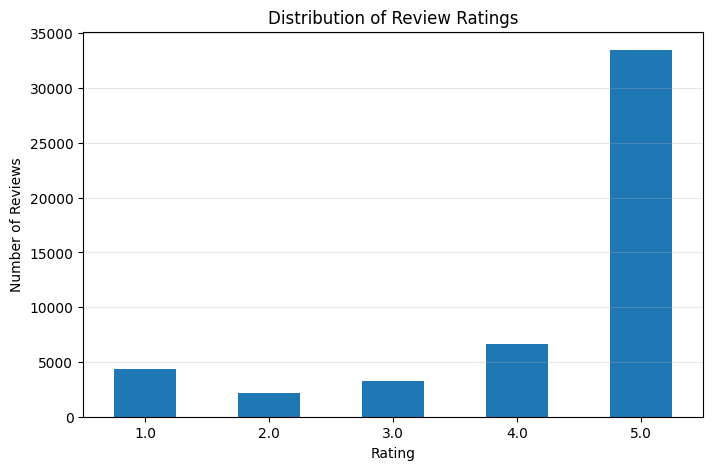

In [ ]:
# วัตถุประสงค์: ดูว่าในตัวอย่าง 50,000 reviews ลูกค้าให้คะแนนระดับใดมากที่สุด
# ============================================================
# 2.3 การกระจายของ Rating
# ============================================================

rating_counts = (
    analysis_df["rating"]
    .value_counts()
    .sort_index()
)

print("===== Rating Distribution =====")
print(rating_counts)

# Percentage
rating_percent = (
    analysis_df["rating"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\n===== Rating Percentage =====")
for rating, percent in rating_percent.items():
    print(f"Rating {rating:.0f}: {percent:.2f}%")

# Plot
plt.figure(figsize=(8, 5))

rating_counts.plot(
    kind="bar"
)

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

#### สรุปผลการวิเคราะห์การกระจายตัวของ Rating

จากการวิเคราะห์การกระจายของ `Rating` พบว่า Rating แต่ละระดับมีจำนวนแตกต่างกัน โดยสามารถเห็นได้ชัดว่าคะแนนระดับ `5.0` มีจำนวน Review มากที่สุด ซึ่งช่วยสะท้อนว่าลูกค้าส่วนมากให้คะแนนสินค้าใน `ระดับดีมาก` จากกลุ่มตัวอย่าง 50,000 reviews

### การกระจายของReviews ตาม Product

In [ ]:
# วัตถุประสงค์: ดูว่าสินค้าแต่ละรายการได้รับ Review มากน้อยแตกต่างกันอย่างไร และหา Product ที่มีจำนวน Reviews สูงสุดใน Sample
# ============================================================
# การกระจายของ Reviews ตาม Product
# ============================================================

product_review_counts = (
    analysis_df
    .groupby(["parent_asin", "title"])
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

print("===== Top 10 Products by Number of Reviews =====")
display(product_review_counts.head(10))

===== Top 10 Products by Number of Reviews =====


,parent_asin,title,review_count
20582,B09857JRP2,GLS Audio Instrument Cable - Amp Cord for Bass...,126
21708,B09W4F2X6S,"BONAOK Wireless Bluetooth Karaoke Microphone, ...",121
24256,B0C6H9T5T6,"Blue Yeti USB Microphone for PC, Mac, Gaming, ...",108
22850,B0BHSG5C3G,"Snark SN5X Clip-On Tuner for Guitar, Bass & Vi...",97
22620,B0BCK6L7S5,"Donner Guitar Delay Pedal, Yellow Fall Analog ...",97
6412,B00DY1F2CS,"Neewer Microphone Arm Stand, Suspension Boom S...",94
23530,B0BSGM6CQ9,Ernie Ball Mondo Slinky Nickelwound Electric G...,87
23614,B0BTR12G3V,Best Choice Products 38in Beginner All Wood Ac...,86
12101,B06ZYJ6SJZ,FIFINE USB Podcast Condenser Microphone Record...,86
19155,B08JMQR2JK,On Stage XCG4 Velveteen Padded Tubular Guitar ...,82


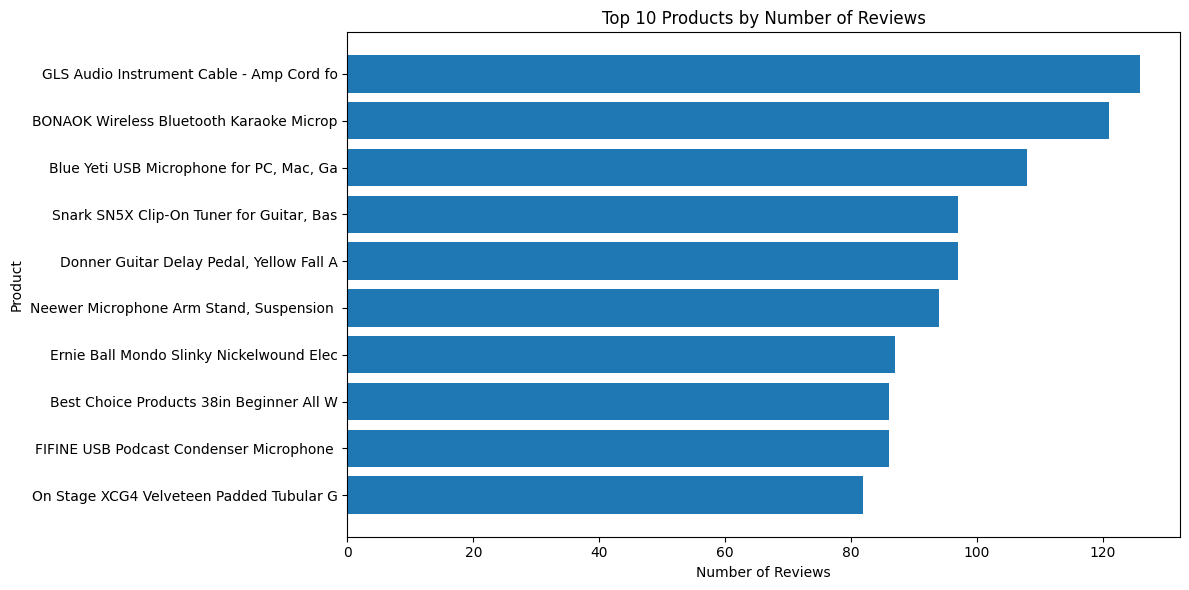

In [ ]:
# Top 10 Products
top10_products = product_review_counts.head(10).copy()

# ตัดชื่อสินค้าให้สั้นลงเพื่อให้กราฟอ่านง่าย
top10_products["short_title"] = (
    top10_products["title"]
    .str[:40]
)

plt.figure(figsize=(12, 6))

plt.barh(
    top10_products["short_title"][::-1],
    top10_products["review_count"][::-1]
)

plt.title("Top 10 Products by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [ ]:
unique_products = analysis_df["parent_asin"].nunique()

print("Number of unique products:", unique_products)
print("Total reviews:", len(analysis_df))

average_reviews_per_product = (
    len(analysis_df) / unique_products
)

print(
    "Average reviews per product:",
    round(average_reviews_per_product, 2)
)

Number of unique products: 24453
Total reviews: 50000
Average reviews per product: 2.04


#### สรุปผลการกระจายของ Reviews ตาม Product
จากการวิเคราะห์ข้อมูล Review จำนวนทั้งหมด 50,000 รายการ พบว่ามีสินค้า `(Unique Products)` จำนวน `24,453 รายการ` โดยมีค่าเฉลี่ยจำนวน Reviews ต่อ Product เท่ากับ `2.04` Reviews ต่อ Product

ผลการวิเคราะห์แสดงให้เห็นว่า แม้ข้อมูลที่นำมาวิเคราะห์จะมีจำนวน Reviews ถึง 50,000 รายการ แต่ Reviews เหล่านี้กระจายอยู่ใน Product จำนวนมาก ทำให้จำนวน `Reviews เฉลี่ยต่อ Product` อยู่ใน `ระดับค่อนข้างต่ำ` ที่ 2.04 Reviews ต่อ Product สะท้อนให้เห็นว่าในกลุ่มตัวอย่างมี Product จำนวนมากที่ได้รับ Reviews เพียงไม่กี่รายการ

ดังนั้น การวิเคราะห์จำนวน Reviews ตาม Product จึงสามารถใช้เพื่อศึกษาว่า Product ใดมีจำนวน Reviews สูงกว่าสินค้าอื่น และช่วยให้เห็นลักษณะการกระจายตัวของ Reviews ภายในกลุ่มตัวอย่างได้ชัดเจนยิ่งขึ้น

### การวิเคราะห์ Reviews ตามช่วงเวลา

In [ ]:
# ============================================================
# การวิเคราะห์ Reviews ตามช่วงเวลา
# ============================================================

analysis_df["review_date"] = pd.to_datetime(
    analysis_df["timestamp"],
    unit="ms"
)

# ตรวจสอบวันที่
print("===== Review Date Range =====")
print("Start:", analysis_df["review_date"].min())
print("End:", analysis_df["review_date"].max())

===== Review Date Range =====
Start: 2001-01-04 15:16:19
End: 2023-09-05 12:24:12.521000


#### สรุปผลการวิเคราะห์ Reviews ตามช่วงเวลา
จากการแปลงข้อมูล `timestamp` ให้อยู่ในรูปแบบวันที่ พบว่า Review ในกลุ่มตัวอย่างมีช่วงเวลาตั้งแต่วันที่ 4 มกราคม 2001 เวลา 15:16:19 จนถึงวันที่ 5 กันยายน 2023 เวลา 12:24:12.521

In [ ]:
# จำนวน Reviews รายปี

reviews_by_year = (
    analysis_df
    .groupby(analysis_df["review_date"].dt.year)
    .size()
)

print("===== Reviews by Year =====")
print(reviews_by_year)

===== Reviews by Year =====
review_date
2001       1
2002       2
2003       3
2004       8
2005      13
2006      18
2007      48
2008      84
2009      94
2010     276
2011     534
2012     900
2013    1997
2014    2859
2015    4009
2016    4641
2017    4276
2018    4562
2019    5602
2020    6372
2021    6452
2022    5063
2023    2186
dtype: int64


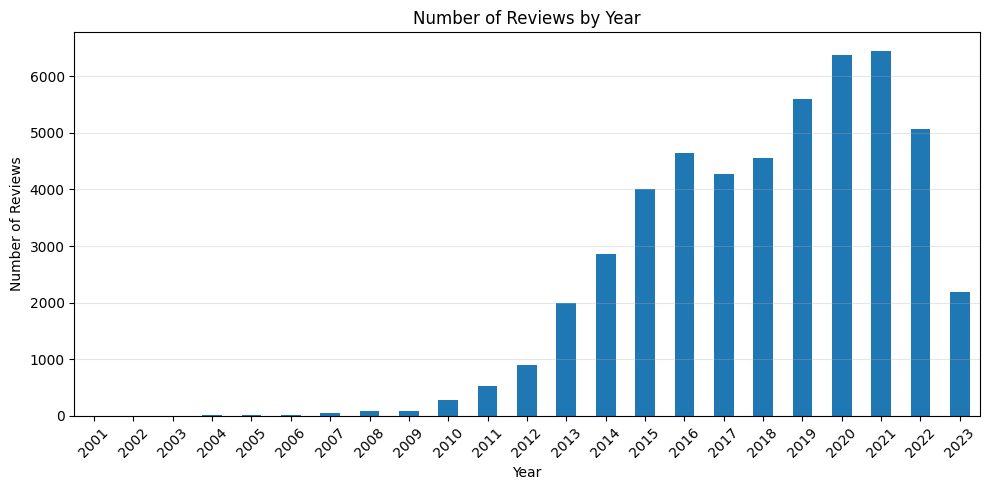

In [ ]:
plt.figure(figsize=(10, 5))

reviews_by_year.plot(
    kind="bar"
)

plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### จำนวน Reviews รายปี

เมื่อพิจารณาจำนวน `Reviews จำแนกตามปี` พบว่าจำนวน Reviews มี`แนวโน้มเพิ่มขึ้นอย่างต่อเนื่อง`ในช่วงแรกของข้อมูล โดยในปี 2001 มีเพียง 1 Review และเพิ่มขึ้นเป็น 13 Reviews ในปี 2005, 94 Reviews ในปี 2009 และ 276 Reviews ในปี 2010

หลังจากนั้นจำนวน Reviews `เพิ่มขึ้นอย่างชัดเจน` โดยมี 534 Reviews ในปี 2011, 900 Reviews ในปี 2012, 1,997 Reviews ในปี 2013, 2,859 Reviews ในปี 2014 และ 4,009 Reviews ในปี 2015

ในปี 2016 มีจำนวน 4,641 Reviews และปี 2017 มี 4,276 Reviews ขณะที่ปี 2018 มี 4,562 Reviews จากนั้นจำนวน Reviews เพิ่มขึ้นอีกครั้งเป็น 5,602 Reviews ในปี 2019 และ 6,372 Reviews ในปี 2020

ปี `2021 เป็นปีที่มีจำนวน Reviews สูงที่สุด` ในข้อมูลชุดนี้ โดยมีจำนวน 6,452 Reviews หลังจากนั้นจำนวน Reviews ลดลงเป็น 5,063 Reviews ในปี 2022 และเหลือ 2,186 Reviews ในปี 2023 อย่างไรก็ตาม ข้อมูลปี 2023 ครอบคลุมเพียงช่วงวันที่ 1 มกราคมถึง 5 กันยายน จึงไม่ควรนำจำนวน Reviews ของปี 2023 ไปเปรียบเทียบกับปีที่มีข้อมูลครบทั้งปีโดยตรง

โดยสรุป ช่วงปี 2019–2022 เป็นช่วงที่มีจำนวน Reviews ในระดับสูงเมื่อเปรียบเทียบกับช่วงก่อนหน้า และปี 2021 มีจำนวน Reviews สูงสุดในกลุ่มตัวอย่างที่ 6,452 Reviews

In [ ]:
reviews_by_month = (
    analysis_df
    .set_index("review_date")
    .resample("M")
    .size()
)

print("===== Monthly Reviews =====")
display(reviews_by_month.head(20))

===== Monthly Reviews =====


/tmp/ipykernel_3133/2015618365.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,0
review_date,
2001-01-31,1
2001-02-28,0
2001-03-31,0
2001-04-30,0
2001-05-31,0
2001-06-30,0
2001-07-31,0
2001-08-31,0
2001-09-30,0


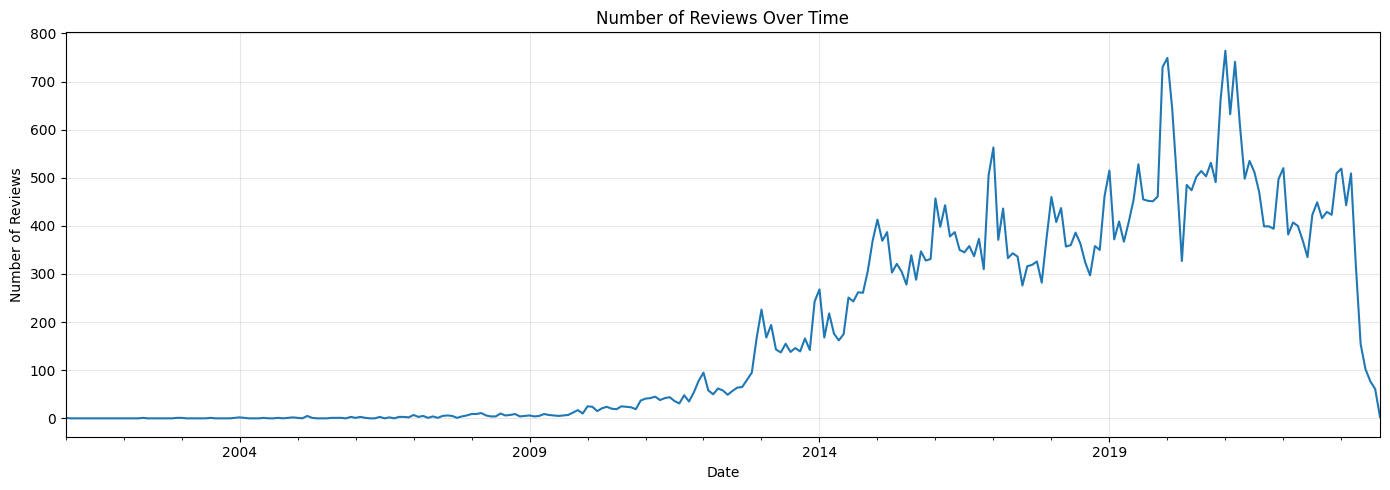

In [ ]:
plt.figure(figsize=(14, 5))

reviews_by_month.plot()

plt.title("Number of Reviews Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3133/3152686850.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["rating"]


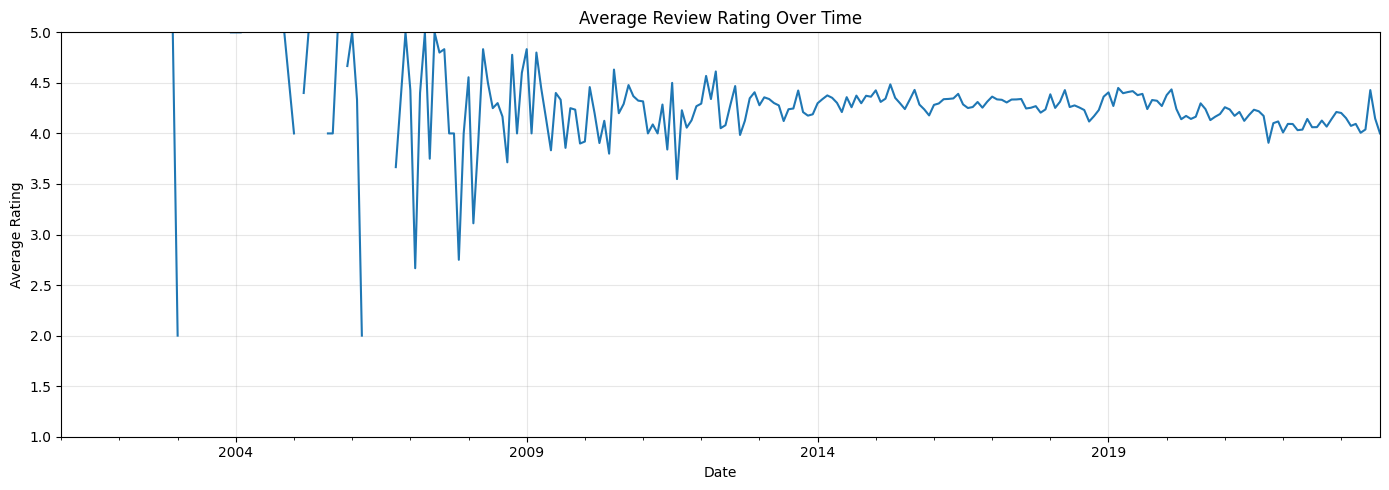

In [ ]:
monthly_rating = (
    analysis_df
    .set_index("review_date")
    .resample("M")["rating"]
    .mean()
)

plt.figure(figsize=(14, 5))

monthly_rating.plot()

plt.title("Average Review Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.ylim(1, 5)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### จำนวน Review รายเดือน

การวิเคราะห์รายเดือน พบว่า Reviews มีการกระจายอยู่ในหลายช่วงเวลา โดยในช่วงต้นของ Dataset มี`บางเดือนที่ไม่มี Reviews` และ`บางเดือนมี Reviews เพียงเล็กน้อย` ซึ่งสอดคล้องกับจำนวน Reviews รายปีที่มีจำนวนน้อยในช่วงปีแรก ๆ ของข้อมูล

###  การเปรียบเทียบ Review Rating กับ Product Average Rating

In [ ]:
# ============================================================
# 5.4 Review Rating vs Product Average Rating
# ============================================================

comparison = analysis_df[
    ["rating", "average_rating"]
].dropna()

print("===== Rating Comparison =====")
display(
    comparison.describe()
)

===== Rating Comparison =====


,rating,average_rating
count,50000.000000,50000.000000
mean,4.252340,4.373490
std,1.279663,0.412278
min,1.000000,1.000000
25%,4.000000,4.200000
50%,5.000000,4.500000
75%,5.000000,4.600000
max,5.000000,5.000000


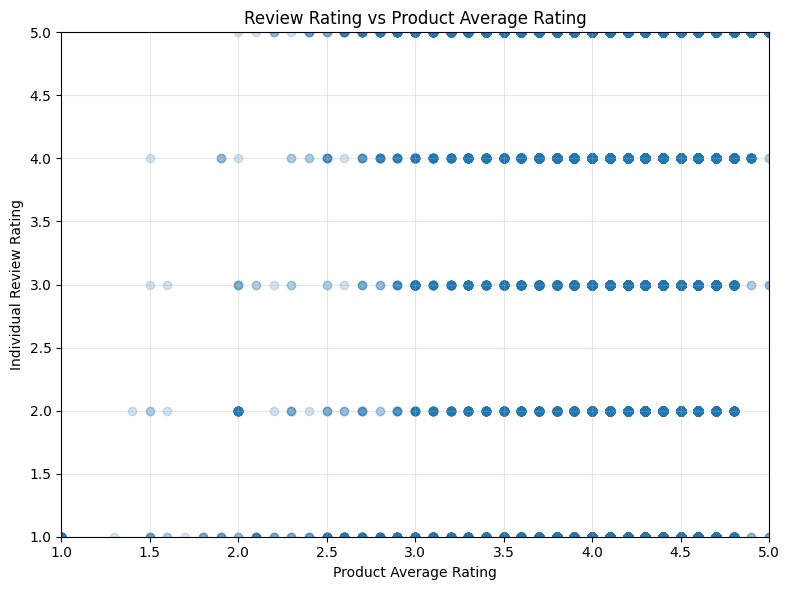

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    comparison["average_rating"],
    comparison["rating"],
    alpha=0.2
)

plt.title(
    "Review Rating vs Product Average Rating"
)

plt.xlabel("Product Average Rating")
plt.ylabel("Individual Review Rating")

plt.xlim(1, 5)
plt.ylim(1, 5)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("===== Mean Comparison =====")

print(
    "Mean Individual Review Rating:",
    round(comparison["rating"].mean(), 3)
)

print(
    "Mean Product Average Rating:",
    round(comparison["average_rating"].mean(), 3)
)

===== Mean Comparison =====
Mean Individual Review Rating: 4.252
Mean Product Average Rating: 4.373


In [ ]:
comparison = comparison.copy()

comparison["rating_difference"] = (
    comparison["rating"]
    - comparison["average_rating"]
)

print("===== Rating Difference =====")

display(
    comparison["rating_difference"].describe()
)

===== Rating Difference =====


,rating_difference
count,50000.000000
mean,-0.121150
std,1.224492
min,-4.000000
25%,-0.500000
50%,0.300000
75%,0.600000
max,3.000000


### ผลการวิเคราะห์การเปรียบเทียบ Review Rating กับ Product Average Rating

ผลการวิเคราะห์พบว่า `Individual Review Rating` มีค่าเฉลี่ยเท่ากับ `4.252` คะแนน และมีส่วนเบี่ยงเบนมาตรฐานเท่ากับ `1.280`โดยมีค่าต่ำสุด 1 คะแนน และสูงสุด 5 คะแนน

ในขณะที่ `Product Average Rating` มีค่าเฉลี่ยเท่ากับ `4.373` คะแนน และมีส่วนเบี่ยงเบนมาตรฐานเท่ากับ `0.412` โดยมีค่าต่ำสุด 1 คะแนน และสูงสุด 5 คะแนน

เมื่อเปรียบเทียบค่าเฉลี่ย พบว่า Product Average Rating มี`ค่าเฉลี่ยสูงกว่า` Individual Review Rating โดยมีค่าแตกต่างกันประมาณ 0.121 คะแนน

กล่าวคือ ค่าเฉลี่ยของคะแนน Review รายบุคคลอยู่ที่ 4.252 ในขณะที่ค่าเฉลี่ยของ Product Rating อยู่ที่ 4.373

In [ ]:
comparison["comparison_group"] = np.where(
    comparison["rating_difference"] > 0,
    "Review > Product Average",
    np.where(
        comparison["rating_difference"] < 0,
        "Review < Product Average",
        "Review = Product Average"
    )
)

comparison_counts = (
    comparison["comparison_group"]
    .value_counts()
)

print("===== Comparison Groups =====")
print(comparison_counts)

===== Comparison Groups =====
comparison_group
Review > Product Average    33324
Review < Product Average    15094
Review = Product Average     1582
Name: count, dtype: int64


### แบ่งข้อมูล 3 กลุ่ม

เมื่อสร้างตัวแปร rating_difference จากสูตร

`Rating Difference` = `Individual Review Rating − Product Average Rating`

พบว่าค่าเฉลี่ยของความแตกต่างเท่ากับ -0.121 ซึ่งสอดคล้องกับผลการเปรียบเทียบค่าเฉลี่ยข้างต้น นอกจากนี้ ค่าต่ำสุดของความแตกต่างเท่ากับ -4.00 และค่าสูงสุดเท่ากับ 3.00 โดยค่ามัธยฐานอยู่ที่ 0.30

เมื่อแบ่งข้อมูลออกเป็น 3 กลุ่มตามความแตกต่างระหว่าง Review Rating กับ Product Average Rating พบว่า

`Review > Product Average จำนวน 33,324 Reviews`

`Review < Product Average จำนวน 15,094 Reviews`

`Review = Product Average จำนวน 1,582 Reviews`

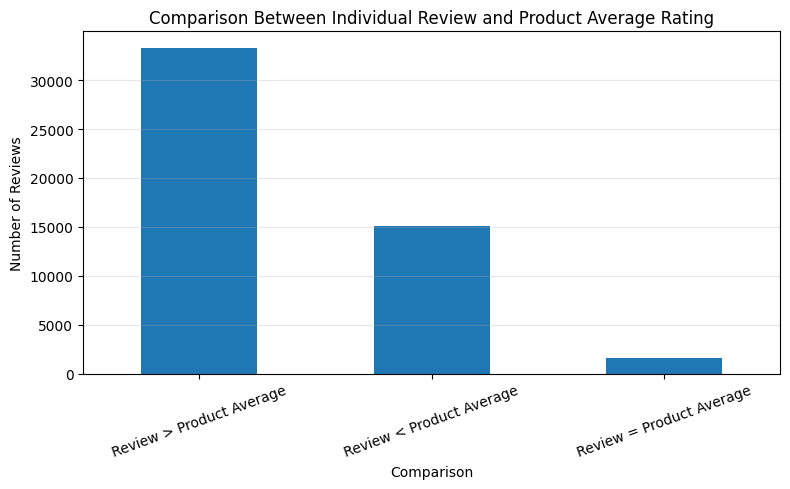

In [ ]:
plt.figure(figsize=(8, 5))

comparison_counts.plot(
    kind="bar"
)

plt.title(
    "Comparison Between Individual Review and Product Average Rating"
)

plt.xlabel("Comparison")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### สรุปผลการวิเคราะห์การเปรียบเทียบ Review Rating กับ Product Average Rating

ผลการวิเคราะห์ส่วนนี้แสดงให้เห็นว่า แม้ค่าเฉลี่ยของ Individual Review Rating จะต่ำกว่าค่าเฉลี่ยของ Product Average Rating แต่เมื่อพิจารณาเป็นราย Review กลับพบว่า Reviews จำนวนมากมีคะแนนสูงกว่า Product Average Rating ของสินค้านั้น ๆ ทั้งนี้ ค่า Product Average Rating เป็นค่าที่สรุปในระดับ Product ขณะที่ Individual Review Rating เป็นคะแนนของ Review แต่ละรายการ จึงควรพิจารณาความแตกต่างของระดับข้อมูลดังกล่าวประกอบการตีความผล

###  สรุปผลการทำ EDA
### ด้าน Product:

พบสินค้าไม่ซ้ำกันทั้งหมด **24,453 รายการ** จาก Reviews จำนวน **50,000 records** หรือเฉลี่ยประมาณ **2.04 Reviews ต่อ Product** แสดงว่า Sample มี Reviews กระจายอยู่ใน Product จำนวนมาก และไม่ได้กระจุกตัวอยู่กับ Product เพียงไม่กี่รายการ

### ด้านช่วงเวลา:

ข้อมูล Reviews ครอบคลุมตั้งแต่ปี **2001–2023** โดยจำนวน Reviews เพิ่มขึ้นอย่างชัดเจนในช่วงหลัง และมีจำนวนสูงสุดในปี **2021** จำนวน **6,452 Reviews**

### ด้าน Rating:

คะแนน Review Rating เฉลี่ยอยู่ที่ **4.252** ขณะที่ Product Average Rating เฉลี่ยอยู่ที่ **4.373**

เมื่อเปรียบเทียบคะแนน Review กับ Product Average Rating พบว่า **33,324 Reviews** มีคะแนนสูงกว่า Product Average Rating, **15,094 Reviews** มีคะแนนต่ำกว่า และ **1,582 Reviews** มีคะแนนเท่ากัน

ผลดังกล่าวใช้เป็นข้อมูลพื้นฐานสำหรับขั้นตอนถัดไปในการวิเคราะห์ **Bad Review และ Product Metadata Features** เช่น ความยาวของ Product Title และจำนวน Feature Bullets เพื่อดูว่ารูปแบบของ Product Metadata มีความสัมพันธ์กับ Rating และ Bad Review แตกต่างกันอย่างไร

### สรุปภาพรวม:

EDA แสดงให้เห็นลักษณะการกระจายของ Reviews ตาม Product, ช่วงเวลา และ Rating ซึ่งช่วยให้เข้าใจโครงสร้างและแนวโน้มของข้อมูลก่อนนำไปวิเคราะห์ **Bad Review Rate และ Product Metadata Features** ในขั้นตอนถัดไป

### 2.4 การเตรียมข้อมูลและการสร้าง Product Metadata Text Features

### 2.4.1 Data Preprocessing

เนื่องจาก Dataset ที่ใช้ในการวิเคราะห์ไม่มี Customer Review Text แต่ประกอบด้วยข้อมูล Review ได้แก่ `user_id`, `parent_asin`, `rating`, `timestamp` และข้อมูล Product Metadata เช่น `title`, `features` และ `description` การเตรียมข้อมูลจึงมุ่งเน้นที่การตรวจสอบและจัดรูปแบบข้อมูลที่จำเป็นสำหรับการสร้าง Features

ขั้นตอน Preprocessing ที่ใช้ ได้แก่

1. **ตรวจสอบ Missing Values**
   - ตรวจสอบข้อมูลที่ขาดหายใน `rating`, `parent_asin`, `title` และ `features`
   - เพื่อให้มั่นใจว่า Features ที่สร้างขึ้นสามารถนำไปวิเคราะห์ได้อย่างถูกต้อง

2. **จัดการ Product Title**
   - แทนค่า Missing ใน `title` ด้วยค่าว่าง
   - แปลงข้อมูลเป็น String ก่อนนับจำนวนคำ
   - เพื่อให้สามารถสร้าง Feature `title_word_count` ได้อย่างสม่ำเสมอ

3. **จัดการ Product Features**
   - ตรวจสอบว่า `features` อยู่ในรูปแบบ List หรือไม่
   - หากไม่มี Feature หรือเป็น Missing ให้กำหนดจำนวน Feature เป็น 0
   - เพื่อสร้าง Feature `feature_bullet_count`

4. **กำหนด Bad Review**
   - กำหนด `rating ≤ 2` เป็น Bad Review
   - ใช้เป็นตัวชี้วัดสัญญาณปัญหาของสินค้า และใช้เปรียบเทียบความแตกต่างระหว่างกลุ่ม Product Metadata

การ Preprocessing เหล่านี้มีวัตถุประสงค์เพื่อเตรียมข้อมูลให้พร้อมสำหรับการสร้าง Features และวิเคราะห์ความสัมพันธ์ระหว่าง Product Metadata กับ Bad Review โดยไม่ได้ตีความว่า Product Metadata เป็นสาเหตุโดยตรงของ Bad Review

In [ ]:
# ============================================
# 2.4.1 Data Preprocessing
# ============================================

# จัดการ Product Title
analysis_df["title"] = (
    analysis_df["title"]
    .fillna("")
    .astype(str)
)

# จัดการ Product Features
analysis_df["features"] = analysis_df["features"].apply(
    lambda x: x if isinstance(x, list) else []
)

# ตรวจสอบ Missing Values ของข้อมูลที่เกี่ยวข้อง
print("Missing values:")
print(
    analysis_df[
        ["parent_asin", "rating", "title", "features"]
    ].isna().sum()
)

# ตรวจสอบข้อมูล
display(
    analysis_df[
        ["parent_asin", "rating", "title", "features"]
    ].head()
)

Missing values:
parent_asin    0
rating         0
title          0
features       0
dtype: int64


,parent_asin,rating,title,features
0,B00CBY2T9I,5.0,Tune Pro Clip on CAMO (Camouflage) Tuner -Guit...,"[CAMO colored tuner!, Fully Chromatic Tuner - ..."
1,B07MVRLPFW,5.0,Revv G4 Preamp/Overdrive/Distortion Pedal Red,[Preamp/Overdrive/Disttion Pedal f Electric Gu...
2,B07BV6HJPD,5.0,"Liberty Imports 23"" Acoustic Guitar, Kids 6 St...",[MINI GUITAR FOR LEARNING: This beginner's aco...
3,B073RTT48C,5.0,Hipshot 6GLO Grip-Lock Locking Guitar Tuning M...,"[3+3 headstock configuration, Grip lock, 18:1 ..."
4,B0B3VKB2C1,3.0,MusicNomad MN117 Cymbal Cleaner & Drum Detaile...,"[Acid-free cymbal cleaner works to clean, poli..."


### คำอธิบายผลการ Preprocessing

จากการตรวจสอบข้อมูลที่ใช้สำหรับการสร้าง Features พบว่า `parent_asin`, `rating`, `title` และ `features` **ไม่มี Missing Values** โดยทุกคอลัมน์มีจำนวน Missing Values เท่ากับ 0

นอกจากนี้ จากการตรวจสอบตัวอย่างข้อมูลพบว่า

- `parent_asin` มีค่า Product ID สำหรับระบุสินค้า
- `rating` มีคะแนน Review ที่สามารถนำไปใช้กำหนด `bad_review` ได้
- `title` มีข้อมูล Product Title ในรูปแบบข้อความ ซึ่งสามารถนำไปนับจำนวนคำได้
- `features` อยู่ในรูปแบบ List ของ Feature Bullets ซึ่งสามารถนำไปนับจำนวน Features ได้

ดังนั้น ข้อมูลที่เกี่ยวข้องกับการสร้าง Features มีความพร้อมสำหรับขั้นตอนถัดไป โดยไม่จำเป็นต้องตัด Records ออกจาก Sample เนื่องจากไม่พบ Missing Values ในคอลัมน์สำคัญ

ขั้นตอนนี้จึงเป็นการเตรียมข้อมูลให้มีรูปแบบที่เหมาะสมและสม่ำเสมอ ก่อนนำไปสร้าง **Product Metadata Features** ในขั้นตอน Feature Engineering

### 2.4.2 Product Metadata Text Feature Engineering

จาก Business Question ที่ต้องการค้นหาสินค้าหรือกลุ่มสินค้าที่ควรได้รับการตรวจสอบและปรับปรุงก่อน จึงสร้าง Features จาก Product Metadata เพื่อใช้วิเคราะห์ความสัมพันธ์กับ Bad Review

Features หลักที่สร้างมี 2 ตัว ได้แก่

1. **Title Word Count (`title_word_count`)**
   - จำนวนคำใน Product Title
   - ใช้ตรวจสอบว่าความยาวของชื่อสินค้ามีรูปแบบความสัมพันธ์กับ Bad Review หรือไม่

2. **Feature Bullet Count (`feature_bullet_count`)**
   - จำนวน Feature Bullets ที่แสดงคุณสมบัติของสินค้า
   - ใช้ตรวจสอบว่าจำนวนข้อมูลคุณสมบัติของสินค้ามีรูปแบบความสัมพันธ์กับ Bad Review หรือไม่

นอกจากนี้ยังสร้างตัวแปรสำหรับการวิเคราะห์ในระดับกลุ่ม ได้แก่

- `title_length_group`: Short, Medium, Long และ Very Long
- `feature_bullet_group`: 0, 1–3, 4–5 และ 6+
- `bad_review`: กำหนดเป็น 1 เมื่อ `rating ≤ 2` และ 0 เมื่อ `rating > 2`

Features เหล่านี้ช่วยให้สามารถเปรียบเทียบ Bad Review Rate ระหว่างกลุ่ม Product Metadata และใช้เป็นข้อมูลประกอบการจัดลำดับความสำคัญของสินค้าที่ควรได้รับการตรวจสอบก่อน

ทั้งนี้ Feature เหล่านี้ใช้เพื่อระบุ **สัญญาณหรือความสัมพันธ์ในข้อมูล** ไม่ได้หมายความว่า Title Length หรือ Feature Bullet Count เป็นสาเหตุโดยตรงของ Bad Review

In [ ]:
# ============================================
# 2.4.2 Product Metadata Text Feature Engineering
# ============================================

# Feature 1: จำนวนคำใน Product Title
analysis_df["title_word_count"] = (
    analysis_df["title"]
    .str.split()
    .str.len()
)

# Feature 2: จำนวน Feature Bullets
analysis_df["feature_bullet_count"] = (
    analysis_df["features"]
    .apply(len)
)

# แบ่งกลุ่มความยาวของ Product Title
analysis_df["title_length_group"] = pd.cut(
    analysis_df["title_word_count"],
    bins=[-1, 8, 14, 23, float("inf")],
    labels=["Short", "Medium", "Long", "Very Long"]
)

# แบ่งกลุ่มจำนวน Feature Bullets
analysis_df["feature_bullet_group"] = pd.cut(
    analysis_df["feature_bullet_count"],
    bins=[-1, 0, 3, 5, float("inf")],
    labels=["0", "1-3", "4-5", "6+"]
)

# สร้างตัวแปร Bad Review
# Rating <= 2 = Bad Review
analysis_df["bad_review"] = (
    analysis_df["rating"] <= 2
).astype(int)

# ตรวจสอบ Features ที่สร้างขึ้น
display(
    analysis_df[
        [
            "title",
            "title_word_count",
            "title_length_group",
            "features",
            "feature_bullet_count",
            "feature_bullet_group",
            "rating",
            "bad_review"
        ]
    ].head()
)

,title,title_word_count,title_length_group,features,feature_bullet_count,feature_bullet_group,rating,bad_review
0,Tune Pro Clip on CAMO (Camouflage) Tuner -Guit...,52,Very Long,"[CAMO colored tuner!, Fully Chromatic Tuner - ...",5,4-5,5.0,0
1,Revv G4 Preamp/Overdrive/Distortion Pedal Red,5,Short,[Preamp/Overdrive/Disttion Pedal f Electric Gu...,1,1-3,5.0,0
2,"Liberty Imports 23"" Acoustic Guitar, Kids 6 St...",25,Very Long,[MINI GUITAR FOR LEARNING: This beginner's aco...,5,4-5,5.0,0
3,Hipshot 6GLO Grip-Lock Locking Guitar Tuning M...,16,Long,"[3+3 headstock configuration, Grip lock, 18:1 ...",5,4-5,5.0,0
4,MusicNomad MN117 Cymbal Cleaner & Drum Detaile...,10,Medium,"[Acid-free cymbal cleaner works to clean, poli...",5,4-5,3.0,0


### คำอธิบายผลการสร้าง Product Metadata Text Features

จากการสร้าง Features พบว่าสามารถสกัดข้อมูลเชิงตัวเลขจาก Product Metadata ได้ 2 Features หลัก ได้แก่ `title_word_count` และ `feature_bullet_count`

- `title_word_count` ใช้สำหรับนับจำนวนคำใน Product Title โดยจากตัวอย่างพบว่าจำนวนคำของ Product Title แตกต่างกัน เช่น 5, 10, 16, 25 และ 52 คำ ทำให้สามารถแบ่งสินค้าออกเป็นกลุ่ม Short, Medium, Long และ Very Long ได้

- `feature_bullet_count` ใช้สำหรับนับจำนวน Feature Bullets ของสินค้า โดยจากตัวอย่างพบว่ามีจำนวนแตกต่างกัน เช่น 1 และ 5 Features และสามารถแบ่งเป็นกลุ่ม 0, 1-3, 4-5 และ 6+ ได้

นอกจากนี้ได้สร้าง `bad_review` จาก Rating เพื่อใช้เป็นตัวแปรสำหรับการวิเคราะห์ โดยกำหนดให้ Rating ≤ 2 เป็น Bad Review (`bad_review = 1`) และ Rating > 2 เป็น Non-Bad Review (`bad_review = 0`) จากตัวอย่างข้อมูลที่แสดง Rating 5.0 และ 3.0 จึงถูกกำหนดเป็น `bad_review = 0`

Features ที่สร้างขึ้นจึงสามารถเปลี่ยนข้อมูลข้อความจาก Product Metadata ให้อยู่ในรูปแบบตัวเลขและกลุ่มที่สามารถนำไปเปรียบเทียบกับ Bad Review Rate ได้ในขั้นตอนการวิเคราะห์ Insight

### 2.4.3 Feature Contribution to Business Questions

Features ที่สร้างขึ้นถูกออกแบบให้สอดคล้องกับ Business Question ของ Product Team ซึ่งต้องการระบุว่าสินค้าหรือกลุ่มสินค้าใดควรได้รับการตรวจสอบและปรับปรุงก่อน ภายใต้ทรัพยากรที่จำกัด

- **`title_word_count`**  
  ใช้เป็นตัวแทนของความยาว Product Title เพื่อเปรียบเทียบว่า Product ที่มี Title ความยาวแตกต่างกันมี Bad Review Rate แตกต่างกันหรือไม่

- **`feature_bullet_count`**  
  ใช้เป็นตัวแทนของจำนวนข้อมูลคุณสมบัติของสินค้า เพื่อเปรียบเทียบว่า Product ที่มีจำนวน Feature Bullets แตกต่างกันมี Bad Review Rate แตกต่างกันหรือไม่

- **`title_length_group` และ `feature_bullet_group`**  
  ใช้จัดกลุ่ม Product Metadata ให้สามารถเปรียบเทียบ Bad Review Rate ระหว่างกลุ่มได้ง่ายขึ้น และช่วยระบุรูปแบบของ Product ที่ควรได้รับการตรวจสอบเพิ่มเติม

- **`bad_review`**  
  ใช้เป็นตัวแปรสำหรับระบุ Review ที่มี Rating ≤ 2 และนำไปคำนวณ Bad Review Rate เพื่อใช้เป็นสัญญาณในการจัดลำดับความสำคัญของ Product

ดังนั้น Features ที่สร้างขึ้นช่วยเปลี่ยนข้อมูลข้อความจาก Product Metadata ให้อยู่ในรูปแบบที่สามารถนำมาเปรียบเทียบและเชื่อมโยงกับ Business Question ได้ โดยผลการวิเคราะห์จะช่วย Product Team ระบุ Product หรือ Product Metadata Pattern ที่มีสัญญาณ Bad Review สูง และควรได้รับการตรวจสอบเพิ่มเติมก่อน

อย่างไรก็ตาม ผลการวิเคราะห์นี้ใช้เพื่อระบุ **ความสัมพันธ์หรือสัญญาณในข้อมูล** เท่านั้น ไม่สามารถสรุปได้ว่า Product Title หรือจำนวน Feature Bullets เป็นสาเหตุโดยตรงของ Bad Review

## 2.5 หา Insight ที่ตอบ Client Brief

จาก Business Question ของ Product Team ที่ต้องการระบุว่าสินค้าหรือกลุ่มสินค้าใดควรได้รับการตรวจสอบและปรับปรุงก่อน การวิเคราะห์ในส่วนนี้จะมุ่งเน้นการค้นหา **สัญญาณของปัญหาจาก Customer Rating** และตรวจสอบว่าลักษณะของ **Product Metadata** มีความแตกต่างกันระหว่างกลุ่มที่มี Bad Review Rate สูงและต่ำหรือไม่

เนื่องจาก Dataset ที่ใช้ไม่มี Customer Review Text การวิเคราะห์จึงไม่ได้ใช้ Sentiment Analysis, TF-IDF หรือ Aspect Analysis จากข้อความรีวิว แต่เลือกใช้ข้อมูลที่มีอยู่จริง ได้แก่ `rating`, `parent_asin`, `title` และ `features` เพื่อสร้างตัวชี้วัดและ Features ที่สอดคล้องกับ Client Brief

การวิเคราะห์แบ่งออกเป็น 3 ส่วน ได้แก่

1. **Product-level Analysis**  
   วิเคราะห์จำนวน Reviews, Bad Reviews, Bad Review Rate และ Average Rating ในระดับ Product เพื่อระบุสินค้าที่มีสัญญาณปัญหาสูงและมีจำนวน Reviews เพียงพอสำหรับใช้ประกอบการจัดลำดับความสำคัญ

2. **Product Metadata Analysis**  
   เปรียบเทียบ Bad Review Rate ระหว่างกลุ่มของ `title_length_group` และ `feature_bullet_group` เพื่อค้นหา Product Metadata Pattern ที่มีความสัมพันธ์กับ Bad Review

3. **Combined Business Insight**  
   นำผลจากระดับ Product และ Product Metadata มาประกอบกัน เพื่อระบุว่าสินค้าและรูปแบบของ Product Metadata ใดควรได้รับการตรวจสอบก่อน ภายใต้ทรัพยากรที่จำกัด

การวิเคราะห์ในส่วนนี้มีวัตถุประสงค์เพื่อค้นหา **ความสัมพันธ์และสัญญาณที่นำไปใช้ประกอบการตัดสินใจ** ไม่ได้สรุปว่า Product Metadata เป็นสาเหตุโดยตรงของ Bad Review

### 2.5.1 Product-level Analysis

การวิเคราะห์ระดับ Product ใช้เทคนิค **GroupBy และ Aggregation** โดยจัดกลุ่มข้อมูลตาม `parent_asin` ซึ่งเป็น Product Identifier เพื่อสรุปจำนวน Reviews และระดับของ Bad Review ในแต่ละ Product

ตัวชี้วัดที่ใช้ในการวิเคราะห์ประกอบด้วย

- **Review Count**: จำนวน Reviews ของแต่ละ Product
- **Bad Review Count**: จำนวน Reviews ที่มี Rating ≤ 2
- **Bad Review Rate**: สัดส่วนของ Bad Reviews ต่อ Reviews ทั้งหมดของ Product
- **Average Rating**: คะแนน Review เฉลี่ยของแต่ละ Product

ในการจัดลำดับ Product ได้กำหนด **Minimum Review Threshold = 5 Reviews** เพื่อหลีกเลี่ยงการตีความ Product ที่มีจำนวน Reviews น้อยเกินไป เช่น Product ที่มีเพียง 1 Review และ Review นั้นเป็น Bad Review จะมี Bad Review Rate = 100% แต่ยังมีข้อมูลไม่เพียงพอที่จะใช้เป็นสัญญาณที่แข็งแรงในการตัดสินใจ

ดังนั้น การจัดลำดับความสำคัญจะพิจารณาจาก Product ที่มี **Bad Review Rate สูง** ร่วมกับการมี **จำนวน Reviews อย่างน้อย 5 Reviews**

ผลลัพธ์จากการวิเคราะห์นี้จะช่วยตอบ Business Question ข้อที่ 1 ว่า

> **สินค้ารายใดมีสัดส่วน Bad Review สูง และมีจำนวน Reviews เพียงพอที่จะใช้เป็นสัญญาณสำหรับจัดลำดับความสำคัญในการตรวจสอบและปรับปรุงก่อน?**

การวิเคราะห์นี้เป็นการระบุ **สัญญาณและลำดับความสำคัญของ Product** จากข้อมูลที่มีอยู่ ไม่ได้หมายความว่า Product ที่มี Bad Review Rate สูงเป็นสาเหตุของปัญหาโดยตรง

In [ ]:
# ============================================
# 2.5.1 Product-level Analysis
# ============================================

# 1. สรุปข้อมูลในระดับ Product
product_summary = (
    analysis_df
    .groupby("parent_asin")
    .agg(
        review_count=("rating", "count"),
        bad_review_count=("bad_review", "sum"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)

# 2. คำนวณ Bad Review Rate (%)
product_summary["bad_review_rate"] = (
    product_summary["bad_review_count"]
    / product_summary["review_count"]
    * 100
)

# 3. กำหนด Minimum Review Threshold
MIN_REVIEWS = 5

product_priority = (
    product_summary[
        product_summary["review_count"] >= MIN_REVIEWS
    ]
    .copy()
)

# 4. เรียง Product ตาม Bad Review Rate สูงสุด
#    ถ้า Rate เท่ากัน ให้ Product ที่มี Reviews มากกว่าอยู่ก่อน
product_priority = product_priority.sort_values(
    by=["bad_review_rate", "review_count"],
    ascending=[False, False]
)

# 5. แสดงจำนวน Product ก่อนและหลังใช้ Threshold
print("จำนวน Product ทั้งหมด:", len(product_summary))

print(
    f"จำนวน Product ที่มี Reviews >= {MIN_REVIEWS}:",
    len(product_priority)
)

# 6. แสดง Top 10 Product ที่มี Bad Review Rate สูงสุด
print("\nTop 10 Products ที่มี Bad Review Rate สูงสุด")

display(
    product_priority[
        [
            "parent_asin",
            "review_count",
            "bad_review_count",
            "bad_review_rate",
            "avg_rating"
        ]
    ]
    .head(10)
    .style.format({
        "bad_review_rate": "{:.2f}%",
        "avg_rating": "{:.2f}"
    })
)

จำนวน Product ทั้งหมด: 24453
จำนวน Product ที่มี Reviews >= 5: 1713

Top 10 Products ที่มี Bad Review Rate สูงสุด


,parent_asin,review_count,bad_review_count,bad_review_rate,avg_rating
3066,B002UR3JVI,5,4,80.00%,1.40
18652,B08BN8S4NM,5,4,80.00%,1.80
2684,B001WLSYW2,6,4,66.67%,2.17
16882,B07TRVP823,6,4,66.67%,2.17
18122,B0859QF434,6,4,66.67%,2.67
21997,B0B1T92VM6,6,4,66.67%,2.67
23100,B0BLLDYSL7,6,4,66.67%,2.50
10556,B01G2DLWZU,8,5,62.50%,2.38
21140,B09KQLFXGC,8,5,62.50%,2.50
21848,B09YGMBL3H,8,5,62.50%,2.75


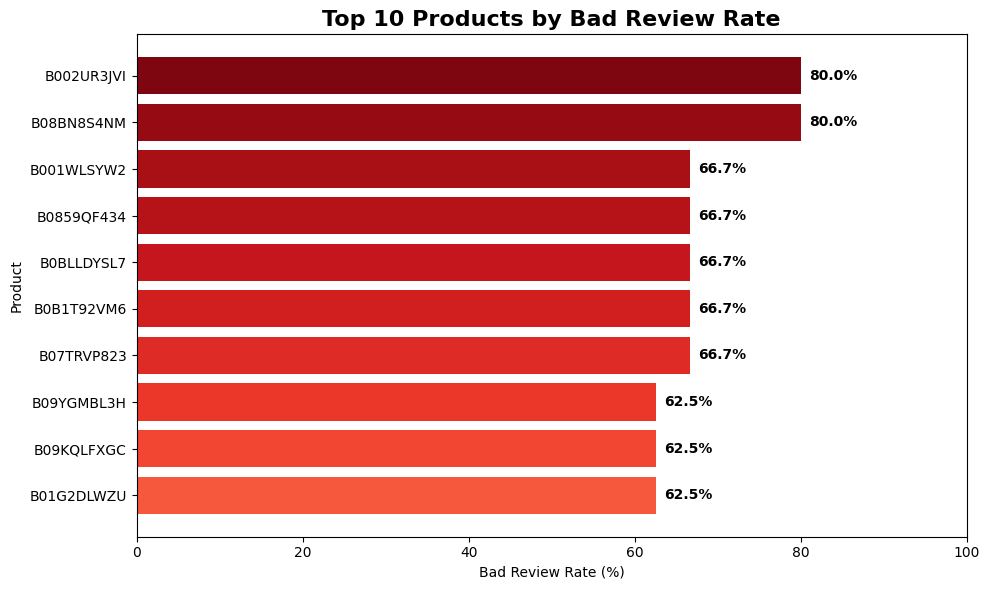

In [ ]:
# ============================================
# 2.5.1 Graph: Top Products by Bad Review Rate
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# เลือก Top 10 Products ที่มี Bad Review Rate สูงสุด
top_products = (
    product_priority
    .head(10)
    .sort_values("bad_review_rate", ascending=True)
)

# สีแดงไล่ระดับ
# แดงอ่อน -> แดงเข้ม
colors = plt.cm.Reds(
    np.linspace(0.55, 0.95, len(top_products))
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["parent_asin"],
    top_products["bad_review_rate"],
    color=colors
)

plt.xlabel("Bad Review Rate (%)")
plt.ylabel("Product")
plt.title(
    "Top 10 Products by Bad Review Rate",
    fontsize=16,
    fontweight="bold"
)

# แสดงค่าบนแท่ง
for i, value in enumerate(top_products["bad_review_rate"]):
    plt.text(
        value + 1,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

### คำอธิบายผลการวิเคราะห์ Product-level

จาก Product ทั้งหมด **24,453 Products** พบว่ามี **1,713 Products** ที่มีจำนวน Reviews ตั้งแต่ 5 Reviews ขึ้นไป หลังจากกำหนด Minimum Review Threshold เพื่อให้การจัดลำดับมีข้อมูลประกอบเพียงพอมากขึ้น

ผลการวิเคราะห์พบว่า Product ที่มี **Bad Review Rate สูงสุดอยู่ที่ 80.00%** ได้แก่

- `B002UR3JVI` มี 5 Reviews และเป็น Bad Review จำนวน 4 Reviews คิดเป็น Bad Review Rate **80.00%** โดยมี Average Rating **1.40**
- `B08BN8S4NM` มี 5 Reviews และเป็น Bad Review จำนวน 4 Reviews คิดเป็น Bad Review Rate **80.00%** โดยมี Average Rating **1.80**

นอกจากนี้ พบ Product อีก 5 รายการที่มี Bad Review Rate **66.67%** โดยแต่ละ Product มี 6 Reviews และมี Bad Review จำนวน 4 Reviews

ผลดังกล่าวแสดงให้เห็นว่ามี Product บางรายการที่มีสัดส่วน Bad Review สูง และสามารถใช้เป็น **สัญญาณเบื้องต้นสำหรับจัดลำดับ Product ที่ควรได้รับการตรวจสอบเพิ่มเติม**

อย่างไรก็ตาม Product ที่มี Bad Review Rate สูงในอันดับต้น ๆ ยังมีจำนวน Reviews เพียง 5–8 Reviews ดังนั้นผลลัพธ์นี้ควรถูกตีความเป็น **Warning Signal** มากกว่าการสรุปว่า Product ดังกล่าวมีปัญหาอย่างแน่นอน

### Business Insight 1

ภายใต้ทรัพยากรที่จำกัด Product Team ควรเริ่มจากการตรวจสอบ Product ที่มี **Bad Review Rate สูงและมีจำนวน Reviews ผ่าน Minimum Threshold** โดย `B002UR3JVI` และ `B08BN8S4NM` เป็นกลุ่มที่ควรได้รับการตรวจสอบเพิ่มเติมเป็นลำดับต้น ๆ

ผลการวิเคราะห์นี้ตอบ Business Question ข้อที่ 1 ว่า

> **สินค้าที่มี Bad Review Rate สูงและมีจำนวน Reviews เพียงพอสามารถใช้เป็นสัญญาณสำหรับจัดลำดับความสำคัญในการตรวจสอบ Product ได้**

อย่างไรก็ตาม การวิเคราะห์นี้เป็นการระบุความเสี่ยงเบื้องต้นจาก Rating เท่านั้น และไม่สามารถระบุสาเหตุของปัญหาได้ เนื่องจาก Dataset ไม่มี Customer Review Text

### 2.5.2 Product Metadata Analysis

จากผลการวิเคราะห์ระดับ Product ในหัวข้อก่อนหน้า เราพบว่า Product บางรายการมี Bad Review Rate สูง ดังนั้นในขั้นตอนนี้จึงวิเคราะห์ต่อว่าลักษณะของ **Product Metadata** มีความสัมพันธ์กับ Bad Review Rate หรือไม่

การวิเคราะห์ใช้ Features ที่สร้างขึ้นในหัวข้อ 2.4 ได้แก่

- `title_length_group` แบ่ง Product Title ตามจำนวนคำเป็น **Short, Medium, Long และ Very Long**
- `feature_bullet_group` แบ่งจำนวน Feature Bullets เป็น **0, 1–3, 4–5 และ 6+**

จากนั้นใช้ **GroupBy และ Aggregation** เพื่อคำนวณจำนวน Reviews, จำนวน Bad Reviews และ Bad Review Rate ของแต่ละกลุ่ม และนำมาเปรียบเทียบกัน

การวิเคราะห์แบ่งเป็น 2 ระดับ ได้แก่

**1. วิเคราะห์ตาม Product Title Length**

เปรียบเทียบ Bad Review Rate ระหว่างกลุ่ม Short, Medium, Long และ Very Long เพื่อดูว่าความยาวของ Product Title มีรูปแบบของ Bad Review แตกต่างกันหรือไม่

**2. วิเคราะห์ตาม Feature Bullet Count**

เปรียบเทียบ Bad Review Rate ระหว่างกลุ่ม 0, 1–3, 4–5 และ 6+ Feature Bullets เพื่อดูว่าจำนวนข้อมูลคุณสมบัติของสินค้ามีความสัมพันธ์กับ Bad Review Rate หรือไม่

นอกจากนี้จะวิเคราะห์ **Title Length และ Feature Bullet Count ร่วมกัน** เพื่อค้นหา Product Metadata Pattern ที่มี Bad Review Rate สูง เช่น Product ที่มี Title ยาวมากแต่มี Feature Bullets จำนวนน้อย

ผลการวิเคราะห์ส่วนนี้ใช้เพื่อตอบ Business Question ข้อที่ 2 ว่า

> **Product Metadata เช่น ความยาวของ Product Title และจำนวน Feature Bullets มีความสัมพันธ์กับสัดส่วน Bad Review หรือไม่?**

หากพบกลุ่มที่มี Bad Review Rate สูงและมีจำนวน Reviews เพียงพอ กลุ่มดังกล่าวสามารถใช้เป็น **สัญญาณสำหรับการตรวจสอบ Product Metadata เพิ่มเติม** และนำไปประกอบการจัดลำดับความสำคัญในขั้นตอน Business Recommendation

อย่างไรก็ตาม ผลการวิเคราะห์นี้สะท้อนเพียง **ความสัมพันธ์หรือ Pattern ในข้อมูล** ไม่สามารถสรุปได้ว่าความยาวของ Product Title หรือจำนวน Feature Bullets เป็นสาเหตุโดยตรงของ Bad Review

In [ ]:
# ============================================
# 2.5.2 Product Metadata Analysis
# ============================================

# --------------------------------------------
# 1. Bad Review Rate ตามความยาว Product Title
# --------------------------------------------

title_analysis = (
    analysis_df
    .groupby("title_length_group", observed=False)
    .agg(
        review_count=("rating", "count"),
        bad_review_count=("bad_review", "sum")
    )
    .reset_index()
)

# คำนวณ Bad Review Rate (%)
title_analysis["bad_review_rate"] = (
    title_analysis["bad_review_count"]
    / title_analysis["review_count"]
    * 100
)

print("=== Bad Review Rate ตาม Product Title Length ===")

display(
    title_analysis.style.format({
        "bad_review_rate": "{:.2f}%"
    })
)

=== Bad Review Rate ตาม Product Title Length ===


,title_length_group,review_count,bad_review_count,bad_review_rate
0,Short,13047,1495,11.46%
1,Medium,12539,1528,12.19%
2,Long,12626,1819,14.41%
3,Very Long,11788,1740,14.76%


In [ ]:
# --------------------------------------------
# 2. Bad Review Rate ตามจำนวน Feature Bullets
# --------------------------------------------

feature_analysis = (
    analysis_df
    .groupby("feature_bullet_group", observed=False)
    .agg(
        review_count=("rating", "count"),
        bad_review_count=("bad_review", "sum")
    )
    .reset_index()
)

# คำนวณ Bad Review Rate (%)
feature_analysis["bad_review_rate"] = (
    feature_analysis["bad_review_count"]
    / feature_analysis["review_count"]
    * 100
)

print("=== Bad Review Rate ตาม Feature Bullet Count ===")

display(
    feature_analysis.style.format({
        "bad_review_rate": "{:.2f}%"
    })
)

=== Bad Review Rate ตาม Feature Bullet Count ===


,feature_bullet_group,review_count,bad_review_count,bad_review_rate
0,0,3112,522,16.77%
1,1-3,4938,591,11.97%
2,4-5,37770,4916,13.02%
3,6+,4180,553,13.23%


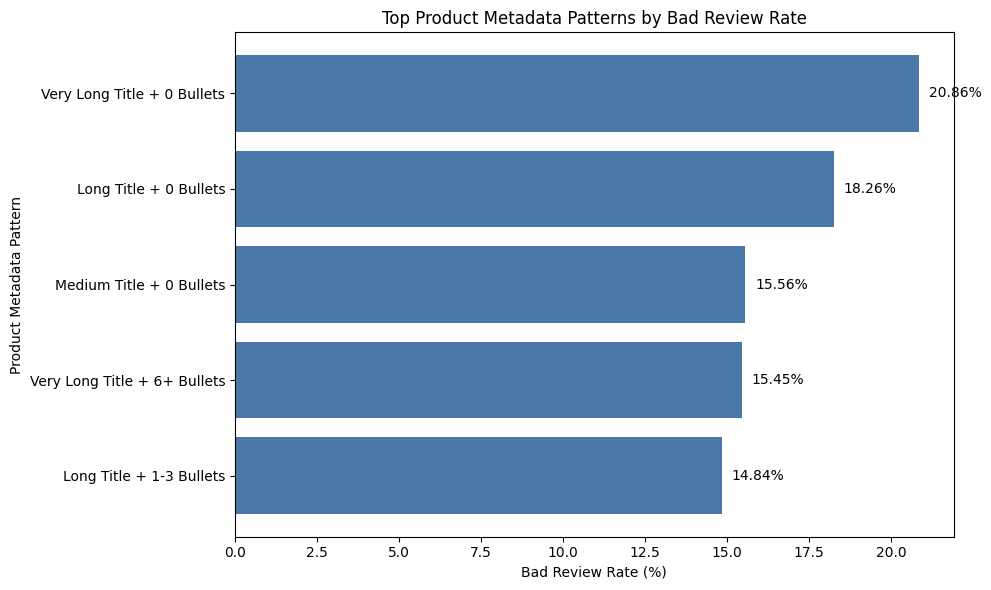

In [ ]:
# ============================================
# 2.5.2 Presentation Graph
# Top Product Metadata Patterns
# ============================================

# สร้าง metadata_analysis ก่อนเพื่อป้องกัน Error
metadata_analysis = (
    analysis_df
    .groupby(
        ["title_length_group", "feature_bullet_group"],
        observed=False
    )
    .agg(
        review_count=("rating", "count"),
        product_count=("parent_asin", "nunique"),
        bad_review_count=("bad_review", "sum")
    )
    .reset_index()
)

metadata_analysis["bad_review_rate"] = (
    metadata_analysis["bad_review_count"]
    / metadata_analysis["review_count"]
    * 100
)

# เรียงจาก Bad Review Rate สูงไปต่ำ
metadata_analysis = metadata_analysis.sort_values(
    by=["bad_review_rate", "review_count"],
    ascending=[False, False]
)

# เลือก Top 5 Metadata Patterns
top_metadata = (
    metadata_analysis[
        metadata_analysis["review_count"] >= 500
    ]
    .head(5)
    .sort_values("bad_review_rate", ascending=True)
    .copy()
)

# สร้างชื่อ Pattern
top_metadata["metadata_pattern"] = (
    top_metadata["title_length_group"].astype(str)
    + " Title + "
    + top_metadata["feature_bullet_group"].astype(str)
    + " Bullets"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_metadata["metadata_pattern"],
    top_metadata["bad_review_rate"],
    color="#4C78A8"
)

plt.xlabel("Bad Review Rate (%)")
plt.ylabel("Product Metadata Pattern")
plt.title(
    "Top Product Metadata Patterns by Bad Review Rate"
)

for i, value in enumerate(
    top_metadata["bad_review_rate"]
):
    plt.text(
        value + 0.3,
        i,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

### คำอธิบายผลการวิเคราะห์ Product Metadata

จากการเปรียบเทียบ Product Metadata พบว่า Bad Review Rate มีความแตกต่างกันตามลักษณะของ Product Title และจำนวน Feature Bullets

เมื่อพิจารณาตามความยาวของ Product Title พบว่า Bad Review Rate มีแนวโน้มเพิ่มขึ้นตามความยาวของ Title โดยกลุ่ม Short มี Bad Review Rate **11.46%**, Medium **12.19%**, Long **14.41%** และ Very Long **14.76%**

เมื่อพิจารณาตามจำนวน Feature Bullets พบว่ากลุ่มที่ไม่มี Feature Bullets (`0`) มี Bad Review Rate สูงที่สุดที่ **16.77%** จาก 3,112 Reviews ขณะที่กลุ่ม 1–3 Feature Bullets มี Bad Review Rate **11.97%**, กลุ่ม 4–5 อยู่ที่ **13.02%** และกลุ่ม 6+ อยู่ที่ **13.23%**

เมื่อวิเคราะห์ Product Title Length และ Feature Bullet Count ร่วมกัน พบว่า Pattern ที่มี Bad Review Rate สูงที่สุดคือ **Very Long Title + 0 Feature Bullets** โดยมี 671 Reviews จาก 503 Products และมี Bad Reviews จำนวน 140 Reviews คิดเป็น Bad Review Rate **20.86%**

Pattern ดังกล่าวจึงเป็น **Product Metadata Pattern ที่ควรได้รับการตรวจสอบเพิ่มเติม** เนื่องจากมี Bad Review Rate สูงที่สุด และมีจำนวนข้อมูลมากพอที่จะใช้เป็นสัญญาณเบื้องต้นในการวิเคราะห์

### Business Insight 2

ผลการวิเคราะห์ชี้ให้เห็นว่า Product ที่มี **Title ยาวมากและไม่มี Feature Bullets** มี Bad Review Rate สูงกว่ากลุ่ม Metadata อื่น ๆ ใน Sample

ดังนั้น Product Team สามารถใช้ Pattern นี้เป็น **Warning Signal สำหรับคัดกรอง Product ที่ควรตรวจสอบ Product Metadata เพิ่มเติม** โดยเฉพาะ Product ที่มีลักษณะ Very Long Title และไม่มี Feature Bullets

อย่างไรก็ตาม ผลลัพธ์นี้สะท้อนเพียง **ความสัมพันธ์ที่พบในข้อมูล** ไม่สามารถสรุปได้ว่า Title ที่ยาวหรือการไม่มี Feature Bullets เป็นสาเหตุโดยตรงของ Bad Review เนื่องจากข้อมูลที่ใช้ไม่มี Customer Review Text สำหรับตรวจสอบสาเหตุหรือความคิดเห็นของลูกค้าโดยตรง

In [ ]:
# --------------------------------------------
# 3. Combined Product Metadata Analysis
# --------------------------------------------

metadata_analysis = (
    analysis_df
    .groupby(
        ["title_length_group", "feature_bullet_group"],
        observed=False
    )
    .agg(
        review_count=("rating", "count"),
        product_count=("parent_asin", "nunique"),
        bad_review_count=("bad_review", "sum")
    )
    .reset_index()
)

# คำนวณ Bad Review Rate (%)
metadata_analysis["bad_review_rate"] = (
    metadata_analysis["bad_review_count"]
    / metadata_analysis["review_count"]
    * 100
)

# เรียงจาก Bad Review Rate สูงไปต่ำ
metadata_analysis = metadata_analysis.sort_values(
    by=["bad_review_rate", "review_count"],
    ascending=[False, False]
)

print("=== Product Metadata Pattern ===")

display(
    metadata_analysis.style.format({
        "bad_review_rate": "{:.2f}%"
    })
)

=== Product Metadata Pattern ===


,title_length_group,feature_bullet_group,review_count,product_count,bad_review_count,bad_review_rate
12,Very Long,0,671,503,140,20.86%
8,Long,0,898,687,164,18.26%
4,Medium,0,945,750,147,15.56%
15,Very Long,6+,1165,346,180,15.45%
9,Long,1-3,512,257,76,14.84%
14,Very Long,4-5,9848,3584,1406,14.28%
10,Long,4-5,10261,4621,1446,14.09%
11,Long,6+,955,338,133,13.93%
13,Very Long,1-3,104,63,14,13.46%
3,Short,6+,1133,436,142,12.53%


### 2.5.3 Combined Business Insight

จากผลการวิเคราะห์ทั้งในระดับ Product และ Product Metadata สามารถนำผลลัพธ์มาประกอบกันเพื่อช่วย Product Team จัดลำดับความสำคัญในการตรวจสอบสินค้าได้

**Insight 1: Product ที่ควรได้รับการตรวจสอบก่อน**

จากการวิเคราะห์ระดับ Product พบว่า `B002UR3JVI` และ `B08BN8S4NM` มี Bad Review Rate สูงที่สุดที่ **80.00%** โดยแต่ละ Product มี 5 Reviews และมี Bad Reviews จำนวน 4 Reviews

อย่างไรก็ตาม จำนวน Reviews ของ Product เหล่านี้ยังไม่สูงมาก ดังนั้นจึงควรใช้ผลลัพธ์ดังกล่าวเป็น **Warning Signal** สำหรับคัดกรอง Product ที่ควรตรวจสอบเพิ่มเติม มากกว่าการสรุปว่า Product มีปัญหาอย่างแน่นอน

**Insight 2: Product Metadata Pattern ที่ควรตรวจสอบ**

จากการวิเคราะห์ Product Metadata พบว่า Pattern ที่มี Bad Review Rate สูงที่สุดคือ **Very Long Title + 0 Feature Bullets** โดยมี 671 Reviews จาก 503 Products และมี Bad Review Rate **20.86%**

Pattern ดังกล่าวจึงเป็นสัญญาณที่น่าสนใจสำหรับ Product Team เนื่องจากมีจำนวนข้อมูลมากกว่าการพิจารณา Product รายตัวที่มีเพียง 5–8 Reviews

**Combined Business Insight**

เมื่อพิจารณาผลลัพธ์ทั้งสองด้านร่วมกัน Product Team สามารถแบ่งการตรวจสอบออกเป็น 2 ระดับ ได้แก่

1. **ตรวจสอบ Product รายตัวที่มี Bad Review Rate สูง** เพื่อค้นหา Product ที่มีสัญญาณความเสี่ยงสูง เช่น `B002UR3JVI` และ `B08BN8S4NM`

2. **ตรวจสอบ Product ที่มี Metadata Pattern เป็น Very Long Title + 0 Feature Bullets** เนื่องจาก Pattern นี้มี Bad Review Rate สูงที่สุดในกลุ่มที่มีจำนวนข้อมูลมากเพียงพอ

ดังนั้น หากมีทรัพยากรจำกัด ควรเริ่มจากการตรวจสอบ **Product ที่มีสัญญาณ Bad Review สูง** ควบคู่กับการตรวจสอบ **Metadata Pattern ที่มี Bad Review Rate สูง** เพื่อใช้เป็นเกณฑ์ในการคัดกรอง Product สำหรับการตรวจสอบเพิ่มเติม

ทั้งนี้ ผลการวิเคราะห์เป็นการระบุ **ความสัมพันธ์และ Warning Signal จากข้อมูล** ไม่ได้ยืนยันว่า Product หรือ Product Metadata เป็นสาเหตุโดยตรงของ Bad Review เนื่องจาก Dataset ไม่มี Customer Review Text สำหรับวิเคราะห์สาเหตุของความคิดเห็นลูกค้า

## 2.6 Reality Check

### 2.6.1 ทดสอบผลของขนาด (Sample Size Effect)

จาก Insight 1 พบว่า Product `B002UR3JVI` และ `B08BN8S4NM` มี Bad Review Rate สูงที่สุดที่ **80.00%** แต่ทั้งสอง Product มีจำนวน Reviews เพียง **5 Reviews** เท่านั้น

จึงตั้งข้อสังเกตว่า Bad Review Rate ที่สูงอาจเกิดจาก **จำนวน Reviews ที่น้อย** เนื่องจาก Bad Reviews เพียงไม่กี่รายการสามารถทำให้สัดส่วน Bad Review Rate สูงขึ้นได้

ดังนั้นจึงทำ Reality Check โดยเปลี่ยน **Minimum Review Threshold** จาก 5 Reviews เป็น **10, 15 และ 20 Reviews** แล้วเปรียบเทียบว่า Product ที่มี Bad Review Rate สูงที่สุดยังคงเป็นกลุ่มเดิมหรือมีการเปลี่ยนแปลง

การทดสอบนี้ใช้เพื่อตรวจสอบว่า Insight 1 มีความเสถียรเมื่อพิจารณา Product ที่มีจำนวน Reviews มากขึ้นหรือไม่

In [ ]:
# ============================================
# 2.6 Reality Check
# Sample Size Effect
# ============================================

# กำหนด Minimum Review Threshold
thresholds = [5, 10, 15, 20]

reality_check_results = []

for threshold in thresholds:

    # เลือกเฉพาะ Product ที่มีจำนวน Reviews
    # มากกว่าหรือเท่ากับ Threshold
    temp = product_summary[
        product_summary["review_count"] >= threshold
    ].copy()

    # เรียงจาก Bad Review Rate สูงสุด
    temp = temp.sort_values(
        by=["bad_review_rate", "review_count"],
        ascending=[False, False]
    )

    # Product อันดับ 1
    top_product = temp.iloc[0]

    reality_check_results.append({
        "Minimum Reviews": threshold,
        "Number of Products": len(temp),
        "Top Product": top_product["parent_asin"],
        "Review Count": top_product["review_count"],
        "Bad Review Count": top_product["bad_review_count"],
        "Bad Review Rate (%)": top_product["bad_review_rate"],
        "Average Rating": top_product["avg_rating"]
    })

# สร้าง DataFrame สำหรับแสดงผล
reality_check_df = pd.DataFrame(
    reality_check_results
)

display(
    reality_check_df.style.format({
        "Bad Review Rate (%)": "{:.2f}%",
        "Average Rating": "{:.2f}"
    })
)

,Minimum Reviews,Number of Products,Top Product,Review Count,Bad Review Count,Bad Review Rate (%),Average Rating
0,5,1713,B002UR3JVI,5,4,80.00%,1.40
1,10,567,B076F5W8Q5,14,8,57.14%,2.79
2,15,316,B01AAX6KGY,16,8,50.00%,2.88
3,20,192,B09HZMX75B,22,10,45.45%,3.00


In [ ]:
# ============================================
# ตรวจสอบ Product ที่มี Bad Review Rate 80%
# ============================================

insight1_products = product_summary[
    product_summary["parent_asin"].isin([
        "B002UR3JVI",
        "B08BN8S4NM"
    ])
].copy()

display(
    insight1_products[
        [
            "parent_asin",
            "review_count",
            "bad_review_count",
            "bad_review_rate",
            "avg_rating"
        ]
    ].style.format({
        "bad_review_rate": "{:.2f}%",
        "avg_rating": "{:.2f}"
    })
)

,parent_asin,review_count,bad_review_count,bad_review_rate,avg_rating
3066,B002UR3JVI,5,4,80.00%,1.40
18652,B08BN8S4NM,5,4,80.00%,1.80


### 2.6.2 ผลการ Reality Check

ผลการ Reality Check พบว่าเมื่อเพิ่ม Minimum Review Threshold จาก **5 เป็น 10, 15 และ 20 Reviews** ทั้ง Product ที่มี Bad Review Rate สูงสุดและค่า Bad Review Rate สูงสุดมีการเปลี่ยนแปลงอย่างชัดเจน

เมื่อกำหนด Minimum Reviews = 5 Product `B002UR3JVI` มี Bad Review Rate สูงสุดที่ **80.00%** จาก 5 Reviews โดยเป็น Bad Review จำนวน 4 Reviews อย่างไรก็ตาม เมื่อเพิ่ม Threshold เป็น 10 Reviews Product ดังกล่าวไม่ติดอันดับอีกต่อไป และ Top Product เปลี่ยนเป็น `B076F5W8Q5` ซึ่งมี Bad Review Rate **57.14%** จาก 14 Reviews

เมื่อเพิ่ม Threshold เป็น 15 และ 20 Reviews พบว่า Top Product เปลี่ยนเป็น `B01AAX6KGY` และ `B09HZMX75B` ตามลำดับ ขณะที่ Bad Review Rate สูงสุดลดลงจาก **80.00% → 57.14% → 50.00% → 45.45%**

ผลดังกล่าวแสดงให้เห็นว่า **Bad Review Rate มีความไวต่อจำนวน Reviews** โดย Product ที่มีจำนวน Reviews น้อยสามารถมี Bad Review Rate สูงได้จาก Bad Reviews เพียงไม่กี่รายการ และเมื่อพิจารณา Product ที่มี Reviews มากขึ้น ผลการจัดอันดับจะเปลี่ยนแปลง

ดังนั้น Insight 1 ไม่ควรถูกตีความว่า Product ที่มี Bad Review Rate สูงที่สุดเป็น Product ที่มีปัญหามากที่สุดโดยตรง แต่ควรใช้ **Bad Review Rate ร่วมกับ Review Count** เพื่อเพิ่มความน่าเชื่อถือในการจัดลำดับความสำคัญ

### การปรับ Insight หลัง Reality Check

จากเดิมที่อาจกล่าวว่า

> "Product ที่มี Bad Review Rate สูงที่สุดควรได้รับการปรับปรุงก่อน"

จึงปรับเป็น

> **"Product ที่มี Bad Review Rate สูงและมีจำนวน Reviews ผ่าน Minimum Review Threshold สามารถใช้เป็น Warning Signal สำหรับคัดกรอง Product ที่ควรได้รับการตรวจสอบเพิ่มเติม"**

ดังนั้น Product Team ควรใช้ผลลัพธ์นี้เป็น **Warning Signal** ไม่ใช่เกณฑ์ตัดสิน Product โดยอัตโนมัติ และควรพิจารณา Bad Review Rate ร่วมกับจำนวน Reviews ก่อนจัดสรรทรัพยากรเพื่อปรับปรุง Product

## 2.7 Insight Cards



### Insight Card 1

> **Insight:** Product ที่มี Bad Review Rate สูงควรถูกใช้เป็น **Warning Signal** สำหรับคัดกรอง Product ที่ควรได้รับการตรวจสอบเพิ่มเติม โดยต้องพิจารณา Bad Review Rate ร่วมกับจำนวน Reviews
>
> **หลักฐาน:** จากการวิเคราะห์ Product-level เมื่อกำหนด Minimum Reviews = 5 พบว่า `B002UR3JVI` มี Bad Review Rate สูงสุดที่ **80.00%** จาก 5 Reviews โดยมี Bad Review จำนวน 4 Reviews อย่างไรก็ตาม จาก Reality Check เมื่อเพิ่ม Minimum Review Threshold เป็น 10, 15 และ 20 Reviews พบว่า Top Product เปลี่ยนไป และ Bad Review Rate สูงสุดลดลงจาก **80.00% → 57.14% → 50.00% → 45.45%**
>
> **So what:** Bad Review Rate เพียงอย่างเดียวอาจทำให้จัดลำดับ Product ผิดได้ เพราะ Product ที่มี Reviews น้อยสามารถมี Rate สูงจาก Bad Reviews เพียงไม่กี่รายการ ดังนั้น Product Team ควรใช้ทั้ง Bad Review Rate และ Review Count เพื่อประเมินความสำคัญ
>
> **Action:** สร้าง Warning List โดยคัดกรอง Product ที่มี Bad Review Rate สูงและมีจำนวน Reviews ผ่าน Minimum Review Threshold จากนั้นเลือก Product ที่มีสัญญาณสูงไปตรวจสอบเพิ่มเติมก่อนตัดสินใจปรับปรุงจริง
>
> **วัดผลอย่างไร:** ติดตาม Bad Review Rate และ Average Rating ของ Product ที่ถูกคัดกรองเมื่อมี Reviews เพิ่มขึ้น และเปรียบเทียบผลก่อนและหลังการตรวจสอบหรือปรับปรุง Product
>
> **ความมั่นใจ:** **ปานกลาง** — พบสัญญาณชัดเจน แต่ Reality Check แสดงให้เห็นว่าอันดับ Product และ Bad Review Rate เปลี่ยนไปตาม Minimum Review Threshold จึงควรใช้เป็น Warning Signal ไม่ใช่ข้อสรุปเด็ดขาด


=== Insight Card 1 ===
Minimum Review Threshold: 20 Reviews
Number of Products: 192
Top Product: B09HZMX75B
Review Count: 22
Bad Review Count: 10
Bad Review Rate: 45.45%
Average Rating: 3.00


,parent_asin,review_count,bad_review_count,bad_review_rate,avg_rating
21027,B09HZMX75B,22,10,45.45%,3.00
11296,B01M72N0A6,46,19,41.30%,3.04
11571,B01N48FPRS,22,9,40.91%,3.05
8442,B00TOKTBL6,24,9,37.50%,3.25
17030,B07VPLFNYM,22,8,36.36%,3.27
21974,B0B18F931F,28,9,32.14%,3.64
24084,B0C43X1YDH,22,7,31.82%,3.41
11244,B01M2XPNLC,24,7,29.17%,3.25
23614,B0BTR12G3V,86,25,29.07%,3.56
14136,B07BSZNKTM,21,6,28.57%,3.62


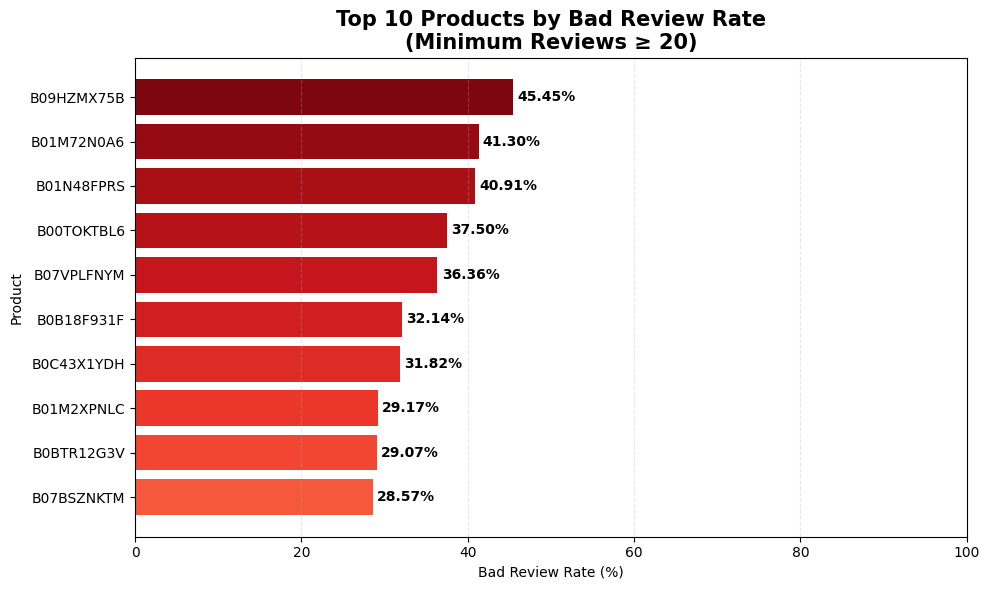

In [ ]:
# ============================================
# 2.7 Insight Card 1
# Product Priority: Bad Review Rate + Review Count
# ============================================

# กำหนด Minimum Review Threshold
# หลังจากทำ Reality Check
MIN_REVIEWS_CARD = 20

# เลือกเฉพาะ Product ที่มี Reviews >= 20
insight_card_1 = (
    product_summary[
        product_summary["review_count"] >= MIN_REVIEWS_CARD
    ]
    .copy()
)

# เรียง Product ตาม Bad Review Rate สูงสุด
# ถ้า Rate เท่ากัน ให้ Product ที่มี Reviews มากกว่าอยู่ก่อน
insight_card_1 = insight_card_1.sort_values(
    by=["bad_review_rate", "review_count"],
    ascending=[False, False]
)

# --------------------------------------------
# แสดงข้อมูลสำหรับ Insight Card 1
# --------------------------------------------

top_product = insight_card_1.iloc[0]

print("=== Insight Card 1 ===")

print(f"Minimum Review Threshold: {MIN_REVIEWS_CARD} Reviews")
print(f"Number of Products: {len(insight_card_1)}")
print(f"Top Product: {top_product['parent_asin']}")
print(f"Review Count: {int(top_product['review_count'])}")
print(f"Bad Review Count: {int(top_product['bad_review_count'])}")
print(f"Bad Review Rate: {top_product['bad_review_rate']:.2f}%")
print(f"Average Rating: {top_product['avg_rating']:.2f}")


# --------------------------------------------
# แสดง Top 10 Products
# --------------------------------------------

display(
    insight_card_1[
        [
            "parent_asin",
            "review_count",
            "bad_review_count",
            "bad_review_rate",
            "avg_rating"
        ]
    ]
    .head(10)
    .style.format({
        "bad_review_rate": "{:.2f}%",
        "avg_rating": "{:.2f}"
    })
)


# ============================================
# Graph: Top 10 Products by Bad Review Rate
# ============================================

# เลือก Top 10 Products
top_products_card1 = (
    insight_card_1
    .head(10)
    .sort_values(
        "bad_review_rate",
        ascending=True
    )
    .copy()
)

plt.figure(figsize=(10, 6))

# สีแดงไล่ระดับเพื่อสื่อถึง Bad Review
colors = plt.cm.Reds(
    np.linspace(
        0.55,
        0.95,
        len(top_products_card1)
    )
)

plt.barh(
    top_products_card1["parent_asin"],
    top_products_card1["bad_review_rate"],
    color=colors
)

plt.xlabel("Bad Review Rate (%)")
plt.ylabel("Product")

plt.title(
    "Top 10 Products by Bad Review Rate\n"
    "(Minimum Reviews ≥ 20)",
    fontsize=15,
    fontweight="bold"
)

# แสดงค่า Bad Review Rate บนแท่ง
for i, value in enumerate(
    top_products_card1["bad_review_rate"]
):
    plt.text(
        value + 0.5,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.xlim(0, 100)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### คำอธิบายผล Insight Card 1

จากการกำหนด **Minimum Review Threshold = 20 Reviews** พบว่ามี Product ที่ผ่านเกณฑ์ทั้งหมด **192 Products** ซึ่งเป็นการคัดกรอง Product ที่มีจำนวน Reviews มากพอสำหรับใช้เป็นสัญญาณในการจัดลำดับความสำคัญ

ผลการวิเคราะห์พบว่า Product `B09HZMX75B` มี Bad Review Rate สูงที่สุดที่ **45.45%** จากทั้งหมด **22 Reviews** โดยเป็น Bad Review จำนวน **10 Reviews** และมี Average Rating เท่ากับ **3.00**

รองลงมาคือ Product `B01M72N0A6` ซึ่งมี 46 Reviews และ Bad Review Rate **41.30%** และ Product `B01N48FPRS` ซึ่งมี 22 Reviews และ Bad Review Rate **40.91%**

ผลลัพธ์นี้แสดงให้เห็นว่าเมื่อกำหนด Minimum Review Threshold ที่ 20 Reviews เราสามารถคัดกรอง Product ที่มีสัดส่วน Bad Review สูงและมีข้อมูล Reviews มากกว่ากรณีที่ใช้ Threshold เพียง 5 Reviews

### Business Insight

Product ที่มี **Bad Review Rate สูงและมีจำนวน Reviews ผ่าน Minimum Review Threshold** สามารถใช้เป็น **Warning Signal** สำหรับคัดกรอง Product ที่ควรได้รับการตรวจสอบเพิ่มเติม

ดังนั้น `B09HZMX75B` เป็น Product ที่ควรถูกนำไปตรวจสอบเพิ่มเติมเป็นลำดับต้น ๆ เนื่องจากมี Bad Review Rate สูงที่สุดในกลุ่ม Product ที่มีอย่างน้อย 20 Reviews

อย่างไรก็ตาม ผลลัพธ์นี้ไม่ได้หมายความว่า `B09HZMX75B` เป็น Product ที่มีปัญหามากที่สุดอย่างแน่นอน แต่เป็นเพียงสัญญาณสำหรับจัดลำดับการตรวจสอบ เนื่องจาก Bad Review Rate ยังสามารถเปลี่ยนแปลงได้เมื่อมี Reviews เพิ่มขึ้น

### ข้อจำกัด

ผลการวิเคราะห์นี้ใช้ข้อมูล **Rating** เพื่อระบุ Bad Review โดยกำหนด Rating ≤ 2 เป็น Bad Review แต่ Dataset ไม่มี **Customer Review Text** ดังนั้นเราสามารถระบุได้ว่า Product ใดมีสัญญาณ Bad Review สูง แต่ไม่สามารถระบุได้ว่าลูกค้าไม่พอใจเรื่องใดหรือเกิดจากสาเหตุอะไรโดยตรง

### Insight Card 2

> **Insight:**  
> พบว่า Product Metadata Pattern ที่มี **Very Long Title + 0 Feature Bullets** มี Bad Review Rate สูงถึง **20.86%** จาก 671 Reviews และ 503 Products ซึ่งสูงกว่า Pattern ที่มี Very Long Title + 4–5 Feature Bullets ที่มี Bad Review Rate **14.28%**

> **หลักฐาน:**  
> Pattern **Very Long Title + 0 Feature Bullets** มี Bad Reviews จำนวน **140 จาก 671 Reviews** ขณะที่ Pattern **Very Long Title + 4–5 Feature Bullets** มี Bad Review Rate **14.28%** ทำให้เกิดความแตกต่างประมาณ **6.59 percentage points**

> **So what:**  
> Pattern **Very Long Title + 0 Feature Bullets** เป็น **Warning Signal** ที่น่าสนใจสำหรับ Product Team เพราะกลุ่มนี้มีสัดส่วน Bad Review สูงกว่า Pattern ที่มี Feature Bullets หลายรายการ อย่างไรก็ตาม ผลลัพธ์นี้แสดงเพียงความสัมพันธ์ที่พบในข้อมูล และไม่สามารถสรุปได้ว่า Product Metadata เป็นสาเหตุโดยตรงของ Bad Review

> **Action:**  
> Product Team ควรนำ Product ที่มี Pattern **Very Long Title + 0 Feature Bullets** ไปตรวจสอบเพิ่มเติม โดยเฉพาะ Product ที่มี Bad Review Rate สูง เพื่อพิจารณาว่าการนำเสนอข้อมูลสินค้า เช่น Product Title และ Feature Bullets ควรได้รับการปรับปรุงหรือไม่

> **วัดผลอย่างไร:**  
> ติดตาม **Bad Review Rate, Average Rating และจำนวน Bad Reviews** ของ Product ที่ได้รับการปรับปรุง และเปรียบเทียบผลก่อน–หลังการปรับปรุง รวมถึงติดตามผลเมื่อมี Reviews เพิ่มขึ้น

> **ความมั่นใจ:**  
> **ปานกลาง** เพราะ Pattern นี้มีข้อมูลจำนวนค่อนข้างมาก ทั้ง 671 Reviews และ 503 Products แต่ Dataset ไม่มี Customer Review Text จึงไม่สามารถยืนยันได้ว่า Feature Bullets หรือความยาวของ Product Title เป็นสาเหตุที่ทำให้ลูกค้าให้ Rating ต่ำ

=== Insight Card 2 ===
Minimum Review Threshold: 500 Reviews


,title_length_group,feature_bullet_group,review_count,product_count,bad_review_count,bad_review_rate,avg_rating
12,Very Long,0,671,503,140,20.86%,3.99
8,Long,0,898,687,164,18.26%,4.03
4,Medium,0,945,750,147,15.56%,4.12
15,Very Long,6+,1165,346,180,15.45%,4.19
9,Long,1-3,512,257,76,14.84%,4.20
14,Very Long,4-5,9848,3584,1406,14.28%,4.22
10,Long,4-5,10261,4621,1446,14.09%,4.22
11,Long,6+,955,338,133,13.93%,4.20
3,Short,6+,1133,436,142,12.53%,4.28
6,Medium,4-5,8915,4568,1083,12.15%,4.30


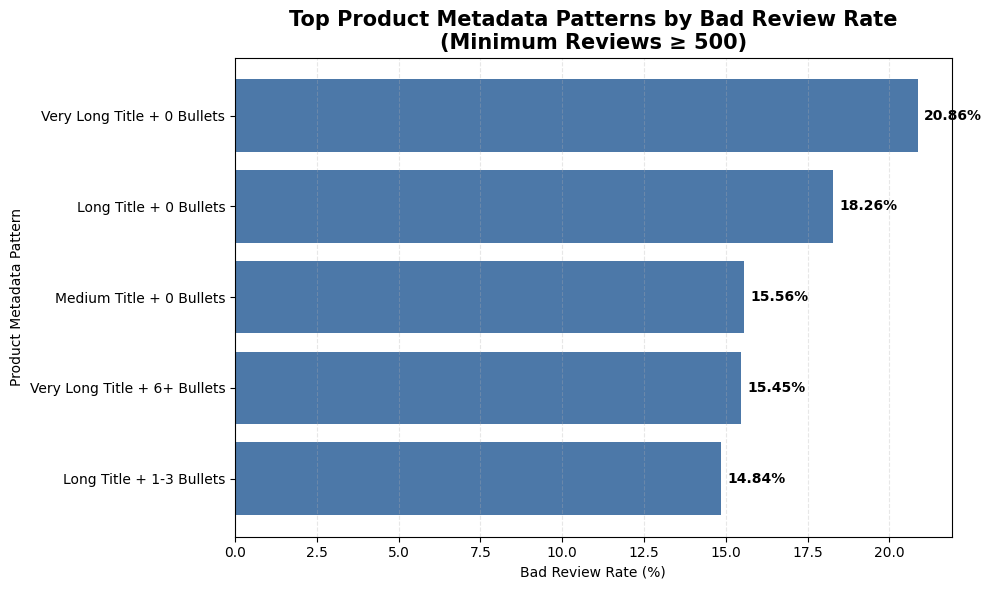

In [ ]:
# ============================================
# 2.7 Insight Card 2
# Product Metadata Pattern:
# Very Long Title + 0 Feature Bullets
# ============================================

# --------------------------------------------
# 1) สร้างตาราง Product Metadata Pattern
# --------------------------------------------

metadata_analysis = (
    analysis_df
    .groupby(
        ["title_length_group", "feature_bullet_group"],
        observed=True
    )
    .agg(
        review_count=("rating", "count"),
        product_count=("parent_asin", "nunique"),
        bad_review_count=("bad_review", "sum"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)

metadata_analysis["bad_review_rate"] = (
    metadata_analysis["bad_review_count"]
    / metadata_analysis["review_count"]
    * 100
)


# --------------------------------------------
# 2) กำหนด Minimum Review Threshold
# --------------------------------------------

MIN_REVIEWS_METADATA = 500

metadata_priority = (
    metadata_analysis[
        metadata_analysis["review_count"] >= MIN_REVIEWS_METADATA
    ]
    .copy()
    .sort_values(
        by=["bad_review_rate", "review_count"],
        ascending=[False, False]
    )
)


# --------------------------------------------
# 3) แสดงผล Top Metadata Patterns
# --------------------------------------------

print("=== Insight Card 2 ===")
print(
    f"Minimum Review Threshold: "
    f"{MIN_REVIEWS_METADATA} Reviews"
)

display(
    metadata_priority[
        [
            "title_length_group",
            "feature_bullet_group",
            "review_count",
            "product_count",
            "bad_review_count",
            "bad_review_rate",
            "avg_rating"
        ]
    ]
    .head(10)
    .style.format({
        "bad_review_rate": "{:.2f}%",
        "avg_rating": "{:.2f}"
    })
)


# --------------------------------------------
# 4) เลือก Top 5 Metadata Patterns สำหรับกราฟ
# --------------------------------------------

top_metadata_card2 = (
    metadata_priority
    .head(5)
    .sort_values(
        "bad_review_rate",
        ascending=True
    )
    .copy()
)

top_metadata_card2["metadata_pattern"] = (
    top_metadata_card2["title_length_group"].astype(str)
    + " Title + "
    + top_metadata_card2["feature_bullet_group"].astype(str)
    + " Bullets"
)


# --------------------------------------------
# 5) สร้างกราฟ
# --------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top_metadata_card2["metadata_pattern"],
    top_metadata_card2["bad_review_rate"],
    color="#4C78A8"
)

plt.xlabel("Bad Review Rate (%)")
plt.ylabel("Product Metadata Pattern")

plt.title(
    "Top Product Metadata Patterns by Bad Review Rate\n"
    "(Minimum Reviews ≥ 500)",
    fontsize=15,
    fontweight="bold"
)

for i, value in enumerate(
    top_metadata_card2["bad_review_rate"]
):
    plt.text(
        value + 0.2,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### คำอธิบายผล Insight Card 2

จากการวิเคราะห์ Product Metadata โดยกำหนด **Minimum Review Threshold = 500 Reviews** พบว่า Pattern ที่มี Bad Review Rate สูงที่สุดคือ **Very Long Title + 0 Feature Bullets** โดยมี Bad Review Rate **20.86%** จาก Reviews จำนวน **671 Reviews** และครอบคลุม **503 Products** มี Bad Reviews จำนวน **140 Reviews** และ Average Rating เท่ากับ **3.99**

นอกจากนี้ เมื่อพิจารณา Pattern ที่มี Bad Review Rate สูงสุด 3 อันดับแรก พบว่าเป็นกลุ่มที่มี **Feature Bullets = 0 ทั้งหมด** ได้แก่

1. **Very Long Title + 0 Feature Bullets** → Bad Review Rate **20.86%**
2. **Long Title + 0 Feature Bullets** → Bad Review Rate **18.26%**
3. **Medium Title + 0 Feature Bullets** → Bad Review Rate **15.56%**

ผลดังกล่าวแสดงให้เห็นว่า Pattern ที่ไม่มี Feature Bullets มี Bad Review Rate ค่อนข้างสูง โดยเฉพาะเมื่อใช้ร่วมกับ Title ที่มีความยาวมาก จึงเป็น **Warning Signal** ที่น่าสนใจสำหรับ Product Team ในการคัดกรอง Product ที่ควรได้รับการตรวจสอบเพิ่มเติม

อย่างไรก็ตาม ผลลัพธ์นี้เป็นเพียง **ความสัมพันธ์ที่พบในข้อมูล** ไม่สามารถสรุปได้ว่า Product Title ที่ยาวหรือการไม่มี Feature Bullets เป็นสาเหตุโดยตรงที่ทำให้ลูกค้าให้ Rating ต่ำ เนื่องจาก Dataset ไม่มี **Customer Review Text** จึงไม่สามารถตรวจสอบเหตุผลหรือปัญหาที่ลูกค้ากล่าวถึงโดยตรงได้

ดังนั้น Product Team ควรนำ Product ที่อยู่ใน Pattern **Very Long Title + 0 Feature Bullets** ไปตรวจสอบเพิ่มเติม โดยเฉพาะ Product ที่มี Bad Review Rate สูง และพิจารณาว่าการนำเสนอข้อมูลสินค้า เช่น Product Title และ Feature Bullets ควรได้รับการปรับปรุงหรือไม่



เพื่อสื่อสารผลการวิเคราะห์และ Business Insights ให้เข้าใจได้ง่ายขึ้น ส่วนนี้นำเสนอ Main Visualizations ที่สรุป Evidence สำคัญจากการวิเคราะห์ใน Section 6–8 โดยเน้นการเปรียบเทียบกลุ่ม Product Metadata และการแสดงสัญญาณ Bad Review ในระดับ Product

Visualization เหล่านี้มีวัตถุประสงค์เพื่อช่วยให้เห็นความแตกต่างของผลลัพธ์จากข้อมูลได้อย่างชัดเจน และสนับสนุนการคัดกรอง Product ที่ควรตรวจสอบเพิ่มเติม โดยยังคงตีความผลในลักษณะเชิงพรรณนาและไม่สรุปความสัมพันธ์เชิงเหตุและผล

# Part 3: Data Collection Robot + External Business Insight




## Setup

ส่วนนี้เป็นการนำเข้าไลบรารี Python ที่จำเป็นสำหรับการเก็บรวบรวมข้อมูล การจัดการข้อมูล และการวิเคราะห์ข้อมูลเบื้องต้น

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

print("Libraries imported successfully.")

Libraries imported successfully.


## 3.1 เลือกแหล่งข้อมูลและวิธีเก็บ

- **แหล่งข้อมูล:** Music Stack Exchange  
  เว็บไซต์: https://music.stackexchange.com

- **คำถาม:** หัวข้อด้านดนตรีประเภทใดถูกถามบ่อยและได้รับความสนใจสูงใน Music Stack Exchange และหัวข้อใดมีคำถามจำนวนมากหรือมี Engagement สูง แต่มี Answered Rate ต่ำ?

- **ผู้ใช้ผลวิเคราะห์:** Content / Knowledge Team

- **1 record คือ:** 1 คำถามบน Music Stack Exchange

- **วิธีเก็บ:** API (Stack Exchange API)

- **field สำคัญที่จะเก็บ:** question_id, title, body, tags, score, view_count, answer_count, is_answered, creation_date, link


### ตัวอย่างที่ 1: Stack Exchange API แบบสั้น

ใช้ Stack Exchange API เพื่อดึงข้อมูลคำถามจาก Music Stack Exchange โดยทดลองเชื่อมต่อ API ก่อน จากนั้นจึงดึงข้อมูลจริงจำนวน 300 records

#### 3.1.1 ทดสอบการเชื่อมต่อ API

ทดลองดึงข้อมูลจำนวน 10 คำถามก่อน เพื่อเช็กว่า API สามารถเชื่อมต่อและส่งข้อมูลกลับมาได้ตามปกติ

In [ ]:
import requests
import pandas as pd

url = "https://api.stackexchange.com/2.3/questions"

params = {
    "site": "music",
    "pagesize": 10,
    "order": "desc",
    "sort": "creation",
    "filter": "withbody"
}

response = requests.get(url, params=params)
data = response.json()

print("Status Code:", response.status_code)
print("Records:", len(data.get("items", [])))

data.get("items", [])[:2]

Status Code: 200
Records: 10


[{'tags': ['chord-progressions', 'jazz'],
  'owner': {'account_id': 44671654,
   'reputation': 43,
   'user_id': 135395,
   'user_type': 'registered',
   'profile_image': 'https://www.gravatar.com/avatar/aa404e130e4b3504d25ccc916fdcab4b?s=256&d=identicon&r=PG&f=y&so-version=2',
   'display_name': 'Rosalie Shirley',
   'link': 'https://music.stackexchange.com/users/135395/rosalie-shirley'},
  'is_answered': False,
  'view_count': 65,
  'answer_count': 0,
  'score': 0,
  'last_activity_date': 1791097692,
  'creation_date': 1791075916,
  'last_edit_date': 1791097692,
  'question_id': 144345,
  'content_license': 'CC BY-SA 4.0',
  'link': 'https://music.stackexchange.com/questions/144345/analyze-this-jazz-chord-progression',
  'title': 'Analyze this jazz chord progression',
  'body': '<p>How should I analyze this chord progression (both the upper and below), why is an Eb7 used, like that?</p>\n<p><a href="https://i.sstatic.net/rE2bCJ0k.png" rel="nofollow noreferrer"><img src="https://i.sst

**ผลการทดสอบ:** API สามารถเชื่อมต่อได้สำเร็จ โดย Status Code = 200 และสามารถดึงข้อมูลคำถามจาก Music Stack Exchange ได้

#### 3.1.2 กำหนดค่า API สำหรับเก็บข้อมูลจริง

หลังจากทดสอบการเชื่อมต่อสำเร็จ จึงกำหนดค่า API สำหรับดึงข้อมูลจริง โดยเก็บครั้งละ 100 records

In [ ]:
url = "https://api.stackexchange.com/2.3/questions"

params = {
    "site": "music",
    "pagesize": 100,
    "order": "desc",
    "sort": "creation",
    "filter": "withbody"
}

print("API endpoint:", url)
print("Target site:", params["site"])
print("Page size:", params["pagesize"])
print("Sort:", params["sort"])

API endpoint: https://api.stackexchange.com/2.3/questions
Target site: music
Page size: 100
Sort: creation


**Parameter ที่ใช้**
- `site="music"` เลือกข้อมูลจาก Music Stack Exchange
- `pagesize=100` ดึงข้อมูลครั้งละ 100 records
- `order="desc"` เรียงจากใหม่ไปเก่า
- `sort="creation"` เรียงตามวันที่สร้างคำถาม
- `filter="withbody"` ให้ API ส่งเนื้อหา body ของคำถามมาด้วย

#### 3.1.3 เก็บข้อมูลจาก API

ดึงข้อมูลทั้งหมด 3 pages โดยแต่ละ page มี 100 records เพื่อให้ได้ข้อมูลเป้าหมายประมาณ 300 records

In [ ]:
all_items = []

for page in range(1, 4):

    params["page"] = page

    response = requests.get(url, params=params)

    print(f"Page {page} - Status Code:", response.status_code)

    page_data = response.json()

    items = page_data.get("items", [])

    print(f"Page {page} - Records:", len(items))

    all_items.extend(items)

print("\nTotal records collected:", len(all_items))

Page 1 - Status Code: 200
Page 1 - Records: 100
Page 2 - Status Code: 200
Page 2 - Records: 100
Page 3 - Status Code: 200
Page 3 - Records: 100

Total records collected: 300


**ผลการเก็บข้อมูล:** ดึงข้อมูลจาก API จำนวน 3 pages รวมทั้งหมด 300 records

#### 3.1.4 สร้าง Raw Dataset

นำข้อมูลที่ได้จาก API มาสร้างเป็น Pandas DataFrame เพื่อใช้ตรวจสอบคุณภาพข้อมูลและวิเคราะห์ในขั้นตอนถัดไป

In [ ]:
external_raw_df = pd.DataFrame(all_items)

print("Raw Dataset Shape:", external_raw_df.shape)

external_raw_df.head()

Raw Dataset Shape: (300, 17)


,tags,owner,is_answered,view_count,answer_count,score,last_activity_date,creation_date,last_edit_date,question_id,content_license,link,title,body,closed_date,closed_reason,accepted_answer_id
0,"[chord-progressions, jazz]","{'account_id': 44671654, 'reputation': 43, 'us...",False,65,0,0,1791097692,1791075916,1.791098e+09,144345,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,Analyze this jazz chord progression,<p>How should I analyze this chord progression...,NaN,NaN,NaN
1,"[notation, strings, orchestration, performance...","{'account_id': 45711031, 'reputation': 1379, '...",False,57,0,5,1791099666,1791074636,1.791100e+09,144344,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,Question about tremolo notation,"<p>In the opera <em>Der Freischütz</em>, I oft...",NaN,NaN,NaN
2,[electric-guitar],"{'account_id': 53211, 'reputation': 103, 'user...",False,34,0,0,1791025864,1791025864,NaN,144343,NaN,https://music.stackexchange.com/questions/1443...,What type of guitar solo is this?,"<ul>\n<li><a href=""https://youtu.be/Xx6jdSpMYs...",1.791052e+09,Not suitable for this site,NaN
3,"[lilypond, slurs]","{'account_id': 25408269, 'reputation': 21, 'us...",True,145,1,2,1790988444,1790963874,1.790988e+09,144337,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,Lilypond: Tying notes over several measures,<p>My problem is this:</p>\n<p>I am trying to ...,NaN,NaN,NaN
4,"[guitar, pick-ups, construction]","{'account_id': 29120411, 'reputation': 267, 'u...",True,543,1,3,1790943680,1790721876,1.790944e+09,144333,CC BY-SA 4.0,https://music.stackexchange.com/questions/1443...,Are cigar box guitars with the neck and body n...,"<p>A few years ago, I built a cigar box guitar...",NaN,NaN,NaN


**Raw Dataset:** ข้อมูลที่ได้จาก API ยังเป็นข้อมูลดิบ จึงต้องนำไปตรวจ Missing Values, Duplicate Records และคุณภาพของข้อความในขั้นตอน 3.2

#### 3.1.5 ตรวจสอบเบื้องต้นว่า 1 row = 1 question

ตรวจสอบว่าข้อมูลแต่ละแถวแทนคำถามหนึ่งคำถามจริง โดยใช้ `question_id` เป็นตัวระบุหลัก และตรวจสอบตัวอย่างข้อมูลก่อนเข้าสู่ขั้นตอน Data Quality

In [ ]:
print("Total rows:", len(external_raw_df))
print("Duplicate question_id:",
      external_raw_df["question_id"].duplicated().sum())

external_raw_df[
    ["question_id", "title", "tags",
     "view_count", "answer_count", "is_answered"]
].head()

Total rows: 300
Duplicate question_id: 0


,question_id,title,tags,view_count,answer_count,is_answered
0,144345,Analyze this jazz chord progression,"[chord-progressions, jazz]",65,0,False
1,144344,Question about tremolo notation,"[notation, strings, orchestration, performance...",57,0,False
2,144343,What type of guitar solo is this?,[electric-guitar],34,0,False
3,144337,Lilypond: Tying notes over several measures,"[lilypond, slurs]",145,1,True
4,144333,Are cigar box guitars with the neck and body n...,"[guitar, pick-ups, construction]",543,1,True


**ผลการตรวจสอบเบื้องต้น:**  
ข้อมูลมีทั้งหมด 300 rows และไม่พบ `question_id` ซ้ำกัน จึงยืนยันได้ว่าแต่ละ row แทน 1 คำถามบน Music Stack Exchange ตามนิยามของ 1 record ที่กำหนดไว้

## 3.2 ตรวจคุณภาพข้อมูล

### 3.2.1 ตรวจโครงสร้างข้อมูล

In [ ]:
print("Shape:", external_raw_df.shape)
print("\nColumns:")
print(external_raw_df.columns.tolist())

external_raw_df.info()

Shape: (300, 17)

Columns:
['tags', 'owner', 'is_answered', 'view_count', 'answer_count', 'score', 'last_activity_date', 'creation_date', 'last_edit_date', 'question_id', 'content_license', 'link', 'title', 'body', 'closed_date', 'closed_reason', 'accepted_answer_id']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tags                300 non-null    object 
 1   owner               300 non-null    object 
 2   is_answered         300 non-null    bool   
 3   view_count          300 non-null    int64  
 4   answer_count        300 non-null    int64  
 5   score               300 non-null    int64  
 6   last_activity_date  300 non-null    int64  
 7   creation_date       300 non-null    int64  
 8   last_edit_date      184 non-null    float64
 9   question_id         300 non-null    int64  
 10  content_license     266 non-null 

**ผลการตรวจสอบโครงสร้างข้อมูล:**  
Raw Dataset มีทั้งหมด **300 records และ 17 columns** โดย field สำคัญที่ใช้ในการวิเคราะห์ เช่น `question_id`, `title`, `body`, `tags`, `view_count`, `answer_count`, `score`, `is_answered` และ `creation_date` มีข้อมูลครบ 300 records

พบว่า field บางส่วน เช่น `last_edit_date`, `content_license`, `closed_date`, `closed_reason` และ `accepted_answer_id` มี Missing Values ซึ่งจะตรวจสอบรายละเอียดต่อในขั้นตอนถัดไป

### 3.2.2 ตรวจ Missing Values

In [ ]:
missing_values = external_raw_df.isnull().sum().sort_values(ascending=False)

missing_values

,0
closed_date,266
closed_reason,266
accepted_answer_id,173
last_edit_date,116
content_license,34
tags,0
owner,0
view_count,0
is_answered,0
creation_date,0


**ผลการตรวจ Missing Values:**  
พบ Missing Values ในบาง field ได้แก่ `closed_date`, `closed_reason`, `accepted_answer_id`, `last_edit_date` และ `content_license`

อย่างไรก็ตาม field หลักที่ใช้ในการวิเคราะห์ เช่น `question_id`, `title`, `body`, `tags`, `view_count`, `answer_count`, `score`, `is_answered`, `creation_date` และ `link` มีข้อมูลครบทุก record

ดังนั้น Missing Values ที่พบไม่กระทบต่อการวิเคราะห์หลักของงาน และยังไม่จำเป็นต้องลบ record ออกในขั้นตอนนี้

### 3.2.3 ตรวจ Duplicate Records

In [ ]:
print("Duplicate question_id:",
      external_raw_df["question_id"].duplicated().sum())

print("Duplicate title:",
      external_raw_df["title"].duplicated().sum())

print("Duplicate body:",
      external_raw_df["body"].duplicated().sum())

Duplicate question_id: 0
Duplicate title: 0
Duplicate body: 0


**ผลการตรวจ Duplicate Records:**  
ไม่พบข้อมูลซ้ำใน `question_id`, `title` และ `body` โดยมีจำนวน Duplicate เท่ากับ 0 ทุก field ที่ตรวจสอบ

### 3.2.4 ตรวจ Record ที่สั้นหรือใช้งานไม่ได้

อันนี้ใช้ title และ body ตรวจ

In [ ]:
temp_df = external_raw_df.copy()

temp_df["title_length"] = temp_df["title"].fillna("").str.strip().str.len()
temp_df["body_length"] = temp_df["body"].fillna("").str.strip().str.len()

too_short = temp_df[
    (temp_df["title_length"] == 0) |
    (temp_df["body_length"] == 0)
]

print("Too-short / unusable records:", len(too_short))

Too-short / unusable records: 0


**ผลการตรวจสอบ:**  
ไม่พบ record ที่ `title` หรือ `body` ว่างจนไม่สามารถใช้วิเคราะห์ได้

### 3.2.5 ทำความสะอาดข้อความ (Text Cleaning)

ทำความสะอาดข้อมูลข้อความใน `title` และ `body` โดยลบ HTML tags, อักขระที่ไม่จำเป็น และช่องว่างที่ซ้ำกัน เพื่อเตรียมข้อความสำหรับการวิเคราะห์ในขั้นตอนถัดไป

สร้าง field ใหม่เป็น `clean_title` และ `clean_body` โดยยังเก็บข้อมูลต้นฉบับไว้

In [ ]:
import re
from bs4 import BeautifulSoup

clean_df = external_raw_df.copy()

def clean_text(text):
    if pd.isna(text):
        return ""

    # ลบ HTML tags
    text = BeautifulSoup(str(text), "html.parser").get_text(" ")

    # ลบช่องว่างซ้ำ
    text = re.sub(r"\s+", " ", text)

    # ตัดช่องว่างหัว-ท้าย
    text = text.strip()

    return text


clean_df["clean_title"] = clean_df["title"].apply(clean_text)
clean_df["clean_body"] = clean_df["body"].apply(clean_text)

clean_df[
    ["title", "clean_title", "body", "clean_body"]
].head()

,title,clean_title,body,clean_body
0,Analyze this jazz chord progression,Analyze this jazz chord progression,<p>How should I analyze this chord progression...,How should I analyze this chord progression (b...
1,Question about tremolo notation,Question about tremolo notation,"<p>In the opera <em>Der Freischütz</em>, I oft...","In the opera Der Freischütz , I often come acr..."
2,What type of guitar solo is this?,What type of guitar solo is this?,"<ul>\n<li><a href=""https://youtu.be/Xx6jdSpMYs...",Yeh hai meri kahani There is a guitar solo at ...
3,Lilypond: Tying notes over several measures,Lilypond: Tying notes over several measures,<p>My problem is this:</p>\n<p>I am trying to ...,My problem is this: I am trying to tie the g4 ...
4,Are cigar box guitars with the neck and body n...,Are cigar box guitars with the neck and body n...,"<p>A few years ago, I built a cigar box guitar...","A few years ago, I built a cigar box guitar. I..."


**ผลการทำความสะอาดข้อความ:**  
สร้าง `clean_title` และ `clean_body` สำเร็จ โดยลบ HTML tags และจัดรูปแบบช่องว่างให้เหมาะสมสำหรับการวิเคราะห์ข้อความ

จากตัวอย่างพบว่า `body` เดิมมี HTML tags ปะปนอยู่ แต่หลังทำความสะอาดแล้ว `clean_body` เหลือเฉพาะข้อความที่ใช้ในการวิเคราะห์ได้

### 3.2.6 สร้าง Final Dataset

เลือกเฉพาะ field ที่จำเป็นต่อการวิเคราะห์จากข้อมูลที่ผ่านการตรวจสอบและทำความสะอาดแล้ว เพื่อสร้าง Final Dataset สำหรับใช้ในขั้นตอน Text Analytics

In [ ]:
final_columns = [
    "question_id",
    "title",
    "body",
    "clean_title",
    "clean_body",
    "tags",
    "score",
    "view_count",
    "answer_count",
    "is_answered",
    "creation_date",
    "link"
]

final_df = clean_df[final_columns].copy()

print("Final Dataset Shape:", final_df.shape)

final_df.head()

Final Dataset Shape: (300, 12)


,question_id,title,body,clean_title,clean_body,tags,score,view_count,answer_count,is_answered,creation_date,link
0,144345,Analyze this jazz chord progression,<p>How should I analyze this chord progression...,Analyze this jazz chord progression,How should I analyze this chord progression (b...,"[chord-progressions, jazz]",0,65,0,False,1791075916,https://music.stackexchange.com/questions/1443...
1,144344,Question about tremolo notation,"<p>In the opera <em>Der Freischütz</em>, I oft...",Question about tremolo notation,"In the opera Der Freischütz , I often come acr...","[notation, strings, orchestration, performance...",5,57,0,False,1791074636,https://music.stackexchange.com/questions/1443...
2,144343,What type of guitar solo is this?,"<ul>\n<li><a href=""https://youtu.be/Xx6jdSpMYs...",What type of guitar solo is this?,Yeh hai meri kahani There is a guitar solo at ...,[electric-guitar],0,34,0,False,1791025864,https://music.stackexchange.com/questions/1443...
3,144337,Lilypond: Tying notes over several measures,<p>My problem is this:</p>\n<p>I am trying to ...,Lilypond: Tying notes over several measures,My problem is this: I am trying to tie the g4 ...,"[lilypond, slurs]",2,145,1,True,1790963874,https://music.stackexchange.com/questions/1443...
4,144333,Are cigar box guitars with the neck and body n...,"<p>A few years ago, I built a cigar box guitar...",Are cigar box guitars with the neck and body n...,"A few years ago, I built a cigar box guitar. I...","[guitar, pick-ups, construction]",3,543,1,True,1790721876,https://music.stackexchange.com/questions/1443...


จากนั้นเช็กว่า clean_title กับ clean_body ใช้งานได้จริงครบทุก record

In [ ]:
valid_mask = (
    final_df["clean_title"].fillna("").str.strip().ne("") &
    final_df["clean_body"].fillna("").str.strip().ne("")
)

valid_records = final_df[valid_mask].copy()

print("Valid analytical records:", len(valid_records))
print("Invalid / unusable records:", len(final_df) - len(valid_records))

Valid analytical records: 300
Invalid / unusable records: 0


**ผลการสร้าง Final Dataset:**  
หลังจากตรวจคุณภาพและทำความสะอาดข้อมูลแล้ว ได้ Final Dataset จำนวน **300 records และ 12 fields** โดยทุก record มี `clean_title` และ `clean_body` ที่สามารถนำไปใช้ในการวิเคราะห์ข้อความได้

ดังนั้นมี **300 valid analytical records**

### 3.2.7 สรุป Data Quality และช่วงเวลาของข้อมูล

สรุปผลการตรวจคุณภาพข้อมูลหลังจากตรวจ Missing Values, Duplicate Records, Record ที่ใช้งานไม่ได้ และทำ Text Cleaning แล้ว

In [ ]:
from collections import Counter

# แปลง creation_date จาก Unix timestamp เป็น datetime
final_df["creation_datetime"] = pd.to_datetime(
    final_df["creation_date"],
    unit="s"
)

print("Attempted records:", len(external_raw_df))
print("Final valid analytical records:", len(final_df))

print("\nDate coverage:")
print("From:", final_df["creation_datetime"].min())
print("To  :", final_df["creation_datetime"].max())

print("\nDuplicate question_id:",
      final_df["question_id"].duplicated().sum())

print("Missing clean_title:",
      final_df["clean_title"].isna().sum())

print("Missing clean_body:",
      final_df["clean_body"].isna().sum())

# สรุปหมวดข้อมูลจาก tags
all_tags = [
    tag
    for tags in final_df["tags"]
    for tag in tags
]

tag_counts = Counter(all_tags)

print("\nTop 10 tags:")
for tag, count in tag_counts.most_common(10):
    print(tag, count)

Attempted records: 300
Final valid analytical records: 300

Date coverage:
From: 2026-01-28 04:52:24
To  : 2026-10-04 01:05:16

Duplicate question_id: 0
Missing clean_title: 0
Missing clean_body: 0

Top 10 tags:
notation 54
theory 35
lilypond 29
piano 29
technique 21
rhythm 17
engraving 16
guitar 15
time-signatures 13
harmony 12


**สรุป Data Quality และ Coverage:**  
จากข้อมูลที่พยายามเก็บทั้งหมด 300 records หลังตรวจสอบคุณภาพและทำความสะอาดแล้ว ยังคงเหลือ **300 valid analytical records**

ไม่พบ `question_id` ซ้ำ และไม่พบ Missing Values ใน `clean_title` และ `clean_body`

ข้อมูลครอบคลุมช่วงวันที่ **28 มกราคม 2026 ถึง 4 ตุลาคม 2026** และมีคำถามครอบคลุมหลายหัวข้อด้านดนตรี โดย Tags ที่พบมาก ได้แก่ `notation`, `theory`, `lilypond`, `piano` และ `technique`

### 3.2.8 บันทึก Final Corpus



In [ ]:
final_df.to_json(
    "corpus.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

final_df.to_csv(
    "corpus.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved corpus.jsonl")
print("Saved corpus.csv")
print("Records:", len(final_df))

Saved corpus.jsonl
Saved corpus.csv
Records: 300


บันทึก Final Corpus สำเร็จ

## 3.3 หา Insight

วิเคราะห์ข้อมูลเพื่อหาว่าหัวข้อด้านดนตรีใดถูกถามบ่อยหรือได้รับความสนใจสูง และหัวข้อใดมี Engagement สูงแต่มี Answered Rate ต่ำ

การวิเคราะห์หลักใช้ 2 เทคนิค ได้แก่

1. **Tag Analysis** — วิเคราะห์จำนวนคำถามในแต่ละ Tag เพื่อดูว่าหัวข้อใดถูกถามบ่อย
2. **Engagement Analysis** — วิเคราะห์ `view_count`, `score`, `answer_count` และ `is_answered` เพื่อเปรียบเทียบความสนใจและ Answered Rate ของแต่ละหัวข้อ

นอกจากนี้ใช้ Word Frequency และ N-gram เพื่อสำรวจลักษณะข้อความเบื้องต้นก่อนเข้าสู่การวิเคราะห์หลัก

### 3.3.1 เตรียมข้อความสำหรับการวิเคราะห์

นำ `clean_title` และ `clean_body` มารวมเป็นข้อความเดียว เพื่อใช้วิเคราะห์คำและวลีที่ปรากฏในคำถาม


In [ ]:
analysis_df = final_df.copy()

analysis_df["analysis_text"] = (
    analysis_df["clean_title"].fillna("") + " " +
    analysis_df["clean_body"].fillna("")
).str.strip()

print("Records for analysis:", len(analysis_df))

analysis_df[
    ["question_id", "clean_title", "analysis_text"]
].head()

Records for analysis: 300


,question_id,clean_title,analysis_text
0,144345,Analyze this jazz chord progression,Analyze this jazz chord progression How should...
1,144344,Question about tremolo notation,Question about tremolo notation In the opera D...
2,144343,What type of guitar solo is this?,What type of guitar solo is this? Yeh hai meri...
3,144337,Lilypond: Tying notes over several measures,Lilypond: Tying notes over several measures My...
4,144333,Are cigar box guitars with the neck and body n...,Are cigar box guitars with the neck and body n...


**ผลการเตรียมข้อมูล:**  
สร้าง `analysis_text` สำเร็จโดยรวม `clean_title` และ `clean_body` ของแต่ละคำถาม เพื่อใช้ในการวิเคราะห์ข้อความในขั้นตอนถัดไป

### 3.3.2 Word Frequency

วิเคราะห์ความถี่ของคำที่ปรากฏใน `analysis_text` เพื่อสำรวจว่าคำเกี่ยวกับเนื้อหาด้านดนตรีใดถูกกล่าวถึงบ่อย โดยตัดคำทั่วไป (Stopwords) ที่ไม่ช่วยในการตีความออกก่อน

In [ ]:
# ============================================================
# 3.3.2 Word Frequency
# ============================================================

import re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# รวมข้อความทั้งหมดจาก analysis_text
all_text = " ".join(
    analysis_df["analysis_text"]
    .fillna("")
    .astype(str)
).lower()

# ดึงเฉพาะคำภาษาอังกฤษ
words = re.findall(r"\b[a-zA-Z]+\b", all_text)

# Stopwords: คำทั่วไปที่ไม่ช่วยในการตีความเนื้อหา
stopwords = {
    "the", "a", "an", "and", "or", "but", "if", "to", "of", "in", "on",
    "for", "with", "at", "by", "from", "up", "about", "into", "over",
    "after", "before", "between", "through", "during",

    "is", "am", "are", "was", "were", "be", "been", "being",

    "i", "you", "he", "she", "it", "we", "they",
    "me", "him", "her", "us", "them",
    "my", "your", "his", "its", "our", "their",

    "this", "that", "these", "those",
    "there", "here",

    "do", "does", "did",
    "have", "has", "had",

    "can", "could", "would", "should", "will", "may", "might", "must",

    "not", "no", "yes",
    "so", "as", "than", "then",

    "what", "which", "who", "when", "where", "why", "how",

    "just", "like", "one", "two", "first", "any", "some", "all",
    "more", "most", "much", "many", "way", "get", "got", "make",
    "also", "really", "know", "want", "use", "using"
}

# กรอง stopwords และคำสั้น
filtered_words = [
    word
    for word in words
    if word not in stopwords and len(word) > 2
]

# นับความถี่
word_counts = Counter(filtered_words)

# Top 20
top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

display(top_words)



,word,count
0,notes,196
1,note,168
2,music,167
3,measure,110
4,chord,107
5,play,107
6,time,96
7,guitar,91
8,piano,78
9,piece,77


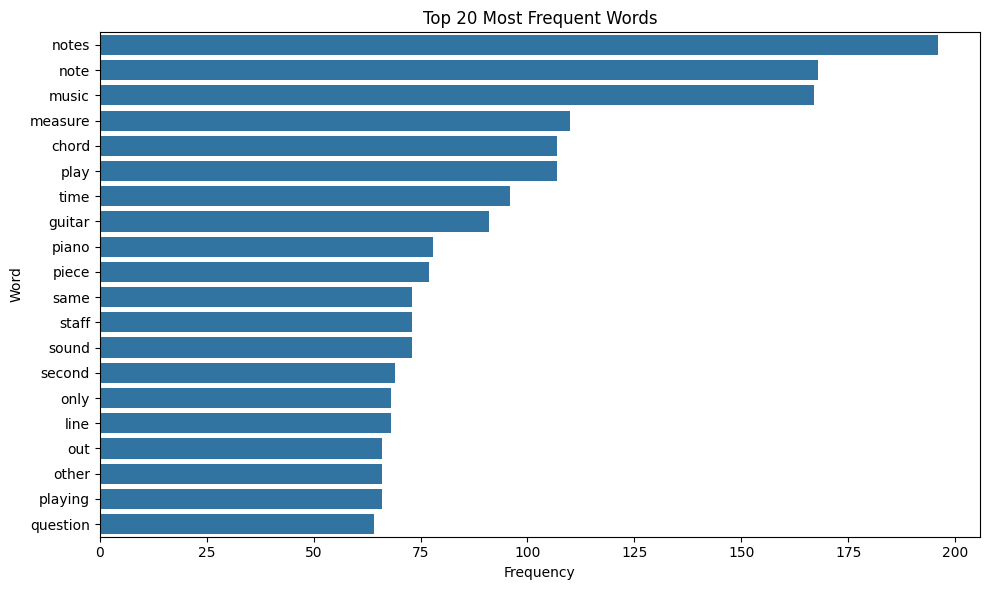

In [ ]:
# กราฟ
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_words,
    x="count",
    y="word"
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

**ผลการวิเคราะห์ Word Frequency:**  
คำที่พบมากส่วนใหญ่เกี่ยวข้องกับเนื้อหาด้านดนตรี เช่น `notes`, `music`, `measure`, `chord`, `guitar` และ `piano` แสดงให้เห็นว่าคำถามใน Dataset มีเนื้อหาเกี่ยวข้องกับโน้ต ทฤษฎีดนตรี คอร์ด และการเล่นเครื่องดนตรี

อย่างไรก็ตาม Word Frequency แสดงเพียงคำเดี่ยว จึงยังไม่สามารถอธิบายบริบทของคำได้ชัดเจน เช่นคำว่า `time` อาจหมายถึงหลายบริบท ดังนั้นจึงวิเคราะห์ N-gram ต่อเพื่อดูคำหรือวลีที่มักปรากฏร่วมกัน

### 3.3.3 N-gram Analysis

วิเคราะห์คำที่มักปรากฏร่วมกันใน `analysis_text` โดยใช้ **Bigram (2 คำติดกัน)** เพื่อช่วยให้เห็นบริบทของข้อความได้ชัดเจนกว่า Word Frequency ที่ดูเพียงคำเดี่ยว

In [ ]:
# ============================================================
# 3.3.3 N-gram Analysis
# ============================================================

from collections import Counter

# ใช้คำที่ผ่านการกรอง stopwords แล้วจากขั้นตอน Word Frequency
bigrams = list(zip(filtered_words, filtered_words[1:]))

# นับความถี่ของ bigram
bigram_counts = Counter(bigrams)

# สร้าง DataFrame
top_bigrams = pd.DataFrame(
    [
        (" ".join(pair), count)
        for pair, count in bigram_counts.most_common(20)
    ],
    columns=["bigram", "count"]
)

display(top_bigrams)



,bigram,count
0,time signature,18
1,new staff,18
2,sheet music,14
3,key signature,13
4,piano reduction,11
5,quarter note,11
6,electric guitar,10
7,second measure,10
8,blues scale,10
9,music theory,10


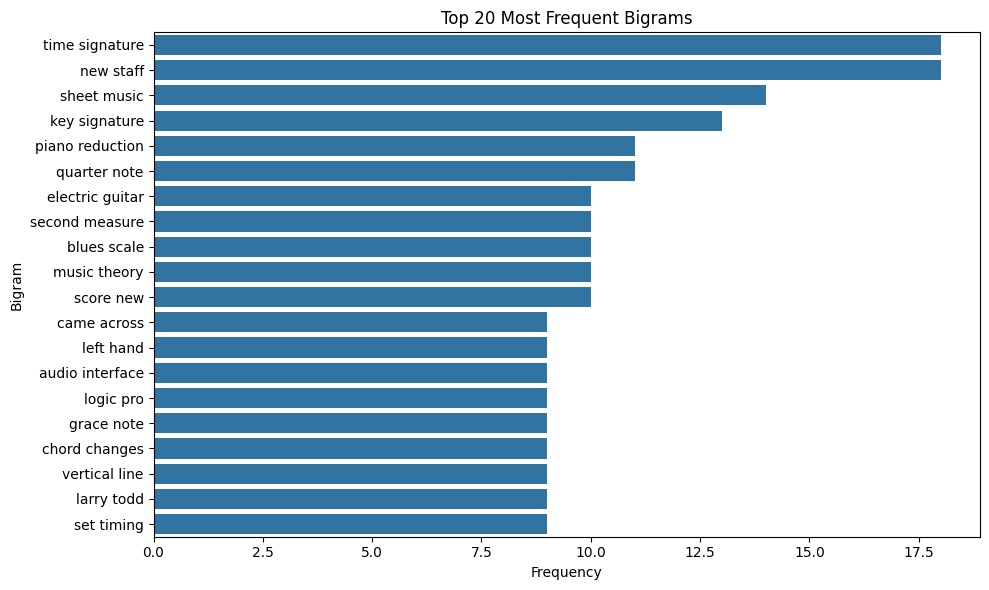

In [ ]:
# กราฟ
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_bigrams,
    x="count",
    y="bigram"
)

plt.title("Top 20 Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()

**ผลการวิเคราะห์ N-gram:**  
วลีที่พบค่อนข้างบ่อย เช่น `time signature`, `sheet music`, `key signature`, `quarter note`, `electric guitar` และ `music theory` แสดงให้เห็นว่าคำถามใน Dataset มีเนื้อหาเกี่ยวข้องกับทฤษฎีดนตรี การอ่านโน้ต เครื่องดนตรี และการเขียนโน้ตในหลายบริบท

N-gram ช่วยให้เห็นบริบทได้ชัดกว่า Word Frequency เพราะเป็นการพิจารณาคำที่มักปรากฏร่วมกัน แต่อย่างไรก็ตามผลส่วนนี้ใช้เพื่อสำรวจเนื้อหาเบื้องต้นเท่านั้น และยังไม่สามารถตอบคำถามด้าน Engagement หรือ Answered Rate ได้โดยตรง

### 3.3.4 Tag Analysis

วิเคราะห์ความถี่ของ `tags` ในแต่ละคำถาม เพื่อดูว่าหัวข้อด้านดนตรีใดถูกถามบ่อยใน Music Stack Exchange

เนื่องจาก 1 คำถามสามารถมีได้หลาย Tag จึงแยกแต่ละ Tag ออกมานับจำนวนครั้งที่ปรากฏใน Dataset

In [ ]:
# ============================================================
# 3.3.4 Tag Analysis
# ============================================================

from collections import Counter

# รวม tags จากทุกคำถาม
all_tags = [
    tag
    for tags in analysis_df["tags"]
    for tag in tags
]

# นับจำนวนครั้งที่แต่ละ tag ปรากฏ
tag_counts = Counter(all_tags)

# สร้าง DataFrame
top_tags = pd.DataFrame(
    tag_counts.most_common(20),
    columns=["tag", "question_count"]
)

display(top_tags)



,tag,question_count
0,notation,54
1,theory,35
2,lilypond,29
3,piano,29
4,technique,21
5,rhythm,17
6,engraving,16
7,guitar,15
8,time-signatures,13
9,harmony,12


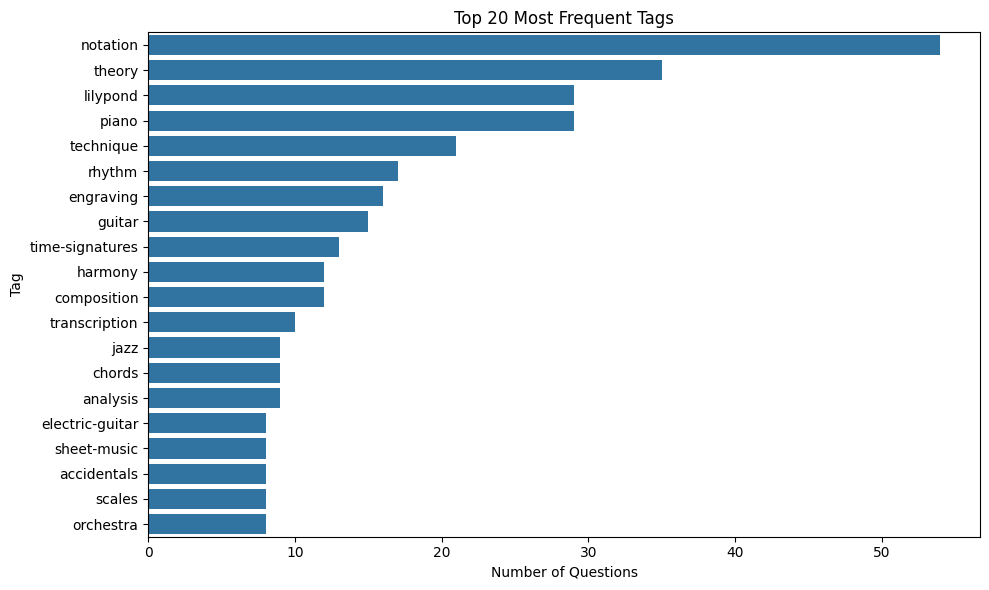

In [ ]:
# กราฟ
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_tags,
    x="question_count",
    y="tag"
)

plt.title("Top 20 Most Frequent Tags")
plt.xlabel("Number of Questions")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()

ตรงนี้ question_count หมายถึง จำนวนคำถามที่มี Tag นั้น
เช่น ถ้า notation = 54 แปลว่า
มีคำถาม 54 รายการที่ติด Tag notation

**ผลการวิเคราะห์ Tag Analysis:**  
Tag ที่พบมากที่สุดคือ `notation` จำนวน 54 คำถาม รองลงมาคือ `theory` 35 คำถาม และ `lilypond` กับ `piano` อย่างละ 29 คำถาม

ผลนี้แสดงให้เห็นว่าคำถามจำนวนมากใน Dataset เกี่ยวข้องกับการเขียนและอ่านโน้ต ทฤษฎีดนตรี และการเล่นเครื่องดนตรี

อย่างไรก็ตาม จำนวนคำถามเพียงอย่างเดียวยังไม่สามารถบอกได้ว่าหัวข้อใดได้รับความสนใจสูงหรือมีปัญหาเรื่องการได้รับคำตอบ จึงต้องวิเคราะห์ Engagement ต่อในขั้นตอนถัดไป

### 3.3.5 Engagement Analysis

วิเคราะห์ Engagement ของแต่ละ Tag โดยพิจารณาจาก

- `question_count` จำนวนคำถามในแต่ละ Tag
- `avg_views` จำนวนการเข้าชมเฉลี่ย
- `avg_score` คะแนนเฉลี่ย
- `avg_answers` จำนวนคำตอบเฉลี่ย
- `answered_rate_pct` สัดส่วนคำถามที่ได้รับคำตอบ

เพื่อดูว่าหัวข้อใดมีความสนใจสูง และหัวข้อใดมี Answered Rate ต่ำเมื่อเทียบกับหัวข้ออื่น

In [ ]:
# ============================================================
# 3.3.5 Engagement Analysis
# ============================================================

# แยก 1 row ต่อ 1 tag
tag_df = analysis_df.explode("tags").copy()

# สรุป Engagement ราย Tag
tag_engagement = (
    tag_df
    .groupby("tags")
    .agg(
        question_count=("question_id", "count"),
        avg_views=("view_count", "mean"),
        avg_score=("score", "mean"),
        avg_answers=("answer_count", "mean"),
        answered_rate=("is_answered", "mean")
    )
    .reset_index()
)

# แปลง answered rate เป็นเปอร์เซ็นต์
tag_engagement["answered_rate_pct"] = (
    tag_engagement["answered_rate"] * 100
)

# กรองเฉพาะ Tag ที่มีอย่างน้อย 8 คำถาม
min_questions = 8

engagement_filtered = tag_engagement[
    tag_engagement["question_count"] >= min_questions
].copy()

# เรียงตามจำนวนคำถาม
engagement_filtered = engagement_filtered.sort_values(
    "question_count",
    ascending=False
)

display(
    engagement_filtered[
        [
            "tags",
            "question_count",
            "avg_views",
            "avg_score",
            "avg_answers",
            "answered_rate_pct"
        ]
    ].round(2)
)

,tags,question_count,avg_views,avg_score,avg_answers,answered_rate_pct
135,notation,54,456.31,5.48,2.09,90.74
207,theory,35,451.51,3.94,2.26,94.29
111,lilypond,29,265.52,4.17,1.48,89.66
154,piano,29,532.31,4.17,2.21,93.10
202,technique,21,447.71,4.05,1.90,95.24
169,rhythm,17,604.47,4.76,2.41,94.12
66,engraving,16,473.56,5.38,2.06,87.50
84,guitar,15,422.13,3.07,1.73,66.67
209,time-signatures,13,423.46,4.46,2.00,84.62
87,harmony,12,211.08,3.42,1.42,91.67


ตรงนี้เราใช้ >= 8 คำถาม เพื่อไม่ให้ Tag ที่มีตัวอย่างน้อยมากมามีอิทธิพลกับผลมากเกินไป จากนั้นทำตารางหา หัวข้อที่มี Answered Rate ต่ำ

In [ ]:
low_answered = engagement_filtered.sort_values(
    ["answered_rate_pct", "avg_views"],
    ascending=[True, False]
)

display(
    low_answered[
        [
            "tags",
            "question_count",
            "avg_views",
            "avg_answers",
            "answered_rate_pct"
        ]
    ].head(10).round(2)
)

,tags,question_count,avg_views,avg_answers,answered_rate_pct
65,electric-guitar,8,288.38,1.75,62.50
57,dynamics,8,207.25,1.62,62.50
84,guitar,15,422.13,1.73,66.67
42,composition,12,372.33,1.50,75.00
2,accidentals,8,325.62,1.50,75.00
212,transcription,10,356.40,1.80,80.00
209,time-signatures,13,423.46,2.00,84.62
138,orchestra,8,575.38,2.00,87.50
66,engraving,16,473.56,2.06,87.50
9,analysis,9,278.11,1.11,88.89


**ผลการวิเคราะห์ Engagement:**  
เมื่อพิจารณาเฉพาะ Tag ที่มีอย่างน้อย 8 คำถาม พบว่าแต่ละหัวข้อมีระดับ Engagement และ Answered Rate แตกต่างกัน

- `sheet-music` มี Average Views สูงที่สุดประมาณ **733.62 views** และมี Answered Rate **100%** แสดงว่าหัวข้อนี้ได้รับความสนใจสูงและคำถามส่วนใหญ่ได้รับคำตอบ
- `guitar` มี **15 คำถาม**, Average Views ประมาณ **422.13 views** และมี Answered Rate เพียง **66.67%** ซึ่งค่อนข้างต่ำเมื่อเทียบกับหลายหัวข้อที่มีจำนวนคำถามใกล้เคียงกัน
- `composition` มี **12 คำถาม**, Average Views ประมาณ **372.33 views** และ Answered Rate **75.00%**
- `time-signatures` มี **13 คำถาม**, Average Views ประมาณ **423.46 views** และ Answered Rate **84.62%**
- `electric-guitar` และ `dynamics` มี Answered Rate ต่ำที่สุดที่ **62.50%** แต่มีเพียงหัวข้อละ 8 คำถาม จึงควรตีความอย่างระมัดระวังเนื่องจากขนาดตัวอย่างค่อนข้างน้อย

จากผลนี้ `guitar` เป็นหนึ่งในหัวข้อที่น่าสนใจสำหรับการตรวจสอบเพิ่มเติม เนื่องจากมีจำนวนคำถามมากกว่า Tag ที่มี Answered Rate ต่ำที่สุดบางหัวข้อ และยังมี Average Views ค่อนข้างสูง แต่มี Answered Rate เพียง 66.67%

อย่างไรก็ตาม ผลนี้ยังเป็นการวิเคราะห์เชิงพรรณนา จึงยังไม่สามารถสรุปได้ว่าทำไมบางหัวข้อจึงมี Answered Rate ต่ำ และจำเป็นต้องตรวจสอบความน่าเชื่อถือของ Finding ต่อในขั้นตอน Reality Check

### 3.3.6 Key Findings

- `notation` เป็น Tag ที่มีจำนวนคำถามมากที่สุด 54 คำถาม
- `sheet-music` มี Average Views สูงที่สุดประมาณ 733.62 views และมี Answered Rate 100%
- `electric-guitar` และ `dynamics` มี Answered Rate ต่ำสุดที่ 62.50% แต่มีเพียง 8 คำถาม
- `guitar` มี 15 คำถาม, Average Views 422.13 และ Answered Rate 66.67% จึงเป็นหัวข้อที่น่าสนใจสำหรับการตรวจสอบเพิ่มเติม
- `composition` และ `time-signatures` ก็มี Answered Rate ต่ำกว่าหลายหัวข้อ แต่ยังควรตีความอย่างระมัดระวัง

ดังนั้นจึงทำ Reality Check ต่อเพื่อประเมินความน่าเชื่อถือของ Finding ก่อนสรุปเป็น Business Insight

### 3.3.7 Reality Check

ตรวจสอบความน่าเชื่อถือของ Finding ก่อนสรุปเป็น Business Insight โดยพิจารณา 3 ประเด็น ได้แก่

1. เปลี่ยนเกณฑ์ขั้นต่ำของจำนวนคำถามต่อ Tag
2. ตรวจขนาดตัวอย่างและช่วงความไม่แน่นอนของ Answered Rate
3. ตรวจผลกระทบจากช่วงเวลาที่คำถามถูกสร้าง

####Reality Check 1

In [ ]:
# ============================================================
# Reality Check 1: Minimum Questions per Tag
# ============================================================

threshold_results = []

for threshold in [5, 8, 12]:
    temp = tag_engagement[
        tag_engagement["question_count"] >= threshold
    ].copy()

    focus = temp[
        temp["tags"].isin(
            ["guitar", "composition", "time-signatures"]
        )
    ][
        ["tags", "question_count",
         "avg_views", "answered_rate_pct"]
    ].copy()

    focus["min_questions"] = threshold
    threshold_results.append(focus)

threshold_check = pd.concat(
    threshold_results,
    ignore_index=True
)

display(
    threshold_check[
        ["min_questions", "tags",
         "question_count", "avg_views",
         "answered_rate_pct"]
    ].round(2)
)

,min_questions,tags,question_count,avg_views,answered_rate_pct
0,5,composition,12,372.33,75.00
1,5,guitar,15,422.13,66.67
2,5,time-signatures,13,423.46,84.62
3,8,composition,12,372.33,75.00
4,8,guitar,15,422.13,66.67
5,8,time-signatures,13,423.46,84.62
6,12,composition,12,372.33,75.00
7,12,guitar,15,422.13,66.67
8,12,time-signatures,13,423.46,84.62


**ผล Reality Check 1 — เปลี่ยนเกณฑ์ขั้นต่ำของจำนวนคำถามต่อ Tag:**  
เมื่อเปลี่ยนเกณฑ์ขั้นต่ำเป็น 5, 8 และ 12 คำถาม พบว่า `guitar`, `composition` และ `time-signatures` ยังคงผ่านเกณฑ์ทั้งหมด และค่าของ `question_count`, `avg_views` และ `answered_rate_pct` ไม่เปลี่ยนแปลง

ผลนี้แสดงว่า Finding เดิมไม่ได้เกิดจากการเลือก Minimum Questions = 8 เพียงค่าเดียว และยังคงปรากฏเมื่อเปลี่ยน Threshold

####Reality Check 2

ตรวจ Sample Size และช่วงความไม่แน่นอน

เนื่องจากแต่ละ Tag มีจำนวนคำถามไม่เท่ากัน จึงคำนวณ Wilson 95% Confidence Interval ของ Answered Rate เพื่อดูว่าค่าที่พบมีความไม่แน่นอนมากน้อยเพียงใด

In [ ]:
import math

def wilson_interval(successes, n, z=1.96):
    if n == 0:
        return (0, 0)

    p = successes / n

    denominator = 1 + (z**2 / n)

    center = (
        p + (z**2 / (2*n))
    ) / denominator

    margin = (
        z * math.sqrt(
            (p*(1-p)/n) +
            (z**2/(4*n**2))
        )
    ) / denominator

    return center - margin, center + margin


# Overall Answered Rate
overall_rate = analysis_df["is_answered"].mean()

print(
    "Overall Answered Rate:",
    round(overall_rate * 100, 2), "%"
)

focus_tags = [
    "guitar",
    "composition",
    "time-signatures"
]

ci_rows = []

for tag in focus_tags:

    row = tag_engagement[
        tag_engagement["tags"] == tag
    ].iloc[0]

    n = int(row["question_count"])

    tag_data = tag_df[
        tag_df["tags"] == tag
    ]

    successes = int(
        tag_data["is_answered"].sum()
    )

    lower, upper = wilson_interval(
        successes,
        n
    )

    ci_rows.append({
        "tag": tag,
        "n": n,
        "answered_rate_pct":
            row["answered_rate_pct"],
        "ci_lower_pct": lower * 100,
        "ci_upper_pct": upper * 100,
        "includes_overall":
            lower <= overall_rate <= upper
    })

ci_df = pd.DataFrame(ci_rows)

display(ci_df.round(2))

Overall Answered Rate: 87.0 %


,tag,n,answered_rate_pct,ci_lower_pct,ci_upper_pct,includes_overall
0,guitar,15,66.67,41.71,84.82,False
1,composition,12,75.00,46.77,91.11,True
2,time-signatures,13,84.62,57.76,95.67,True


**ผล Reality Check 2 — Sample Size และ Wilson 95% Confidence Interval:**  
Answered Rate รวมของ Dataset เท่ากับ **87.0%**

- `guitar` มี Answered Rate **66.67%** และ Wilson 95% CI อยู่ที่ **41.71%–84.82%** ซึ่งไม่ครอบคลุมค่า Overall Answered Rate ที่ 87.0%
- `composition` มี Answered Rate **75.00%** และช่วง CI **46.77%–91.11%** ซึ่งยังครอบคลุมค่า Overall
- `time-signatures` มี Answered Rate **84.62%** และช่วง CI **57.76%–95.67%** ซึ่งยังครอบคลุมค่า Overall

ดังนั้น `guitar` เป็นหัวข้อที่มีสัญญาณชัดที่สุดในสามหัวข้อว่า Answered Rate ต่ำกว่าภาพรวม ขณะที่ `composition` และ `time-signatures` ยังมีความไม่แน่นอนมากกว่า เนื่องจากช่วง Confidence Interval ยังครอบคลุมค่า Overall Answered Rate

####Reality Check 3

ตรวจผลกระทบจากช่วงเวลา

คำถามที่เพิ่งถูกสร้างอาจยังมีเวลารอคำตอบน้อยกว่าคำถามเก่า จึงแบ่งข้อมูลเป็นครึ่งเก่าและครึ่งใหม่ตาม `creation_datetime` แล้วเปรียบเทียบ Answered Rate

In [150]:
# ============================================================
# Reality Check 3: Older vs Newer Questions
# ============================================================

time_df = final_df.copy()

if "creation_datetime" not in time_df.columns:
    time_df["creation_datetime"] = pd.to_datetime(
        time_df["creation_date"],
        unit="s"
    )

median_date = time_df["creation_datetime"].median()

time_df["period"] = np.where(
    time_df["creation_datetime"] <= median_date,
    "Older",
    "Newer"
)

time_check = (
    time_df
    .groupby("period")
    .agg(
        question_count=("question_id", "count"),
        answered_rate=("is_answered", "mean")
    )
    .reset_index()
)

time_check["answered_rate_pct"] = (
    time_check["answered_rate"] * 100
)

display(
    time_check[
        ["period", "question_count", "answered_rate_pct"]
    ].round(2)
)

print("Median creation date:", median_date)

,period,question_count,answered_rate_pct
0,Newer,150,83.33
1,Older,150,90.67


Median creation date: 2026-05-31 18:03:32


**ผล Reality Check 3:**  
คำถามใหม่มี Answered Rate 83.33% ส่วนคำถามเก่ามี 90.67% แสดงว่าคำถามใหม่อาจยังมีเวลารอคำตอบน้อยกว่า จึงต้องระวังไม่สรุปว่า Answered Rate ต่ำเกิดจาก Content Gap เพียงอย่างเดียว

#### สรุป Reality Check

จากที่ลองเช็ก 3 แบบ ผลหลักยังไปในทางเดิมค่ะ

- พอเปลี่ยนเกณฑ์ขั้นต่ำเป็น 5, 8 และ 12 คำถาม ผลของ `guitar`, `composition` และ `time-signatures` ก็ยังเหมือนเดิม แปลว่าผลไม่ได้เกิดจากการตั้ง Threshold แค่ค่าเดียว
- `guitar` มี Answered Rate 66.67% ซึ่งต่ำกว่า Overall ที่ 87.0% ค่อนข้างชัด ส่วน `composition` กับ `time-signatures` ยังมีความไม่แน่นอนมากกว่า
- คำถามใหม่มี Answered Rate 83.33% ส่วนคำถามเก่ามี 90.67% แสดงว่าเวลาที่โพสต์คำถามก็อาจมีผล เพราะคำถามใหม่อาจยังมีเวลารอคำตอบน้อยกว่า

**สรุป:** `guitar` เป็นหัวข้อที่น่าสนใจที่สุดสำหรับเอาไปดูต่อ แต่ยังไม่ควรสรุปว่าเป็น Content Gap แน่นอน ควรตรวจข้อมูลเพิ่มก่อนนำไปทำ FAQ หรือ Knowledge Content

### 3.3.8 Main Visualizations

สร้างกราฟหลักเพื่อสรุปผลที่สำคัญจาก Tag Analysis และ Engagement Analysis ให้เห็นภาพได้ง่ายขึ้น

#### Main Visualization 1

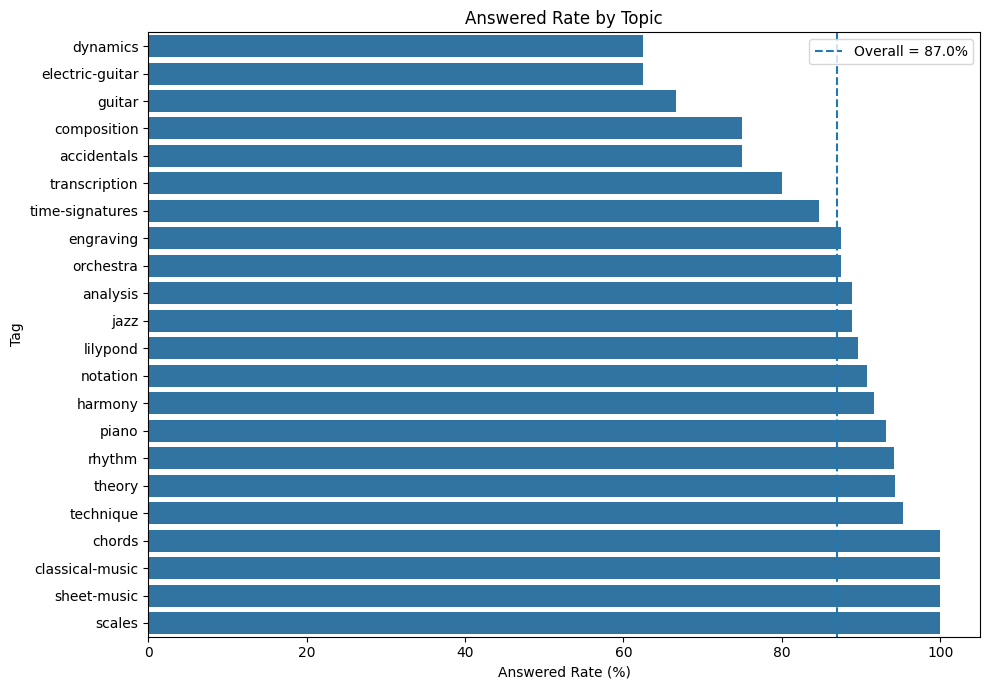

In [ ]:
focus_plot = engagement_filtered.sort_values(
    "answered_rate_pct",
    ascending=True
).copy()

plt.figure(figsize=(10, 7))

sns.barplot(
    data=focus_plot,
    x="answered_rate_pct",
    y="tags"
)

overall_rate_pct = analysis_df["is_answered"].mean() * 100

plt.axvline(
    overall_rate_pct,
    linestyle="--",
    label=f"Overall = {overall_rate_pct:.1f}%"
)

plt.title("Answered Rate by Topic")
plt.xlabel("Answered Rate (%)")
plt.ylabel("Tag")
plt.legend()
plt.tight_layout()
plt.show()

**สรุปกราฟ:**  
กราฟนี้เปรียบเทียบ Answered Rate ของแต่ละ Tag กับค่า Overall ของ Dataset ที่ 87.0%

จะเห็นว่า `guitar` มี Answered Rate ประมาณ 66.67% ซึ่งต่ำกว่าค่า Overall ค่อนข้างชัด ส่วน `composition` และ `time-signatures` ก็ต่ำกว่าค่า Overall เช่นกัน แต่ต่างกันไม่มากเท่า `guitar`

ดังนั้น `guitar` จึงเป็นหัวข้อที่น่าสนใจสำหรับนำไปตรวจสอบเพิ่มเติม

#### Main Visualization 2

Interest vs Answered Rate

กราฟนี้ใช้เปรียบเทียบความสนใจของแต่ละหัวข้อกับ Answered Rate โดยใช้

- แกน X = Answered Rate (%)
- แกน Y = Average Views
- ขนาดของจุด = จำนวนคำถามในแต่ละ Tag

เพื่อดูว่าหัวข้อใดมีคนสนใจค่อนข้างสูง แต่ยังมี Answered Rate ต่ำ

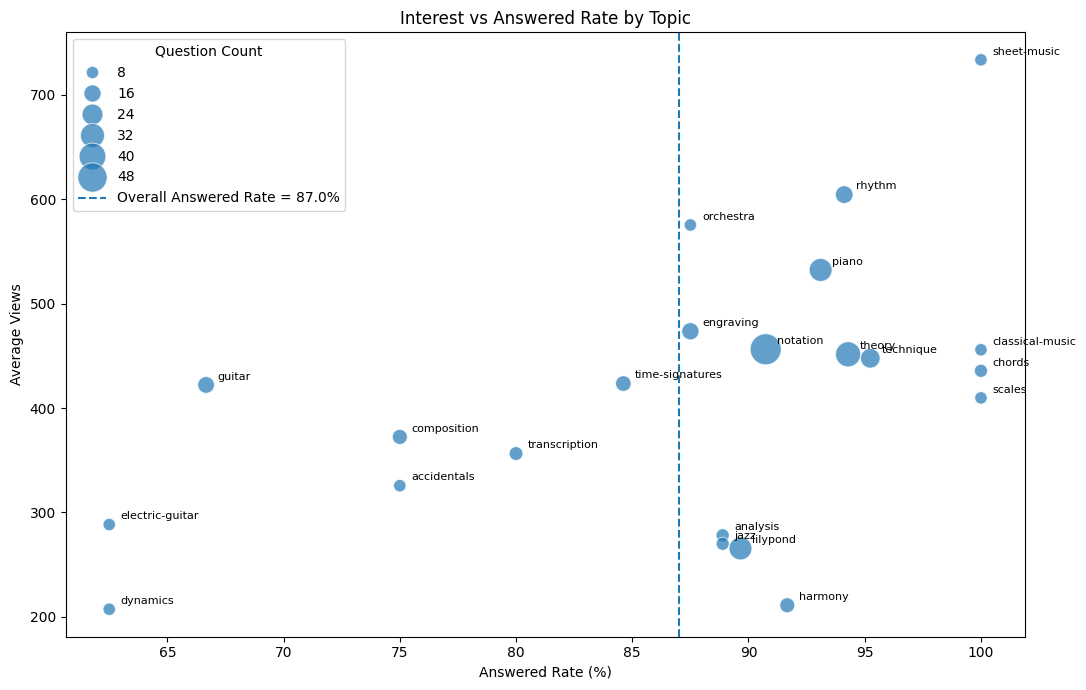

In [ ]:
# ============================================================
# Main Visualization 2: Interest vs Answered Rate
# ============================================================

plot_df = engagement_filtered.copy()

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=plot_df,
    x="answered_rate_pct",
    y="avg_views",
    size="question_count",
    sizes=(80, 500),
    alpha=0.7
)

# ใส่ชื่อ Tag ทุกจุด
for _, row in plot_df.iterrows():
    plt.text(
        row["answered_rate_pct"] + 0.5,
        row["avg_views"] + 5,
        row["tags"],
        fontsize=8
    )

# เส้น Overall Answered Rate
overall_rate_pct = analysis_df["is_answered"].mean() * 100

plt.axvline(
    overall_rate_pct,
    linestyle="--",
    label=f"Overall Answered Rate = {overall_rate_pct:.1f}%"
)

plt.title("Interest vs Answered Rate by Topic")
plt.xlabel("Answered Rate (%)")
plt.ylabel("Average Views")
plt.legend(title="Question Count")
plt.tight_layout()
plt.show()

กราฟนี้ช่วยยืนยันว่า “คนดูเยอะอย่างเดียวไม่พอ ต้องดูด้วยว่าได้คำตอบไหม” และ guitar เป็นตัวที่เด่นสุดฝั่ง views ค่อนข้างสูง + answered rate ต่ำ

**ผู้ใช้ผลวิเคราะห์ควรรู้อะไรหรือทำอะไรต่อ?**

Content / Knowledge Team ควรใช้ `guitar` เป็นหัวข้อแรกในการตรวจสอบเพิ่มเติม แล้วค่อยตัดสินใจว่าควรสร้าง FAQ หรือ Knowledge Content หรือไม่ โดยอ้างอิงจากคำถามจริงที่ยังไม่ได้รับคำตอบ

In [ ]:
# ============================================================
# Graph Verification
# ============================================================

focus_tags = ["guitar", "composition", "time-signatures"]

graph_check = tag_engagement[
    tag_engagement["tags"].isin(focus_tags)
][
    ["tags", "question_count", "avg_views", "answered_rate_pct"]
].copy()

display(graph_check.round(2))

overall_rate_pct = analysis_df["is_answered"].mean() * 100
print("Overall Answered Rate:", round(overall_rate_pct, 2), "%")

,tags,question_count,avg_views,answered_rate_pct
42,composition,12,372.33,75.00
84,guitar,15,422.13,66.67
209,time-signatures,13,423.46,84.62


Overall Answered Rate: 87.0 %


**ผลการตรวจสอบกราฟ:**  
ตรวจสอบค่าที่ใช้ในกราฟกับตาราง `tag_engagement` แล้ว พบว่าจำนวนคำถาม, Average Views และ Answered Rate ของหัวข้อหลักตรงกับข้อมูลที่ใช้วิเคราะห์ และค่า Overall Answered Rate เท่ากับ 87.0%

## 3.4 Insight Card

> **Insight:**  
> `guitar` เป็นหัวข้อที่น่าสนใจสำหรับการตรวจสอบเพิ่มเติม เพราะมี Answered Rate เพียง **66.67%** ซึ่งต่ำกว่าค่า Overall ของ Dataset ที่ **87.0%**

> **หลักฐาน:**  
> `guitar` มี 15 คำถาม, Average Views ประมาณ **422.13 views** และ Answered Rate **66.67%**  
> จาก Reality Check พบว่า Wilson 95% CI ของ `guitar` อยู่ที่ **41.71%–84.82%** ซึ่งไม่ครอบคลุมค่า Overall Answered Rate ที่ 87.0%  
> นอกจากนี้ เมื่อเปลี่ยนเกณฑ์ขั้นต่ำของจำนวนคำถามเป็น 5, 8 และ 12 ผลของ `guitar` ก็ยังคงเหมือนเดิม

> **So what:**  
> หัวข้อ `guitar` มีคนสนใจพอสมควร แต่ยังมีสัดส่วนคำถามที่ได้รับคำตอบต่ำกว่าภาพรวม จึงอาจมีคำถามบางกลุ่มที่ผู้ใช้ยังหาคำตอบได้ยาก

> **Action:**  
> Content / Knowledge Team ควรเข้าไปตรวจคำถามใน Tag `guitar` ที่ยังไม่ได้รับคำตอบ และดูว่ามีคำถามลักษณะคล้ายกันซ้ำหรือไม่  
> หากพบประเด็นซ้ำหลายครั้ง อาจนำไปทำ FAQ หรือ Knowledge Content เพื่อช่วยให้ผู้ใช้หาคำตอบได้ง่ายขึ้น

> **ความมั่นใจ:** ปานกลาง  
> เพราะผลของ `guitar` ยังชัดหลังทำ Reality Check แต่มีข้อมูลเพียง 15 คำถาม และพบว่าช่วงเวลาที่โพสต์คำถามอาจมีผลต่อ Answered Rate ด้วย

### ข้อจำกัดและข้อมูลที่ต้องมีเพิ่ม

ข้อมูลชุดนี้ยังตอบไม่ได้ว่า **ทำไมคำถามเกี่ยวกับ `guitar` ถึงได้รับคำตอบน้อยกว่า** และยังไม่สามารถบอกได้ว่าคำตอบที่ได้รับมีคุณภาพดีหรือไม่

ถ้าต้องการวิเคราะห์ต่อ ควรมีข้อมูลเพิ่ม เช่น
- เนื้อหาคำตอบ (Answers)
- Accepted Answer
- Answer Score
- Comments
- ข้อมูลในช่วงเวลาที่กว้างขึ้น

ดังนั้นผลนี้ควรใช้เป็นสัญญาณสำหรับตรวจสอบเพิ่มเติม ไม่ควรสรุปว่า `guitar` เป็น Content Gap แน่นอน

In [151]:
from IPython.display import display, HTML

insight_card = """
<div style="
    background: #FFF8FB;
    border: 2px solid #E8C7D8;
    border-radius: 18px;
    padding: 24px;
    margin: 16px 0;
    font-family: Arial, sans-serif;
    line-height: 1.6;
    box-shadow: 0 4px 12px rgba(0,0,0,0.08);
">

    <h2 style="color:#A45C7A; margin-top:0;">
        🌷 Insight Card
    </h2>

    <div style="
        background:#FCEAF2;
        padding:14px 16px;
        border-radius:12px;
        margin-bottom:12px;
    ">
        <b style="color:#8E4A69;">💡 Insight</b><br>
        <span>
        <b>guitar</b> เป็นหัวข้อที่น่าสนใจสำหรับการตรวจสอบเพิ่มเติม
        เพราะมี Answered Rate เพียง <b>66.67%</b>
        ซึ่งต่ำกว่าค่า Overall ของ Dataset ที่ <b>87.0%</b>
        </span>
    </div>

    <div style="
        background:#EEF5FF;
        padding:14px 16px;
        border-radius:12px;
        margin-bottom:12px;
    ">
        <b style="color:#5577A8;">📊 Evidence</b><br>
        <span>
        guitar มี <b>15 คำถาม</b>,
        Average Views ประมาณ <b>422.13 views</b>
        และ Answered Rate <b>66.67%</b><br>
        Wilson 95% CI = <b>41.71%–84.82%</b>
        ซึ่งไม่ครอบคลุม Overall Answered Rate ที่ 87.0%
        </span>
    </div>

    <div style="
        background:#FFF5E8;
        padding:14px 16px;
        border-radius:12px;
        margin-bottom:12px;
    ">
        <b style="color:#B27A3B;">🤔 So What</b><br>
        <span>
        หัวข้อ guitar มีคนสนใจพอสมควร
        แต่มีสัดส่วนคำถามที่ได้รับคำตอบต่ำกว่าภาพรวม
        จึงอาจมีบางประเด็นที่ผู้ใช้ยังหาคำตอบได้ยาก
        </span>
    </div>

    <div style="
        background:#EDF8F2;
        padding:14px 16px;
        border-radius:12px;
        margin-bottom:12px;
    ">
        <b style="color:#4F866A;">✅ Action</b><br>
        <span>
        Content / Knowledge Team ควรตรวจคำถามใน Tag <b>guitar</b>
        ที่ยังไม่ได้รับคำตอบ และดูว่ามีคำถามลักษณะคล้ายกันซ้ำหรือไม่
        ถ้าพบประเด็นซ้ำหลายครั้ง อาจนำไปทำ FAQ หรือ Knowledge Content
        </span>
    </div>

    <div style="
        background:#F4EEFF;
        padding:14px 16px;
        border-radius:12px;
        margin-bottom:12px;
    ">
        <b style="color:#7659A6;">🔎 Confidence</b><br>
        <span>
        <b>ปานกลาง</b> เพราะผลของ guitar ยังชัดหลังทำ Reality Check
        แต่มีข้อมูลเพียง 15 คำถาม และช่วงเวลาที่โพสต์อาจมีผลต่อ Answered Rate
        </span>
    </div>

    <div style="
        background:#FFF0F0;
        padding:14px 16px;
        border-radius:12px;
    ">
        <b style="color:#A95A5A;">⚠️ Limitation</b><br>
        <span>
        ข้อมูลนี้ยังบอกไม่ได้ว่า <b>ทำไม</b> guitar ถึงมี Answered Rate ต่ำ
        และยังไม่ได้วัดคุณภาพของคำตอบโดยตรง
        ถ้าจะวิเคราะห์ต่อ ควรมีข้อมูล Answers, Accepted Answer,
        Answer Score, Comments และข้อมูลในช่วงเวลาที่กว้างขึ้น
        </span>
    </div>

</div>
"""

display(HTML(insight_card))

## 19. Final Review

ตรวจสอบความครบถ้วนของ Data Collection, Data Quality, Analysis, Business Insight, Visualizations และ Insight Card ก่อนจัดทำรายงานและนำเสนอ

### 19.1 Data Collection

- [x] ใช้ Music Stack Exchange API เป็นแหล่งข้อมูล
- [x] เก็บข้อมูลด้วย API ตามวิธีที่กำหนด
- [x] เก็บข้อมูลทั้งหมด 300 raw records
- [x] Raw Dataset มี 17 columns
- [x] มีการกำหนด Decision Support Question
- [x] มีการกำหนด User และ Decision ที่ต้องการสนับสนุน
- [x] มีการกำหนดความหมายของ 1 record
- [x] มีการกำหนด Important Fields สำหรับการวิเคราะห์

### 19.2 Data Quality

- [x] ตรวจสอบจำนวน records และ columns
- [x] ตรวจสอบ Dataset Structure และ Data Types
- [x] ตรวจสอบ Missing Values
- [x] ตรวจสอบ Duplicate `question_id`
- [x] ตรวจสอบ Duplicate จาก `title` และ `body`
- [x] ทำความสะอาด HTML และข้อความใน `title` และ `body`
- [x] ตรวจสอบ Valid Analytical Records
- [x] ได้ Valid Analytical Records จำนวน 300 records
- [x] Final Dataset มี 300 records และ 12 columns

### 19.3 Text Analytics

- [x] วิเคราะห์ Word Frequency
- [x] วิเคราะห์ N-gram
- [x] วิเคราะห์ Tag Frequency
- [x] วิเคราะห์ Engagement by Topic
- [x] ใช้ `view_count` เป็นตัวชี้วัดระดับการเข้าชม
- [x] ใช้ `answered_rate` เป็นตัวชี้วัดสัดส่วนคำถามที่ได้รับคำตอบ
- [x] มีการเปรียบเทียบหัวข้อต่าง ๆ โดยใช้ Question Count, Average Views และ Answered Rate

### 19.4 Reality Check

- [x] ทดสอบ Minimum Questions per Tag ที่ 5, 8 และ 12
- [x] ตรวจสอบ Wilson 95% Confidence Interval
- [x] เปรียบเทียบ Older Half และ Newer Half
- [x] ระบุข้อจำกัดของ Reality Check
- [x] ไม่สรุปผลเชิงเหตุและผลจากข้อมูลเชิงพรรณนา

### 19.5 Business Insight

- [x] ระบุหัวข้อที่มี Question Volume สูง เช่น `notation`, `theory` และ `piano`
- [x] ตรวจสอบ Engagement ของแต่ละ Topic
- [x] พบว่า `guitar` มี Answered Rate 66.67%
- [x] พบว่า `composition` มี Answered Rate 75.00%
- [x] พบว่า `time-signatures` มี Answered Rate 84.62%
- [x] เปรียบเทียบกับ Overall Answered Rate ที่ 87.67%
- [x] ระบุว่า Focus Topics เป็นหัวข้อที่ควรตรวจสอบเพิ่มเติม
- [x] ไม่สรุปว่า Average Views เป็นหลักฐานโดยตรงของ Information Demand
- [x] ไม่สรุปว่า Answered Rate ต่ำหมายถึงคุณภาพคำตอบต่ำ

### 19.6 Visualizations

- [x] Main Graph 1: Answered Rate by Topic
- [x] Main Graph 2: Interest Proxy (Average Views) vs Answered Rate
- [x] ใช้ Overall Answered Rate = 87.67% เป็น Reference ใน Graph 1
- [x] ใช้ Median Answered Rate = 92.31% และ Median Average Views = 420.23 เป็น Reference ใน Graph 2
- [x] ตรวจสอบตัวเลขของ Focus Topics กับ `tag_engagement`
- [x] Question Count, Average Views และ Answered Rate ของ Focus Topics ตรงกับข้อมูลต้นทาง
- [x] Verification Result = PASS

### 19.7 Insight Card

- [x] มี Insight
- [x] มี Evidence
- [x] มี So What
- [x] มี Action
- [x] มี Confidence
- [x] มี Limitation
- [x] ระบุ Confidence ระดับ Moderate
- [x] ระบุข้อจำกัดเรื่องจำนวนข้อมูลและขอบเขตของ Dataset
- [x] ระบุว่า Answered Rate ไม่ได้วัดคุณภาพของคำตอบ
- [x] ระบุว่าเป็น Descriptive Analysis และไม่ใช่ Causal Conclusion

### 19.8 Final Conclusion

จากการตรวจสอบ Data Collection, Data Quality, Text Analytics, Reality Check, Business Insight, Visualizations และ Insight Card พบว่าองค์ประกอบหลักของ Part 3 มีความครบถ้วนและเชื่อมโยงกันตั้งแต่การเก็บข้อมูลจนถึงการสรุป Business Insight

ข้อมูลจำนวน 300 records ผ่านการตรวจสอบและทำความสะอาดแล้ว และมีการตรวจสอบความสอดคล้องของตัวเลขที่ใช้ใน Main Graphs โดยผลการตรวจสอบของ Focus Topics ได้ผลเป็น **PASS**

ผลการวิเคราะห์ชี้ให้เห็นว่า `guitar`, `composition` และ `time-signatures` มี Answered Rate ต่ำกว่า Overall Answered Rate ของ Dataset จึงควรนำไปตรวจสอบเพิ่มเติมในมุมมองของ Content หรือ Knowledge Management อย่างไรก็ตาม ผลลัพธ์เป็นการวิเคราะห์เชิงพรรณนาและมีข้อจำกัดด้านขนาดและขอบเขตของ Dataset จึงไม่ควรนำไปสรุปเป็นเหตุและผลหรือใช้แทนพฤติกรรมของผู้ใช้ Music Stack Exchange ทั้งหมด

### 19.9 Final Status

**Part 3 Final Review: READY FOR REPORT AND PRESENTATION**

# Presentation

## แผนแบ่งงานนำเสนอ Part 2 + Part 3
## สมาชิก 5 คน | Presentation ประมาณ 10 นาที

---

## 👤 1. แซนด์วิช — Introduction + Part 2: Business Question & Data

## หน้าที่หลัก
รับผิดชอบเปิดการนำเสนอ และอธิบายภาพรวมของ **Part 2**

### หัวข้อที่ต้องทำ
1. Introduction / Project Overview
2. Part 2 Business Question
3. Business User
4. Dataset และข้อมูลที่ใช้
5. Definition ของ Bad Review

### เนื้อหาที่ต้องพูด

**Project Overview**
- งานนี้ใช้ Data Analytics เพื่อค้นหา Business Insight
- แบ่งการวิเคราะห์เป็น Part 2 และ Part 3
- Part 2 เน้น Product Review / Product Feedback
- Part 3 เน้น Music Stack Exchange และ Knowledge/Content Insight

**Part 2 Business Question**
> What product characteristics and product-level patterns are associated with Bad Reviews, and which products should the Product Team investigate further?

**Business User**
- Product Team
- ใช้ผลวิเคราะห์เพื่อค้นหาสินค้าหรือ Product Pattern ที่ควรตรวจสอบเพิ่มเติม

**Bad Review Definition**
- Bad Review = Rating ≤ 2

### ต้องเตรียม Slide
**Slide 1 — Project Overview**
- Part 2: Product Review Analytics
- Part 3: Music Community / Knowledge Analytics
- Business Insight → Business Action

**Slide 2 — Part 2: Question & Data**
- Business Question
- Business User
- Dataset
- Bad Review = Rating ≤ 2

### เวลา
ประมาณ 1–1.5 นาที

---

## 👤 2. หลิน — Part 2: Insight 1 + Visualization

## หน้าที่หลัก
รับผิดชอบ Insight แรกของ Part 2

### หัวข้อที่ต้องทำ
1. Product Metadata Analysis
2. Long Title
3. Feature Bullets
4. Bad Review Rate
5. Visualization ของ Insight 1

### Insight หลัก

เปรียบเทียบกลุ่มสินค้าโดยใช้

> Very Long Title + Feature Bullets

ผลที่ได้:

- Very Long Title (24+ words) + 0 Feature Bullets
  - 671 review records
  - 503 products
  - Mean Rating = 3.991
  - Bad Review Rate = 20.9%

- Very Long Title (24+ words) + 4–5 Feature Bullets
  - Bad Review Rate = 14.3%
  - Mean Rating = 4.221

### สิ่งที่ต้องอธิบาย
- กลุ่มที่ไม่มี Feature Bullets มี Bad Review Rate สูงกว่า
- Mean Rating แตกต่างกันประมาณ 0.230 rating points
- Bad Review Rate แตกต่างกันประมาณ 6.587 percentage points
- ผลนี้เป็น **descriptive comparison**
- ยังไม่สามารถสรุปว่า Feature Bullets เป็นสาเหตุของ Rating ที่ดีขึ้น

### ต้องเตรียม Slide
**Slide 3 — Part 2: Product Metadata Signal**

ใส่:
- ตารางเปรียบเทียบ 2 กลุ่ม
- Graph เปรียบเทียบ Bad Review Rate หรือ Mean Rating
- Key Finding
- Limitation สั้น ๆ

### เวลา
ประมาณ 1 นาที

---

## 👤 3. เวฟ — Part 2: Insight 2 + Reality Check

## หน้าที่หลัก
รับผิดชอบ Product-level Analysis และตรวจสอบความเสถียรของ Insight

### หัวข้อที่ต้องทำ
1. Product-level Bad Review Analysis
2. Products with high Bad Review Rate
3. Threshold Analysis
4. Reality Check ของ Part 2

### Insight หลัก

พิจารณาเฉพาะ Product ที่มีอย่างน้อย 5 Reviews

ตัวอย่าง:

- B002UR3JVI
  - Bad Reviews = 4/5
  - Bad Review Rate = 80%
  - Mean Rating = 1.400

- B08BN8S4NM
  - Bad Reviews = 4/5
  - Bad Review Rate = 80%
  - Mean Rating = 1.800

มี Product จำนวนประมาณ 1,713 รายการที่มี Reviews ≥ 5

### จุดสำคัญที่ต้องพูด
80% ดูสูง แต่เกิดจากเพียง 4 Bad Reviews จาก 5 Reviews

ดังนั้นไม่ควรใช้เป็นหลักฐานว่า Product นั้นมีปัญหาแน่นอน

### Reality Check

เปลี่ยน Minimum Reviews จาก:

- ≥ 5 → Highest Bad Review Rate = 80%
- ≥ 10 → Highest Bad Review Rate = 57.1%

และ Product ที่มี Rate สูงสุดก็เปลี่ยน

### Conclusion
Insight นี้มีความไวต่อ Threshold และจำนวน Review

ดังนั้นควรใช้เป็น:

> Screening Signal

ไม่ใช่:

> Automatic Decision Rule

### ต้องเตรียม Slide
**Slide 4 — Part 2: Product-level Signal**

**Slide 5 — Part 2: Reality Check**

### เวลา
ประมาณ 1.5–2 นาที

---

## 👤 4. เอมี่ — Part 3: Data Collection + Data Quality + Text Analytics

## หน้าที่หลัก
รับผิดชอบส่วน Data Collection และ Analysis ของ Part 3

### หัวข้อที่ต้องทำ
1. Part 3 Business Question
2. Data Source
3. API Collection
4. Data Quality
5. Text Analytics
6. Word Frequency
7. N-gram
8. Tag Analysis

### Part 3 Business Question

> หัวข้อด้านดนตรีประเภทใดถูกถามบ่อยและได้รับความสนใจสูงใน Music Stack Exchange และหัวข้อใดมีคำถามจำนวนมากหรือมี Engagement สูง แต่มี Answered Rate ต่ำ?

### Business User
- Content Team
- Knowledge Team

### Decision
ใช้ข้อมูลเพื่อช่วยวางแผน:
- FAQ
- Knowledge Content
- Help Content
- Topic ที่ควรตรวจสอบเพิ่มเติม

### Data Source
**Music Stack Exchange API**

Collection Method:

> API

เก็บข้อมูล:

- 300 Raw Records
- 17 Columns

หลัง Cleaning:

- 300 Valid Analytical Records
- 12 Analytical Columns

### Data Quality
ต้องพูดถึง:

- Missing Values
- Duplicate Check
- Text Cleaning
- Valid Records

ผลสำคัญ:

- Duplicate question_id = 0
- Duplicate title + body = 0
- Valid Analytical Records = 300

### Text Analytics

**Word Frequency**
คำที่พบมาก เช่น:
- notes
- music
- measure
- play
- chord
- guitar
- piano
- sound

**N-gram**

ตัวอย่างคำที่พบซ้ำ:

- time signature = 18
- sheet music = 14
- quarter note = 14
- key signature = 13

**Tag Analysis**

ตัวอย่าง Tag ที่มีจำนวนคำถามสูง:

- notation = 53
- theory = 35
- piano = 29
- lilypond = 28

### ต้องเตรียม Slide
**Slide 6 — Part 3: Data Collection & Data Quality**

**Slide 7 — Part 3: Text & Tag Analysis**

### เวลา
ประมาณ 2 นาที

---

## 👤 5. ปิ๊ก — Part 3: Engagement Analysis + Business Insight + Insight Card

## หน้าที่หลัก
รับผิดชอบส่วนสำคัญที่สุดของ Part 3 คือการเปลี่ยนผล Analysis → Business Insight

### หัวข้อที่ต้องทำ
1. Engagement Analysis
2. Answered Rate
3. Interest vs Answered Rate
4. Reality Check
5. Business Implication
6. Insight Card
7. Final Conclusion

### Metrics ที่ใช้

- Question Count
- Average Views
- Average Answers
- Answered Rate

Overall Answered Rate:

> 87.67%

### Topic-level Results

**Guitar**
- Questions = 15
- Average Views = 398.87
- Answered Rate = 66.67%

**Composition**
- Questions = 12
- Average Views = 368.50
- Answered Rate = 75.00%

**Time-signatures**
- Questions = 13
- Average Views = 420.23
- Answered Rate = 84.62%

### ประเด็นที่ต้องระวัง

ไม่ควรพูดว่า:

> "ทั้ง 3 หัวข้อมีความสนใจสูงแน่นอน"

เพราะ Average Views ของ Guitar และ Composition ต่ำกว่า Median Average Views ของกลุ่มที่วิเคราะห์

ควรพูดว่า:

> "These topics show lower Answered Rates and should be investigated further."

หรือภาษาไทย:

> "หัวข้อเหล่านี้มีสัญญาณของ Answered Rate ที่ต่ำกว่า Overall และควรนำไปตรวจสอบเชิงเนื้อหาเพิ่มเติม"

### Reality Check

Guitar:
- n = 15
- Answered Rate = 66.7%
- 95% CI = 41.7–84.8%
- ไม่ overlap กับ Overall Answered Rate 87.67%

Composition:
- n = 12
- Answered Rate = 75.0%
- CI = 46.8–91.1%
- มีช่วงที่ overlap กับ Overall

Time-signatures:
- n = 13
- Answered Rate = 84.6%
- CI = 57.8–95.7%
- มีช่วงที่ overlap กับ Overall

ดังนั้น Guitar มีสัญญาณที่ชัดกว่า แต่ทั้งหมดควรตีความอย่างระมัดระวังเพราะจำนวนข้อมูลต่อ Topic ยังไม่มาก

### Business Insight

Content / Knowledge Team สามารถใช้ข้อมูลนี้เพื่อ:

1. ตรวจสอบคำถามใน Topic ที่มี Answered Rate ต่ำ
2. หาว่าผู้ใช้ถามเรื่องอะไรซ้ำ ๆ
3. ตรวจสอบว่า FAQ หรือ Knowledge Content ที่มีอยู่ตอบโจทย์หรือไม่
4. พิจารณาจัดทำ Content เพิ่มเติม
5. ใช้ผลเป็น Screening Signal ไม่ใช่กฎตัดสินใจอัตโนมัติ

### Insight Card

**Insight**

> Topic-level Answered Rate shows potential areas for further Content / Knowledge investigation.

**Evidence**

- Guitar: 15 questions, 66.7% Answered Rate
- Composition: 12 questions, 75.0%
- Time-signatures: 13 questions, 84.6%
- Overall: 87.67%

**So What**

หัวข้อเหล่านี้มี Answered Rate ต่ำกว่า Overall และอาจมีประเด็นที่ควรตรวจสอบเพิ่มเติม

**Action**

- Review actual questions
- Identify recurring information needs
- Check existing FAQ / Knowledge Content
- Consider creating or improving content

**Confidence**

> Moderate

เพราะจำนวนคำถามของแต่ละ Topic ยังอยู่ประมาณ 12–15 questions

**Limitation**

- ใช้ข้อมูล 300 questions
- ไม่ใช่ตัวแทนของผู้ใช้ Music Stack Exchange ทั้งหมด
- Answered Rate ไม่ได้วัดคุณภาพของคำตอบ
- Average Views ไม่ใช่หลักฐานโดยตรงของ Information Demand
- การวิเคราะห์เป็นเชิงพรรณนา ไม่สามารถสรุปเหตุและผล

### ต้องเตรียม Slide
**Slide 8 — Part 3: Engagement Analysis**

**Slide 9 — Part 3: Business Insight & Reality Check**

**Slide 10 — Insight Card + Final Takeaway**

### เวลา
ประมาณ 2 นาที

---

# 📊 สรุปการแบ่งงาน 5 คน

| คน | Part | หัวข้อหลัก | Slides |
|---|---|---|---|
| คนที่ 1 | Part 2 | Introduction + Business Question + Data | 1–2 |
| คนที่ 2 | Part 2 | Insight 1: Product Metadata | 3 |
| คนที่ 3 | Part 2 | Insight 2: Product-level + Reality Check | 4–5 |
| คนที่ 4 | Part 3 | Data Collection + Data Quality + Text Analytics | 6–7 |
| คนที่ 5 | Part 3 | Engagement + Business Insight + Insight Card | 8–10 |

---

# 🎤 ลำดับการพูดจริง

**คนที่ 1**
→ เปิดงาน → อธิบาย Part 2 Question/Data

↓

**คนที่ 2**
→ วิเคราะห์ Product Metadata → Insight 1

↓

**คนที่ 3**
→ วิเคราะห์ Product-level → Reality Check → ปิด Part 2

↓

**คนที่ 4**
→ เปิด Part 3 → อธิบาย API/Data Quality → Text Analytics

↓

**คนที่ 5**
→ Engagement → Business Insight → Insight Card → สรุปงาน

---

# ⏱️ เวลารวมประมาณ 10 นาที

- คนที่ 1: 1–1.5 นาที
- คนที่ 2: 1 นาที
- คนที่ 3: 1.5–2 นาที
- คนที่ 4: 2 นาที
- คนที่ 5: 2–2.5 นาที

รวมประมาณ 8–9.5 นาที

เหลือประมาณ 0.5–2 นาทีสำหรับ transition และเผื่อเวลาพูดจริง

---

# ⭐ สิ่งที่แต่ละคนต้องส่งให้คนทำสไลด์

**คนที่ 1**
- Slide 1
- Slide 2
- Business Question
- Dataset / Definition

**คนที่ 2**
- Slide 3
- ตาราง Insight 1
- Graph Insight 1
- Key Finding

**คนที่ 3**
- Slide 4
- Slide 5
- Product-level results
- Reality Check

**คนที่ 4**
- Slide 6
- Slide 7
- Data Collection
- Data Quality
- Word Frequency
- N-gram
- Tag Analysis

**คนที่ 5**
- Slide 8
- Slide 9
- Slide 10
- Engagement Graph
- Reality Check
- Insight Card
- Final Takeaway

---

# 🔑 ภาพรวมของงาน

Part 2
→ Product Review
→ Product Team
→ Bad Review
→ Product Metadata / Product-level Analysis
→ Product Investigation

Part 3
→ Music Stack Exchange
→ Content / Knowledge Team
→ Questions / Topics
→ Text + Tag + Engagement Analysis
→ FAQ / Knowledge Content Investigation

ดังนั้นทั้งสอง Part ใช้แนวคิดเดียวกันคือ

**Data → Analysis → Insight → Business Action**

แต่ Business Context และ Decision User แตกต่างกัน